# 🎬 Movie Recommendation System

## Project Overview

This project aims to build an end-to-end movie recommendation system using real-world user interactions and movie metadata.

The objective is to explore multiple recommendation techniques, compare their performance, and develop a modular recommendation pipeline that can later be exposed through an API and an interactive dashboard.

Throughout this project, several recommendation strategies will be implemented, evaluated, and analyzed to understand their strengths, limitations, and practical applications.

## Workflow

The project will be developed through the following stages:

1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Recommendation Models
7. Model Evaluation
8. Recommendation Pipeline
9. API Development

In [ ]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import implicit
import json

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix, save_npz

warnings.filterwarnings("ignore")

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Polars Display Settings
pl.Config.set_tbl_rows(30)
pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_width_chars(200)

# Reproducibility
RANDOM_STATE = 42

In [2]:
# ==========================================
# Define Project Paths
# ==========================================

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

MOVIELENS_DIR = RAW_DATA_DIR / "movielens"
TMDB_DIR = RAW_DATA_DIR / "tmdb"

---

# Load Datasets

The MovieLens dataset consists of multiple files, each describing a different aspect of the recommendation problem.

At this stage, the datasets are simply loaded into memory without any preprocessing or merging.

In [3]:
# ==========================================
# Load MovieLens Dataset
# ==========================================

ratings = pl.read_csv("ratings.csv")
movies = pl.read_csv("movies.csv")
tags = pl.read_csv("tags.csv")
links = pl.read_csv("links.csv")

In [4]:
# ==========================================
# Load TMDB Datasets
# ==========================================


tmdb_credits = pl.read_csv("tmdb_5000_credits.csv")


tmdb_movies = pl.read_csv(
    "tmdb_5000_movies.csv",
    dtypes={
        "runtime": pl.Float64
    }
)

### Dataset Description

| Dataset | Description |
|----------|-------------|
| ratings | User ratings assigned to movies |
| movies | Movie titles and genres |
| tags | User-generated descriptive tags |
| links | Mapping between MovieLens, IMDb, and TMDB identifiers |

In [5]:
# ==========================================
# Initial Dataset Inspection
# ==========================================

datasets = {
    "ratings": ratings,
    "movies": movies,
    "tags": tags,
    "links": links
}

for name , df in datasets.items():

    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    print(f"Shspe : ({df.height:,} , {df.width:})")
    print(f"Columns : {df.columns}")

    print("\nSchema")
    print(df.schema)

    print("\nPreview")
    print(df.head())

RATINGS
Shspe : (25,000,095 , 4)
Columns : ['userId', 'movieId', 'rating', 'timestamp']

Schema
OrderedDict({'userId': Int64, 'movieId': Int64, 'rating': Float64, 'timestamp': Int64})

Preview
shape: (5, 4)
┌────────┬─────────┬────────┬────────────┐
│ userId ┆ movieId ┆ rating ┆ timestamp  │
│ ---    ┆ ---     ┆ ---    ┆ ---        │
│ i64    ┆ i64     ┆ f64    ┆ i64        │
╞════════╪═════════╪════════╪════════════╡
│ 1      ┆ 296     ┆ 5.0    ┆ 1147880044 │
│ 1      ┆ 306     ┆ 3.5    ┆ 1147868817 │
│ 1      ┆ 307     ┆ 5.0    ┆ 1147868828 │
│ 1      ┆ 665     ┆ 5.0    ┆ 1147878820 │
│ 1      ┆ 899     ┆ 3.5    ┆ 1147868510 │
└────────┴─────────┴────────┴────────────┘
MOVIES
Shspe : (62,423 , 3)
Columns : ['movieId', 'title', 'genres']

Schema
OrderedDict({'movieId': Int64, 'title': String, 'genres': String})

Preview
shape: (5, 3)
┌─────────┬───────────────────────────────────┬───────────────────────────────────┐
│ movieId ┆ title                             ┆ genres               

---

# Explore Dataset Structure

Before cleaning or transforming the data, it's helpful to get a high-level understanding of each dataset.

In this section, we'll examine the size of each dataset, inspect the available columns, and preview a few records. This gives us a clearer picture of the data we'll be working with in the next steps.

In [6]:
# ==========================================
# Dataset Summary
# ==========================================

summary = []

for name , df in datasets.items():
    summary.append({
        "Dataset" : name,
        "Rows" : df.height,
        "Columns" : df.width
    })

summary = (
    pl.DataFrame(summary)
    .sort("Rows" , descending = True)
)

print(summary)

shape: (4, 3)
┌─────────┬──────────┬─────────┐
│ Dataset ┆ Rows     ┆ Columns │
│ ---     ┆ ---      ┆ ---     │
│ str     ┆ i64      ┆ i64     │
╞═════════╪══════════╪═════════╡
│ ratings ┆ 25000095 ┆ 4       │
│ tags    ┆ 1093360  ┆ 4       │
│ movies  ┆ 62423    ┆ 3       │
│ links   ┆ 62423    ┆ 3       │
└─────────┴──────────┴─────────┘


### Observation

The summary above provides a quick overview of the available datasets.

Notice that the datasets vary significantly in size. This is expected, as user interactions are naturally much more frequent than movie metadata.

The next step is to inspect the schema and sample records of each dataset in more detail.

---

# 6. Inspect Dataset Schema

Understanding the structure of each dataset is an essential first step before cleaning or merging the data.

Here, we'll review the column names, data types, and a small sample of each dataset.

In [7]:
# ==========================================
# Schema and Sample Records
# ==========================================

for name , df in datasets.items():

    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    print("\nColumns")
    print(df.columns)

    print("\nSchema")
    print(df.schema)

    print("\nFirst 5 rows")
    print(df.head())

    print("\n")

RATINGS

Columns
['userId', 'movieId', 'rating', 'timestamp']

Schema
OrderedDict({'userId': Int64, 'movieId': Int64, 'rating': Float64, 'timestamp': Int64})

First 5 rows
shape: (5, 4)
┌────────┬─────────┬────────┬────────────┐
│ userId ┆ movieId ┆ rating ┆ timestamp  │
│ ---    ┆ ---     ┆ ---    ┆ ---        │
│ i64    ┆ i64     ┆ f64    ┆ i64        │
╞════════╪═════════╪════════╪════════════╡
│ 1      ┆ 296     ┆ 5.0    ┆ 1147880044 │
│ 1      ┆ 306     ┆ 3.5    ┆ 1147868817 │
│ 1      ┆ 307     ┆ 5.0    ┆ 1147868828 │
│ 1      ┆ 665     ┆ 5.0    ┆ 1147878820 │
│ 1      ┆ 899     ┆ 3.5    ┆ 1147868510 │
└────────┴─────────┴────────┴────────────┘


MOVIES

Columns
['movieId', 'title', 'genres']

Schema
OrderedDict({'movieId': Int64, 'title': String, 'genres': String})

First 5 rows
shape: (5, 3)
┌─────────┬───────────────────────────────────┬───────────────────────────────────┐
│ movieId ┆ title                             ┆ genres                            │
│ ---     ┆ ---      

---

# Check Data Quality

Before making any changes to the data, let's take a quick look at its quality.

We'll check for missing values and duplicate records to see if any preprocessing is needed before moving forward.

In [8]:
# ==========================================
# Missing Values
# ==========================================

missing_summary = []

for name , df in datasets.items():

    missing_counts = df.null_count()

    for column in df.columns:

        missing_summary.append({
            "Dataset" : name,
            "Column" : column,
            "Missing Values" : missing_counts[column][0]
        })

missing_summary = (
    pl.DataFrame(missing_summary)
    .sort(["Dataset" , "Missing Values"], descending = [False , True])
)

print(missing_summary)

shape: (14, 3)
┌─────────┬───────────┬────────────────┐
│ Dataset ┆ Column    ┆ Missing Values │
│ ---     ┆ ---       ┆ ---            │
│ str     ┆ str       ┆ i64            │
╞═════════╪═══════════╪════════════════╡
│ links   ┆ tmdbId    ┆ 107            │
│ links   ┆ movieId   ┆ 0              │
│ links   ┆ imdbId    ┆ 0              │
│ movies  ┆ movieId   ┆ 0              │
│ movies  ┆ title     ┆ 0              │
│ movies  ┆ genres    ┆ 0              │
│ ratings ┆ userId    ┆ 0              │
│ ratings ┆ movieId   ┆ 0              │
│ ratings ┆ rating    ┆ 0              │
│ ratings ┆ timestamp ┆ 0              │
│ tags    ┆ userId    ┆ 0              │
│ tags    ┆ movieId   ┆ 0              │
│ tags    ┆ tag       ┆ 0              │
│ tags    ┆ timestamp ┆ 0              │
└─────────┴───────────┴────────────────┘


---

# Inspect Each Dataset

Before cleaning or merging the datasets, it's useful to understand what each column represents.

We'll review the structure of every dataset one by one and identify the information each file contains.

In [9]:
# ==========================================
# Dataset Information
# ==========================================

for name , df in datasets.items():

    print("=" * 80)
    print(f"{name.upper()} DATASET")
    print("=" * 80)

    print(f"Rows : {df.height:,}")
    print(f"Columns : {df.width:}")

    print(
        pl.DataFrame({
            "Column" : df.columns,
            "Data Type" : [str(dtype) for dtype in df.dtypes]
        })
    )

    print("\n")

RATINGS DATASET
Rows : 25,000,095
Columns : 4
shape: (4, 2)
┌───────────┬───────────┐
│ Column    ┆ Data Type │
│ ---       ┆ ---       │
│ str       ┆ str       │
╞═══════════╪═══════════╡
│ userId    ┆ Int64     │
│ movieId   ┆ Int64     │
│ rating    ┆ Float64   │
│ timestamp ┆ Int64     │
└───────────┴───────────┘


MOVIES DATASET
Rows : 62,423
Columns : 3
shape: (3, 2)
┌─────────┬───────────┐
│ Column  ┆ Data Type │
│ ---     ┆ ---       │
│ str     ┆ str       │
╞═════════╪═══════════╡
│ movieId ┆ Int64     │
│ title   ┆ String    │
│ genres  ┆ String    │
└─────────┴───────────┘


TAGS DATASET
Rows : 1,093,360
Columns : 4
shape: (4, 2)
┌───────────┬───────────┐
│ Column    ┆ Data Type │
│ ---       ┆ ---       │
│ str       ┆ str       │
╞═══════════╪═══════════╡
│ userId    ┆ Int64     │
│ movieId   ┆ Int64     │
│ tag       ┆ String    │
│ timestamp ┆ Int64     │
└───────────┴───────────┘


LINKS DATASET
Rows : 62,423
Columns : 3
shape: (3, 2)
┌─────────┬───────────┐
│ Column 

---

# Check Unique Values

Counting unique values gives us a better understanding of the datasets.

For example, it tells us how many users, movies, or tags are available and helps identify columns that may require special attention later.

In [10]:
# ==========================================
# Unique Values
# ==========================================

for name , df in datasets.items():

    print("=" * 80)
    print(print(f"{name.upper()}"))
    print("=" * 80)

    unique_summary = []

    for column in df.columns:

        unique_summary.append({
            "Column" : column,
            "Unique Values" : df[column].n_unique()
        })

    print(pl.DataFrame(unique_summary))

    print("\n")

RATINGS
None
shape: (4, 2)
┌───────────┬───────────────┐
│ Column    ┆ Unique Values │
│ ---       ┆ ---           │
│ str       ┆ i64           │
╞═══════════╪═══════════════╡
│ userId    ┆ 162541        │
│ movieId   ┆ 59047         │
│ rating    ┆ 10            │
│ timestamp ┆ 20115267      │
└───────────┴───────────────┘


MOVIES
None
shape: (3, 2)
┌─────────┬───────────────┐
│ Column  ┆ Unique Values │
│ ---     ┆ ---           │
│ str     ┆ i64           │
╞═════════╪═══════════════╡
│ movieId ┆ 62423         │
│ title   ┆ 62325         │
│ genres  ┆ 1639          │
└─────────┴───────────────┘


TAGS
None
shape: (4, 2)
┌───────────┬───────────────┐
│ Column    ┆ Unique Values │
│ ---       ┆ ---           │
│ str       ┆ i64           │
╞═══════════╪═══════════════╡
│ userId    ┆ 14592         │
│ movieId   ┆ 45251         │
│ tag       ┆ 73051         │
│ timestamp ┆ 907730        │
└───────────┴───────────────┘


LINKS
None
shape: (3, 2)
┌─────────┬───────────────┐
│ Column  ┆ 

---

# Validate Relationships Between Datasets

The datasets are connected through shared identifiers.

Before merging them, it's important to verify that these relationships are consistent and that no unexpected IDs exist across the files.

In [11]:
# ==========================================
# Validate Movie IDs
# ==========================================

missing_movie_ids = (
    ratings
    .select("movieId")
    .unique()
    .join(
        movies.select("movieId"),
        on = "movieId",
        how = "anti"
    )
)

print(f"Missing Movie IDs: {missing_movie_ids.height:,}")

print(missing_movie_ids.head())

Missing Movie IDs: 0
shape: (0, 1)
┌─────────┐
│ movieId │
│ ---     │
│ i64     │
╞═════════╡
└─────────┘


In [12]:
# ==========================================
# Validate Link Mapping
# ==========================================

missing_links = (
    links
    .join(
        movies.select("movieId"),
        on = "movieId",
        how = "anti"
    )
)

print(f"Missing Movie IDs in Links: {missing_links.height:,}")
print()
print(missing_links.head())

Missing Movie IDs in Links: 0

shape: (0, 3)
┌─────────┬────────┬────────┐
│ movieId ┆ imdbId ┆ tmdbId │
│ ---     ┆ ---    ┆ ---    │
│ i64     ┆ i64    ┆ i64    │
╞═════════╪════════╪════════╡
└─────────┴────────┴────────┘


In [13]:
# ==========================================
# Validate Tagged Movies
# ==========================================

missing_tagged_movies = (
    tags
    .select("movieId")
    .unique()
    .join(
        movies.select("movieId"),
        on = "movieId",
        how = "anti"
    )
)

print(f"Missing tagged movies: {missing_tagged_movies.height:,}")
print()
print(missing_tagged_movies.head())

Missing tagged movies: 0

shape: (0, 1)
┌─────────┐
│ movieId │
│ ---     │
│ i64     │
╞═════════╡
└─────────┘


---

# Inspect the Ratings Dataset

The ratings dataset is the core of this project.

Before building any recommendation models, let's make sure the rating values look reasonable and understand how users interact with movies.

In [14]:
# ==========================================
# Rating Distribution
# ==========================================

rating_distribution = (
    ratings
    .select(
        pl.col("rating").value_counts(sort=False)
    )
    .unnest("rating")
    .sort("rating")
)

print(rating_distribution)

shape: (10, 2)
┌────────┬─────────┐
│ rating ┆ count   │
│ ---    ┆ ---     │
│ f64    ┆ u32     │
╞════════╪═════════╡
│ 0.5    ┆ 393068  │
│ 1.0    ┆ 776815  │
│ 1.5    ┆ 399490  │
│ 2.0    ┆ 1640868 │
│ 2.5    ┆ 1262797 │
│ 3.0    ┆ 4896928 │
│ 3.5    ┆ 3177318 │
│ 4.0    ┆ 6639798 │
│ 4.5    ┆ 2200539 │
│ 5.0    ┆ 3612474 │
└────────┴─────────┘


### Quick Note

MovieLens uses predefined rating values, so this check helps confirm that the dataset matches the expected rating scale.

---

# Check Rating Range

Let's verify the minimum and maximum rating values before moving forward.

In [15]:
# ==========================================
# Rating Range
# ==========================================

print(
    ratings.select(
    [
        pl.col("rating").min().alias("Minimum Rating"),
        pl.col("rating").max().alias("Maximum Rating")
]
)
)

shape: (1, 2)
┌────────────────┬────────────────┐
│ Minimum Rating ┆ Maximum Rating │
│ ---            ┆ ---            │
│ f64            ┆ f64            │
╞════════════════╪════════════════╡
│ 0.5            ┆ 5.0            │
└────────────────┴────────────────┘


In [16]:
ratings.schema

OrderedDict([('userId', Int64),
             ('movieId', Int64),
             ('rating', Float64),
             ('timestamp', Int64)])

In [17]:
print(ratings.select("rating").head(10))

shape: (10, 1)
┌────────┐
│ rating │
│ ---    │
│ f64    │
╞════════╡
│ 5.0    │
│ 3.5    │
│ 5.0    │
│ 5.0    │
│ 3.5    │
│ 4.0    │
│ 3.5    │
│ 3.5    │
│ 5.0    │
│ 4.0    │
└────────┘


In [18]:
print(ratings.head())

shape: (5, 4)
┌────────┬─────────┬────────┬────────────┐
│ userId ┆ movieId ┆ rating ┆ timestamp  │
│ ---    ┆ ---     ┆ ---    ┆ ---        │
│ i64    ┆ i64     ┆ f64    ┆ i64        │
╞════════╪═════════╪════════╪════════════╡
│ 1      ┆ 296     ┆ 5.0    ┆ 1147880044 │
│ 1      ┆ 306     ┆ 3.5    ┆ 1147868817 │
│ 1      ┆ 307     ┆ 5.0    ┆ 1147868828 │
│ 1      ┆ 665     ┆ 5.0    ┆ 1147878820 │
│ 1      ┆ 899     ┆ 3.5    ┆ 1147868510 │
└────────┴─────────┴────────┴────────────┘


---

# Basic Dataset Statistics

Before moving on, let's take a quick look at the size of the interaction data.

In [19]:
# ==========================================
# Basic Statistics
# ==========================================

stats = pl.DataFrame({
    "Metric" : [
        "Users", "Movies", "Ratings"
    ],
    "Value" : [
        ratings["userId"].n_unique(),
        ratings["movieId"].n_unique(),
        ratings.height
    ]
})

print(stats)

shape: (3, 2)
┌─────────┬──────────┐
│ Metric  ┆ Value    │
│ ---     ┆ ---      │
│ str     ┆ i64      │
╞═════════╪══════════╡
│ Users   ┆ 162541   │
│ Movies  ┆ 59047    │
│ Ratings ┆ 25000095 │
└─────────┴──────────┘


---

# User and Movie Activity

Not all users interact with the platform in the same way.

Some users rate only a few movies, while others are much more active. The same pattern can be observed for movies.

Let's take a quick look at these interaction counts before moving on.

In [20]:
# ==========================================
# Ratings per User
# ==========================================

user_activity = (
    ratings
    .groupby("userId")
    .agg(
        pl.len().alias("Number of Ratings")
    )
)

print(user_activity.head())

shape: (5, 2)
┌────────┬───────────────────┐
│ userId ┆ Number of Ratings │
│ ---    ┆ ---               │
│ i64    ┆ u32               │
╞════════╪═══════════════════╡
│ 131112 ┆ 33                │
│ 4005   ┆ 221               │
│ 151101 ┆ 540               │
│ 46857  ┆ 40                │
│ 63402  ┆ 129               │
└────────┴───────────────────┘


---

# Movie Activity

Just like users, movies also receive different numbers of ratings.

Some movies are rated thousands of times, while others receive only a handful of ratings.

In [21]:
# ==========================================
# Ratings per Movie
# ==========================================

movie_activity = (
    ratings
    .groupby("movieId")
    .agg(
        pl.len().alias("Number of Ratings")
    )
)

print(movie_activity.head())

shape: (5, 2)
┌─────────┬───────────────────┐
│ movieId ┆ Number of Ratings │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 171     ┆ 1297              │
│ 90960   ┆ 2                 │
│ 3068    ┆ 2407              │
│ 1865    ┆ 390               │
│ 160078  ┆ 1                 │
└─────────┴───────────────────┘


---

# Activity Summary

Before visualizing the data, let's summarize the activity distributions for users and movies.

In [22]:
# ==========================================
# Activity Summary
# ==========================================

activity_summary = pl.DataFrame({
    "Metric": [
        "Average Ratings per User",
        "Median Ratings per User",
        "Average Ratings per Movie",
        "Median Ratings per Movie"
    ],
    "Value": [
        round(user_activity["Number of Ratings"].mean(), 2),
        user_activity["Number of Ratings"].median(),
        round(movie_activity["Number of Ratings"].mean(), 2),
        movie_activity["Number of Ratings"].median()
    ]
})

print(activity_summary)

shape: (4, 2)
┌───────────────────────────┬────────┐
│ Metric                    ┆ Value  │
│ ---                       ┆ ---    │
│ str                       ┆ f64    │
╞═══════════════════════════╪════════╡
│ Average Ratings per User  ┆ 153.81 │
│ Median Ratings per User   ┆ 71.0   │
│ Average Ratings per Movie ┆ 423.39 │
│ Median Ratings per Movie  ┆ 6.0    │
└───────────────────────────┴────────┘


### Summary

At this point, we have a better understanding of the interaction data.

The next step is to explore user behavior and movie activity before starting the data cleaning process.

---

# Visualization Style

To keep the charts consistent throughout the project, we'll define a simple visualization style once and reuse it in the following sections.

In [23]:
# ==========================================
# Visualization Style
# ==========================================

# Project Colors
PRIMARY_COLOR = "#13046D"
SECONDARY_COLOR = "#F33809"
ACCENT_COLOR = "#77096E"

plt.rcParams.update({

    # Figure
    "figure.figsize": (10, 5),
    "figure.dpi": 120,
    "figure.facecolor": "white",

    # Font
    "font.family": "Times New Roman",
    "font.size": 11,

    # Axes
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "normal",
    "axes.facecolor": "white",

    # Tick Labels
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Grid
    "axes.grid": False,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",

    # Spines
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Legend
    "legend.frameon": False
})

---

# Explore Rating Distribution

Before building any recommendation models, it's helpful to understand how users rate movies.

This simple distribution gives us a first look at user rating behavior and shows whether some rating values are used more frequently than others.

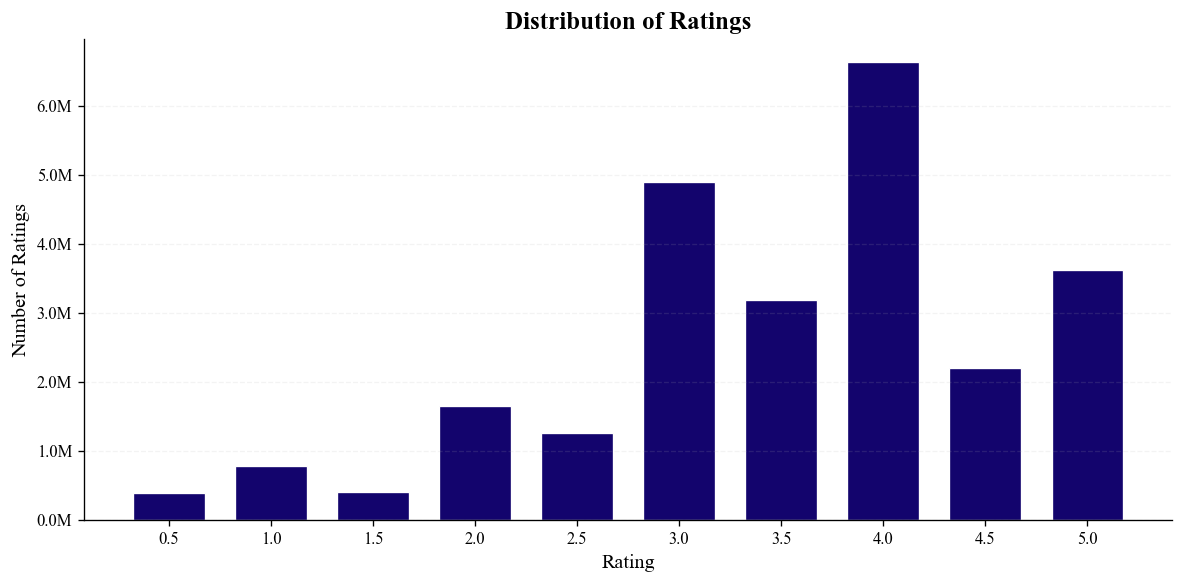

In [24]:
# ==========================================
# Rating Distribution
# ==========================================

rating_distribution = (
    ratings
    .groupby("rating")
    .agg(pl.len().alias("Count"))
    .sort("rating")
    .to_pandas()
)

plt.figure(figsize= (10, 5))

bars = plt.bar(
    rating_distribution["rating"],
    rating_distribution["Count"],
    width = 0.35,
    color= PRIMARY_COLOR,
    edgecolor= "white",
    linewidth= 0.8
)


plt.title("Distribution of Ratings", fontsize = 15, weight = "bold")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.xticks(rating_distribution["rating"])

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M")
)


plt.grid(axis= "y", linestyle= "--", alpha= 0.15)

plt.tight_layout()

plt.show()

---

# User Activity

Not every user interacts with the platform in the same way.

Some users rate only a few movies, while others are much more active. Understanding this distribution helps us better understand the interaction patterns in the dataset.

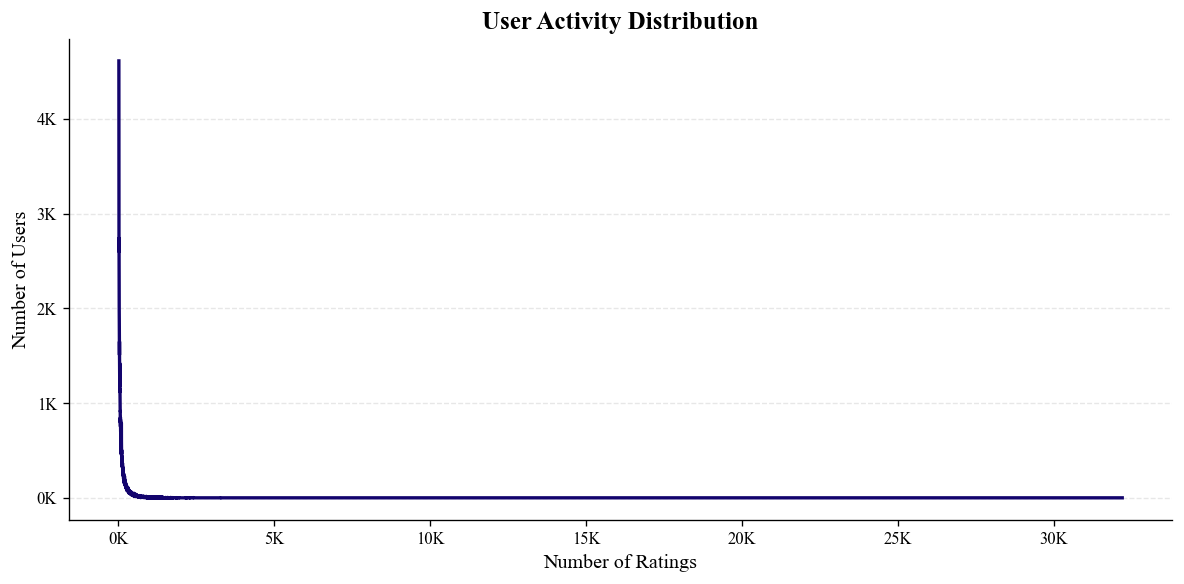

In [25]:
# ==========================================
# User Activity Distribution
# ==========================================

user_activity = (
    ratings
    .groupby("userId")
    .agg(pl.len().alias("Number of Ratings"))
)

activity_distribution = (
    user_activity
    .group_by("Number of Ratings")
    .agg(pl.len().alias("Users"))
    .sort("Number of Ratings")
    .to_pandas()
)

plt.plot(
    activity_distribution["Number of Ratings"],
    activity_distribution["Users"],
    color= PRIMARY_COLOR,
    linewidth= 2
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.title("User Activity Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.grid(axis= "y", alpha= 0.3)

plt.tight_layout()

plt.show()

---

# 20. User Activity Summary

The previous chart gives us a general view of user activity.

Now let's summarize the distribution using a few descriptive statistics to better understand how active users are across the platform.

In [26]:
# ==========================================
# User Activity Summary
# ==========================================

print(
    user_activity.select([
    pl.col("Number of Ratings").min().alias("Minimum"),
    pl.col("Number of Ratings").median().alias("Median"),
    pl.col("Number of Ratings").mean().round(2).alias("Average"),
    pl.col("Number of Ratings").quantile(0.75).alias("75th Percentile"),
    pl.col("Number of Ratings").quantile(0.90).alias("90th Percentile"),
    pl.col("Number of Ratings").max().alias("Maximum"),

])
)

shape: (1, 6)
┌─────────┬────────┬─────────┬─────────────────┬─────────────────┬─────────┐
│ Minimum ┆ Median ┆ Average ┆ 75th Percentile ┆ 90th Percentile ┆ Maximum │
│ ---     ┆ ---    ┆ ---     ┆ ---             ┆ ---             ┆ ---     │
│ u32     ┆ f64    ┆ f64     ┆ f64             ┆ f64             ┆ u32     │
╞═════════╪════════╪═════════╪═════════════════╪═════════════════╪═════════╡
│ 20      ┆ 71.0   ┆ 153.81  ┆ 162.0           ┆ 353.0           ┆ 32202   │
└─────────┴────────┴─────────┴─────────────────┴─────────────────┴─────────┘


---

# Movie Activity

Just like users, movies receive different levels of attention.

Some movies attract thousands of ratings, while many others receive only a few. Understanding this distribution helps us identify how concentrated user interactions are across the movie catalog.

In [27]:
# ==========================================
# Ratings per Movie
# ==========================================

movie_activity = (
    ratings
    .groupby("movieId")
    .agg(pl.len().alias("Number of Ratings"))
)

print(movie_activity.head())

shape: (5, 2)
┌─────────┬───────────────────┐
│ movieId ┆ Number of Ratings │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 191997  ┆ 329               │
│ 137646  ┆ 3                 │
│ 127134  ┆ 130               │
│ 94405   ┆ 613               │
│ 89570   ┆ 119               │
└─────────┴───────────────────┘


---

# Movie Activity Summary

Let's summarize movie activity using a few descriptive statistics before visualizing the distribution.

In [28]:
# ==========================================
# Movie Activity Summary
# ==========================================

print(
    movie_activity.select([
    pl.col("Number of Ratings").min().alias("Minimum"),
    pl.col("Number of Ratings").median().alias("Median"),
    pl.col("Number of Ratings").mean().round(2).alias("Average"),
    pl.col("Number of Ratings").quantile(0.75).alias("75th Percentile"),
    pl.col("Number of Ratings").quantile(0.90).alias("90th Percentile"),
    pl.col("Number of Ratings").max().alias("Maximum")
])
)

shape: (1, 6)
┌─────────┬────────┬─────────┬─────────────────┬─────────────────┬─────────┐
│ Minimum ┆ Median ┆ Average ┆ 75th Percentile ┆ 90th Percentile ┆ Maximum │
│ ---     ┆ ---    ┆ ---     ┆ ---             ┆ ---             ┆ ---     │
│ u32     ┆ f64    ┆ f64     ┆ f64             ┆ f64             ┆ u32     │
╞═════════╪════════╪═════════╪═════════════════╪═════════════════╪═════════╡
│ 1       ┆ 6.0    ┆ 423.39  ┆ 36.0            ┆ 413.0           ┆ 81491   │
└─────────┴────────┴─────────┴─────────────────┴─────────────────┴─────────┘


### Observation

These statistics help us understand how ratings are distributed across movies and whether a small number of movies dominate the interaction data.

---

# Movie Popularity Distribution

Now let's visualize how movie popularity is distributed across the catalog.

We'll focus on the majority of movies to make the pattern easier to read.

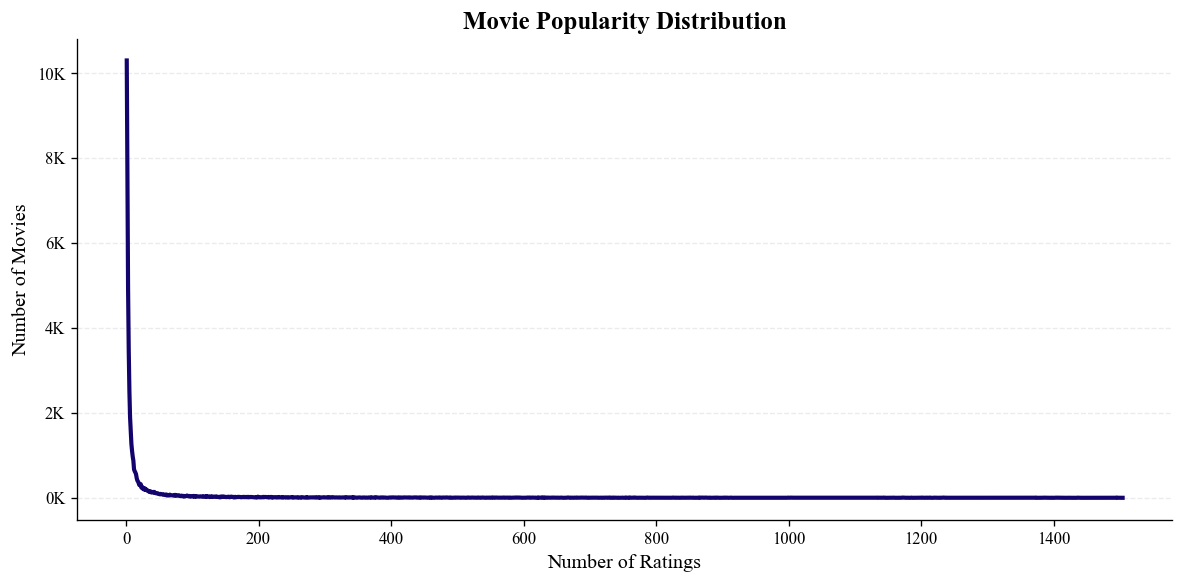

In [29]:
# ==========================================
# Movie Popularity Distribution
# ==========================================

movie_limit = (
    movie_activity.select(
        pl.col("Number of Ratings").quantile(0.95)
    )
    .item()
)

movie_distribution = (
    movie_activity
    .groupby("Number of Ratings")
    .agg(pl.len().alias("Movies"))
    .sort("Number of Ratings")
    .to_pandas()
)

filtered_movies = movie_distribution.query(
    "`Number of Ratings` <= @movie_limit"
)

plt.figure()

plt.plot(
    filtered_movies["Number of Ratings"],
    filtered_movies["Movies"],
    color= PRIMARY_COLOR,
    linewidth= 2.5
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.title("Movie Popularity Distribution")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")

plt.grid(axis= "y")

plt.tight_layout()

plt.show()

---

# Most Rated Movies

Before building recommendation models, it's useful to identify the movies that receive the highest number of ratings.

This helps us understand which movies are the most popular in terms of user interactions.

In [30]:
# ==========================================
# Top 20 Most Rated Movies
# ==========================================

top_movies = (
    ratings
    .group_by("movieId")
    .agg(pl.len().alias("Number of Ratings"))
    .join(
        movies.select(["movieId", "title"]),
        on = "movieId",
        how = "left"
    )
    .sort("Number of Ratings", descending= True)
    .select([
        "title", "Number of Ratings"
    ])
    .head(20)
)

print(top_movies)

shape: (20, 2)
┌───────────────────────────────────┬───────────────────┐
│ title                             ┆ Number of Ratings │
│ ---                               ┆ ---               │
│ str                               ┆ u32               │
╞═══════════════════════════════════╪═══════════════════╡
│ Forrest Gump (1994)               ┆ 81491             │
│ Shawshank Redemption, The (1994)  ┆ 81482             │
│ Pulp Fiction (1994)               ┆ 79672             │
│ Silence of the Lambs, The (1991)  ┆ 74127             │
│ Matrix, The (1999)                ┆ 72674             │
│ Star Wars: Episode IV - A New Ho… ┆ 68717             │
│ Jurassic Park (1993)              ┆ 64144             │
│ Schindler's List (1993)           ┆ 60411             │
│ Braveheart (1995)                 ┆ 59184             │
│ Fight Club (1999)                 ┆ 58773             │
│ Terminator 2: Judgment Day (1991… ┆ 57379             │
│ Star Wars: Episode V - The Empir… ┆ 57361             │

---

# Top 20 Most Rated Movies

A visual comparison makes it easier to see how movie popularity changes among the most frequently rated titles.

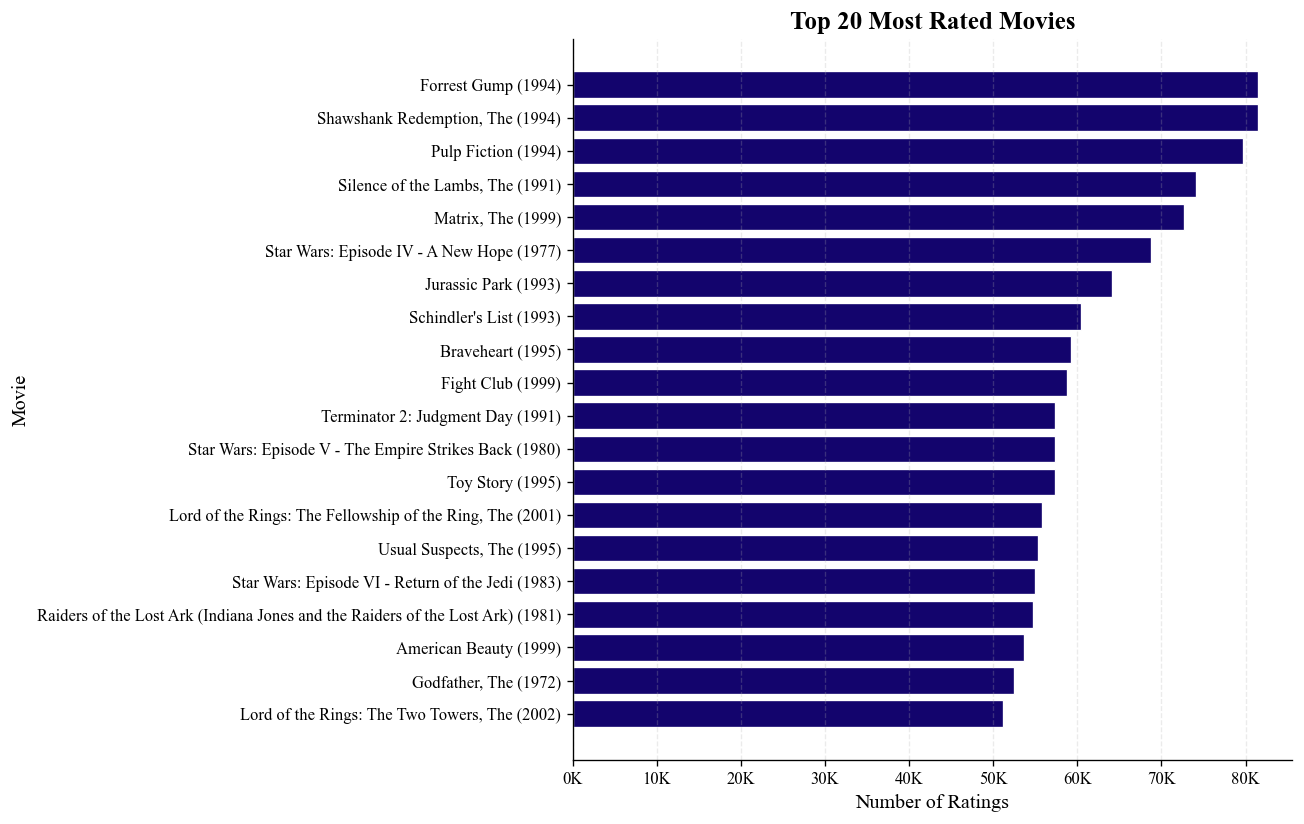

In [31]:
# ==========================================
# Top 20 Most Rated Movies
# ==========================================

top_movies_pd = (
    top_movies
    .sort("Number of Ratings")
    .to_pandas()
)

plt.figure(figsize= (11, 7))

plt.barh(
    top_movies_pd["title"],
    top_movies_pd["Number of Ratings"],
    color= PRIMARY_COLOR,
    edgecolor= "white",
    linewidth= 0.8
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.title("Top 20 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.grid(axis= "x")

plt.tight_layout()

plt.show()

---

# Average Rating vs. Number of Ratings

A high average rating does not always indicate that a movie is truly well received.

For example, a movie with only one 5-star rating would rank higher than a movie with thousands of ratings and an average of 4.8.

To make a fair comparison, we'll consider both the average rating and the number of ratings.

In [32]:
# ==========================================
# Movie Rating Statistics
# ==========================================

movie_state = (
    ratings
    .group_by("movieId")
    .agg([
        pl.len().alias("Number of Ratings"),
        pl.col("rating").mean().round(2).alias("Average Rating")
    ])
    .join(
        movies.select(["movieId" , "title"]),
        on = "movieId",
        how = "left"
    )
)

print(movie_state.head())

shape: (5, 4)
┌─────────┬───────────────────┬────────────────┬───────────────────────────────────┐
│ movieId ┆ Number of Ratings ┆ Average Rating ┆ title                             │
│ ---     ┆ ---               ┆ ---            ┆ ---                               │
│ i64     ┆ u32               ┆ f64            ┆ str                               │
╞═════════╪═══════════════════╪════════════════╪═══════════════════════════════════╡
│ 88652   ┆ 7                 ┆ 2.86           ┆ Blind Sunflowers, The (Los giras… │
│ 113105  ┆ 5                 ┆ 2.1            ┆ Mystery of the 13th Guest (1943)  │
│ 46664   ┆ 152               ┆ 3.82           ┆ Fallen Idol, The (1948)           │
│ 141812  ┆ 53                ┆ 3.68           ┆ The Most Charming and Attractive… │
│ 42385   ┆ 95                ┆ 3.13           ┆ Yamakasi - Les samouraïs des tem… │
└─────────┴───────────────────┴────────────────┴───────────────────────────────────┘


---

# Filter Movies with Very Few Ratings

Movies with only a handful of ratings may have unstable average scores.

To make the comparison more meaningful, we'll focus on movies that have received a reasonable number of ratings.

In [33]:
# ==========================================
# Movies with Enough Ratings
# ==========================================

MIN_RATINGS = 100

popular_movies = (
    movie_state
    .filter(pl.col("Number of Ratings") >= MIN_RATINGS)
)

print(popular_movies.head())

shape: (5, 4)
┌─────────┬───────────────────┬────────────────┬───────────────────────────┐
│ movieId ┆ Number of Ratings ┆ Average Rating ┆ title                     │
│ ---     ┆ ---               ┆ ---            ┆ ---                       │
│ i64     ┆ u32               ┆ f64            ┆ str                       │
╞═════════╪═══════════════════╪════════════════╪═══════════════════════════╡
│ 46664   ┆ 152               ┆ 3.82           ┆ Fallen Idol, The (1948)   │
│ 766     ┆ 1648              ┆ 3.42           ┆ I Shot Andy Warhol (1996) │
│ 206     ┆ 936               ┆ 3.45           ┆ Unzipped (1995)           │
│ 100436  ┆ 113               ┆ 3.89           ┆ Gatekeepers, The (2012)   │
│ 114713  ┆ 594               ┆ 2.75           ┆ Annabelle (2014)          │
└─────────┴───────────────────┴────────────────┴───────────────────────────┘


---

# Rating Quality vs. Popularity

This chart compares movie popularity with average rating.

It helps identify whether highly rated movies are also widely rated by users.

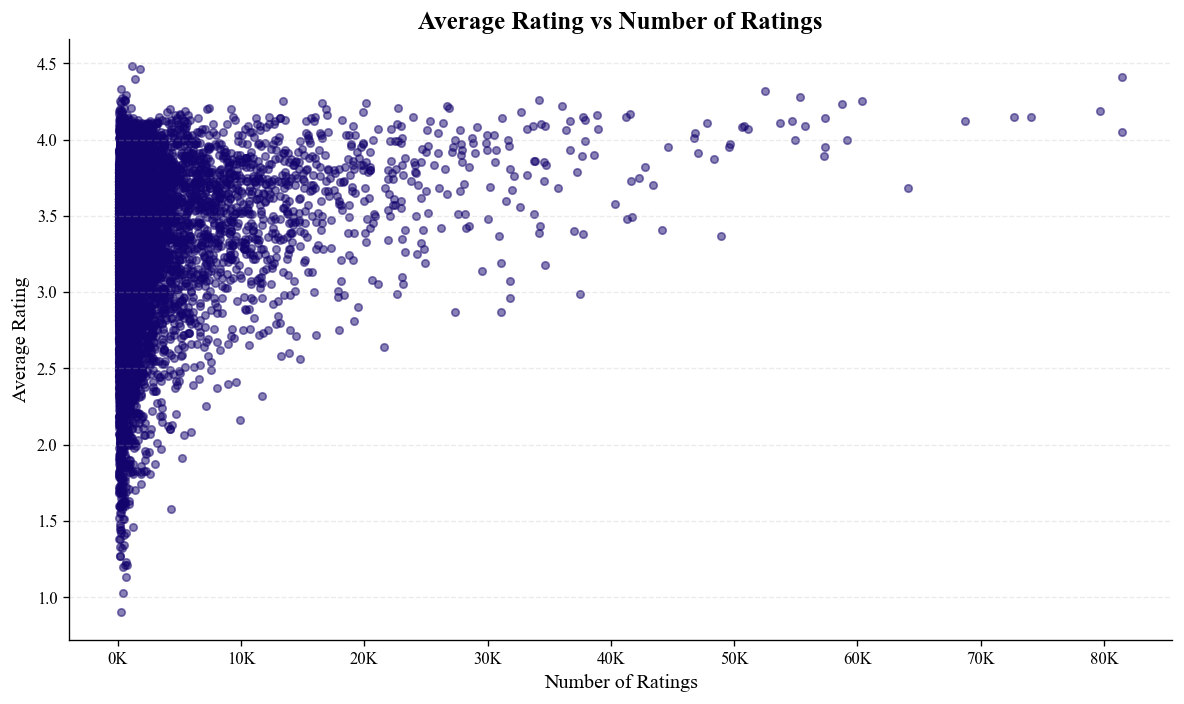

In [34]:
# ==========================================
# Rating vs Popularity
# ==========================================

plot_data = (
    popular_movies
    .select([
        "Average Rating",
        "Number of Ratings"
    ])
    .to_pandas()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["Number of Ratings"],
    plot_data["Average Rating"],
    color= PRIMARY_COLOR,
    alpha= 0.5,
    s= 20
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.title("Average Rating vs Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Average Rating")

plt.grid(axis= "y")

plt.tight_layout()

plt.show()

---

# User-Item Matrix Sparsity

Recommendation models learn from user-item interactions.

Since users usually rate only a small fraction of all available movies, the interaction matrix is expected to be highly sparse.

Let's measure how sparse our dataset actually is.

In [35]:
# ==========================================
# User-Item Matrix Sparsity
# ==========================================

n_users = ratings["userId"].n_unique()
n_movies = ratings["movieId"].n_unique()
n_ratings = ratings.height

total_possible_interactions = n_users * n_movies

sparsity = (
    1 - (n_ratings / total_possible_interactions) * 100
)

sparsity_summary = pl.DataFrame({
    "Metric": [
        "Users",
        "Movies",
        "Ratings",
        "Possible Interactions",
        "Matrix Sparsity (%)"
    ],
    "Value": [
        n_users,
        n_movies,
        n_ratings,
        total_possible_interactions,
        round(sparsity, 2)
    ]
})

print(sparsity_summary)

shape: (5, 2)
┌───────────────────────┬─────────────┐
│ Metric                ┆ Value       │
│ ---                   ┆ ---         │
│ str                   ┆ f64         │
╞═══════════════════════╪═════════════╡
│ Users                 ┆ 162541.0    │
│ Movies                ┆ 59047.0     │
│ Ratings               ┆ 2.5000095e7 │
│ Possible Interactions ┆ 9.5976e9    │
│ Matrix Sparsity (%)   ┆ 0.74        │
└───────────────────────┴─────────────┘


---

# Observed vs Possible Interactions

The interaction matrix contains only a small number of observed ratings compared to all possible user-movie combinations.

This comparison illustrates the scale of missing interactions in the dataset.

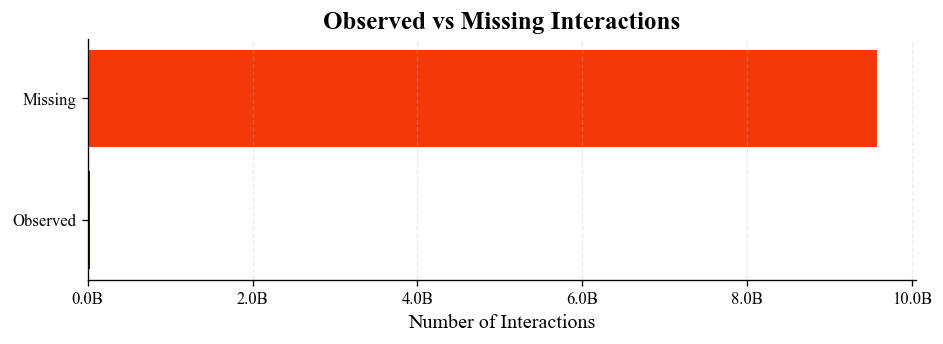

In [36]:
# ==========================================
# Observed vs Possible Interactions
# ==========================================

interaction_summary = pl.DataFrame({
    "Category": [
        "Observed",
        "Missing"
    ],
    "Interactions": [
        n_ratings,
        total_possible_interactions - n_ratings
    ]
}).to_pandas()

plt.figure(figsize=(8,3))

plt.barh(
    interaction_summary["Category"],
    interaction_summary["Interactions"],
    color=[PRIMARY_COLOR, SECONDARY_COLOR]
)

plt.title("Observed vs Missing Interactions")
plt.xlabel("Number of Interactions")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1_000_000_000:.1f}B")
)

plt.grid(axis="x")

plt.tight_layout()

plt.show()

### Observation

Only a very small portion of all possible user-movie interactions is observed.

This level of sparsity is common in real-world recommendation systems and highlights the importance of algorithms that can learn effectively from limited interaction data.

---

# Rating Activity Over Time

The dataset includes a timestamp for every rating.

Before building recommendation models, it's useful to understand how user activity changes over time and whether interactions are evenly distributed across the dataset.

In [37]:
# ==========================================
# Convert Timestamp to Date
# ==========================================

ratings_with_date = (
    ratings
    .with_columns(
        pl.from_epoch("timestamp", time_unit="s").alias("date")
    )
)

print(
    ratings_with_date.select([
    pl.col("date").min().alias("First Rating"),
    pl.col("date").max().alias("Last Rating")
])
)

shape: (1, 2)
┌─────────────────────┬─────────────────────┐
│ First Rating        ┆ Last Rating         │
│ ---                 ┆ ---                 │
│ datetime[μs]        ┆ datetime[μs]        │
╞═════════════════════╪═════════════════════╡
│ 1995-01-09 11:46:49 ┆ 2019-11-21 09:15:03 │
└─────────────────────┴─────────────────────┘


---

# Rating Activity by Year

Now let's see how the number of ratings changes over the years.

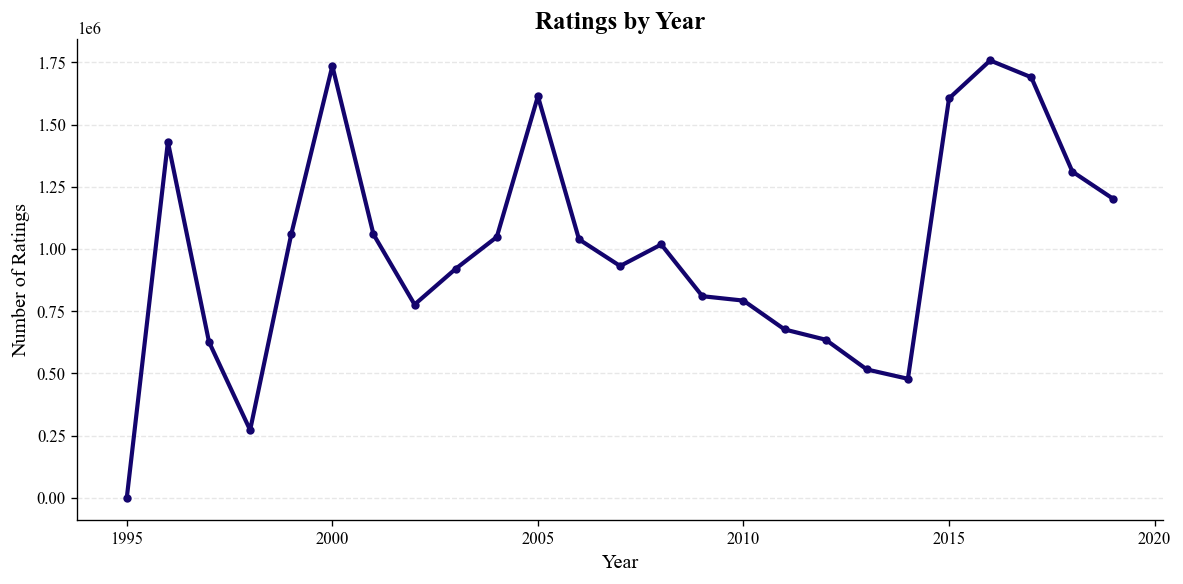

In [38]:
# ==========================================
# Ratings per Year
# ==========================================

ratings_per_year = (
    ratings_with_date
    .with_columns(
        pl.col("date").dt.year().alias("Year")
    )
    .group_by("Year")
    .agg(
        pl.len().alias("Ratings")
    )
    .sort("Year")
    .to_pandas()
)

plt.figure()

plt.plot(
    ratings_per_year["Year"],
    ratings_per_year["Ratings"],
    color=PRIMARY_COLOR,
    linewidth= 2.5,
    marker="o",
    markersize= 4
)

plt.title("Ratings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.grid(axis= "y", alpha= 0.3)

plt.tight_layout()

plt.show()

---

# Movie Genres

Movies can belong to one or more genres.

Before using genre information in recommendation models, let's explore how genres are distributed across the dataset.

In [39]:
# ==========================================
# Genre Distribution
# ==========================================

genre_distribution = (
    movies
    .select(
        pl.col("genres")
        .str.split("|")
        .alias("genre")
    )
    .explode("genre")
    .group_by("genre")
    .agg(
        pl.len().alias("Movies")
    )
    .sort("Movies", descending=True)
)

print(genre_distribution)

shape: (20, 2)
┌────────────────────┬────────┐
│ genre              ┆ Movies │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ Drama              ┆ 25606  │
│ Comedy             ┆ 16870  │
│ Thriller           ┆ 8654   │
│ Romance            ┆ 7719   │
│ Action             ┆ 7348   │
│ Horror             ┆ 5989   │
│ Documentary        ┆ 5605   │
│ Crime              ┆ 5319   │
│ (no genres listed) ┆ 5062   │
│ Adventure          ┆ 4145   │
│ Sci-Fi             ┆ 3595   │
│ Children           ┆ 2935   │
│ Animation          ┆ 2929   │
│ Mystery            ┆ 2925   │
│ Fantasy            ┆ 2731   │
│ War                ┆ 1874   │
│ Western            ┆ 1399   │
│ Musical            ┆ 1054   │
│ Film-Noir          ┆ 353    │
│ IMAX               ┆ 195    │
└────────────────────┴────────┘


---

# Genre Distribution

A visual overview makes it easier to compare how frequently different genres appear in the dataset.

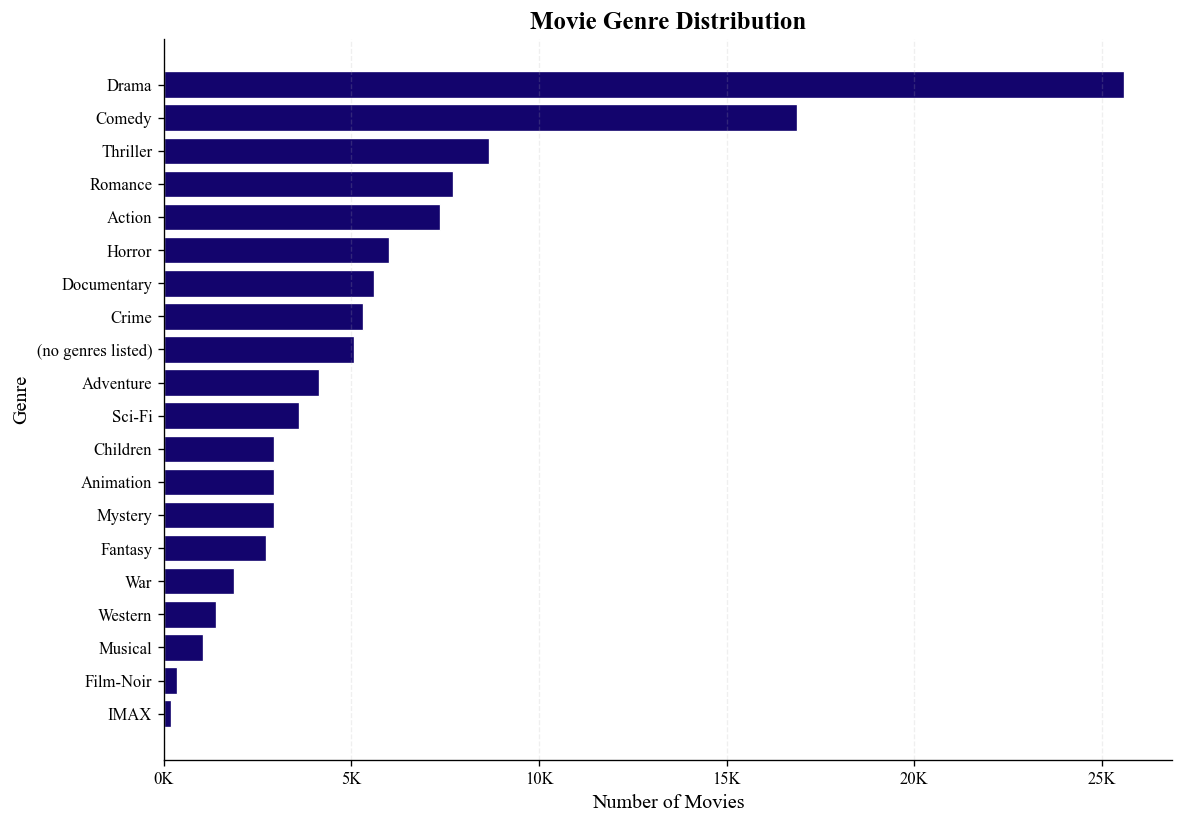

In [40]:
# ==========================================
# Genre Distribution Chart
# ==========================================

genre_plot = (
    genre_distribution
    .sort("Movies")
    .to_pandas()
)

plt.figure(figsize= (10, 7))

plt.barh(
    genre_plot["genre"],
    genre_plot["Movies"],
    color= PRIMARY_COLOR,
    edgecolor= "white",
    linewidth= 0.8
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.grid(axis= "x", alpha= 0.2)

plt.tight_layout()

plt.show()

---

# Number of Genres per Movie

Movies often belong to more than one genre.

Understanding how many genres are assigned to each movie gives us a better picture of the richness of the available metadata.

In [41]:
# ==========================================
# Genres per Movie
# ==========================================

genres_per_movie = (
    movies.select(
        pl.col("genres")
        .str.split("|").list.len().alias("Number of Genres")
    )
)

print(
    genres_per_movie.select([
    pl.col("Number of Genres").min().alias("Minimum"),
    pl.col("Number of Genres").median().alias("Median"),
    pl.col("Number of Genres").mean().round(2).alias("Average"),
    pl.col("Number of Genres").max().alias("Maximum")
])
)

shape: (1, 4)
┌─────────┬────────┬─────────┬─────────┐
│ Minimum ┆ Median ┆ Average ┆ Maximum │
│ ---     ┆ ---    ┆ ---     ┆ ---     │
│ u32     ┆ f64    ┆ f64     ┆ u32     │
╞═════════╪════════╪═════════╪═════════╡
│ 1       ┆ 2.0    ┆ 1.8     ┆ 10      │
└─────────┴────────┴─────────┴─────────┘


---

# Preparing Data for Recommendation Models

The exploratory analysis provided a better understanding of the dataset and user behavior.

From this point forward, the focus shifts toward preparing the data for building recommendation models.

The goal is to create a clean and consistent interaction dataset that can be shared across multiple recommendation approaches.

In [42]:
# ==========================================
# Interaction Dataset
# ==========================================

interactions = (
    ratings.select([
        "userId" , "movieId" , "rating" , "timestamp"
    ])
)

print(interactions.head())

shape: (5, 4)
┌────────┬─────────┬────────┬────────────┐
│ userId ┆ movieId ┆ rating ┆ timestamp  │
│ ---    ┆ ---     ┆ ---    ┆ ---        │
│ i64    ┆ i64     ┆ f64    ┆ i64        │
╞════════╪═════════╪════════╪════════════╡
│ 1      ┆ 296     ┆ 5.0    ┆ 1147880044 │
│ 1      ┆ 306     ┆ 3.5    ┆ 1147868817 │
│ 1      ┆ 307     ┆ 5.0    ┆ 1147868828 │
│ 1      ┆ 665     ┆ 5.0    ┆ 1147878820 │
│ 1      ┆ 899     ┆ 3.5    ┆ 1147868510 │
└────────┴─────────┴────────┴────────────┘


---

# Final Data Validation

In [43]:
# ==========================================
# Final Validation
# ==========================================

print(interactions.null_count())

shape: (1, 4)
┌────────┬─────────┬────────┬───────────┐
│ userId ┆ movieId ┆ rating ┆ timestamp │
│ ---    ┆ ---     ┆ ---    ┆ ---       │
│ u32    ┆ u32     ┆ u32    ┆ u32       │
╞════════╪═════════╪════════╪═══════════╡
│ 0      ┆ 0       ┆ 0      ┆ 0         │
└────────┴─────────┴────────┴───────────┘


---

# 39. User Filtering Strategy

Not every user contributes enough information for collaborative filtering models.

Before training the models, we'll examine whether filtering very inactive users improves the quality of recommendations.

---

# User Filtering Analysis

Collaborative filtering models require enough interaction history to learn user preferences.

Instead of selecting a filtering threshold arbitrarily, we'll first examine the distribution of user activity.

In [44]:
# ==========================================
# User Activity Percentiles
# ==========================================

print(
    user_activity.select([
    pl.col("Number of Ratings").quantile(0.25).alias("25%"),
    pl.col("Number of Ratings").median().alias("50%"),
    pl.col("Number of Ratings").quantile(0.75).alias("75%"),
    pl.col("Number of Ratings").quantile(0.90).alias("90%"),
    pl.col("Number of Ratings").quantile(0.95).alias("95%"),
    pl.col("Number of Ratings").quantile(0.99).alias("99%")
])
)

shape: (1, 6)
┌──────┬──────┬───────┬───────┬───────┬────────┐
│ 25%  ┆ 50%  ┆ 75%   ┆ 90%   ┆ 95%   ┆ 99%    │
│ ---  ┆ ---  ┆ ---   ┆ ---   ┆ ---   ┆ ---    │
│ f64  ┆ f64  ┆ f64   ┆ f64   ┆ f64   ┆ f64    │
╞══════╪══════╪═══════╪═══════╪═══════╪════════╡
│ 36.0 ┆ 71.0 ┆ 162.0 ┆ 353.0 ┆ 554.0 ┆ 1228.0 │
└──────┴──────┴───────┴───────┴───────┴────────┘


---

# Movie Filtering Analysis

The same idea applies to movies.

Some movies receive only a handful of ratings, making them difficult to recommend reliably.

Let's inspect their distribution before applying any filtering.

In [45]:
# ==========================================
# Movie Activity Percentiles
# ==========================================

print(
    movie_activity.select([
    pl.col("Number of Ratings").quantile(0.25).alias("25%"),
    pl.col("Number of Ratings").median().alias("50%"),
    pl.col("Number of Ratings").quantile(0.75).alias("75%"),
    pl.col("Number of Ratings").quantile(0.90).alias("90%"),
    pl.col("Number of Ratings").quantile(0.95).alias("95%"),
    pl.col("Number of Ratings").quantile(0.99).alias("99%")
])
)

shape: (1, 6)
┌─────┬─────┬──────┬───────┬────────┬────────┐
│ 25% ┆ 50% ┆ 75%  ┆ 90%   ┆ 95%    ┆ 99%    │
│ --- ┆ --- ┆ ---  ┆ ---   ┆ ---    ┆ ---    │
│ f64 ┆ f64 ┆ f64  ┆ f64   ┆ f64    ┆ f64    │
╞═════╪═════╪══════╪═══════╪════════╪════════╡
│ 2.0 ┆ 6.0 ┆ 36.0 ┆ 413.0 ┆ 1504.0 ┆ 9943.0 │
└─────┴─────┴──────┴───────┴────────┴────────┘


---

# 42. Threshold Sensitivity Analysis

Before filtering the dataset, it's useful to estimate how different thresholds affect the number of remaining users.

This allows us to balance data quality and data coverage.

In [46]:
# ==========================================
# User Threshold Analysis
# ==========================================

thresholds = [1, 5, 10, 20, 50, 100]

threshold_summary = []

for threshold in thresholds:

    remaining_users = (
        user_activity
        .filter(
            pl.col("Number of Ratings") >= threshold
        )
        .height
    )

    threshold_summary.append({
        "Minimum Ratings": threshold,
        "Remaining Users": remaining_users
    })

threshold_summary = pl.DataFrame(threshold_summary)

print(threshold_summary)

shape: (6, 2)
┌─────────────────┬─────────────────┐
│ Minimum Ratings ┆ Remaining Users │
│ ---             ┆ ---             │
│ i64             ┆ i64             │
╞═════════════════╪═════════════════╡
│ 1               ┆ 162541          │
│ 5               ┆ 162541          │
│ 10              ┆ 162541          │
│ 20              ┆ 162541          │
│ 50              ┆ 102492          │
│ 100             ┆ 63892           │
└─────────────────┴─────────────────┘


---

# Movie Filtering Analysis

Unlike users, many movies receive only a small number of ratings.

Movies with extremely limited interaction history provide little information for collaborative filtering models.

Before applying any filtering, let's examine how different thresholds affect the dataset.

In [47]:
# ==========================================
# Movie Threshold Analysis
# ==========================================

movie_thresholds = [1, 5, 10, 20, 50, 100, 500, 1000]

movie_threshold_summary = []

for threshold in movie_thresholds:

    remaining_movies = (
        movie_activity
        .filter(pl.col("Number of Ratings") >= threshold)
        .height
    )

    movie_threshold_summary.append({
        "Minimum Ratings": threshold,
        "Remaining Movies": remaining_movies
    })

movie_threshold_summary = pl.DataFrame(movie_threshold_summary)

print(movie_threshold_summary)

shape: (8, 2)
┌─────────────────┬──────────────────┐
│ Minimum Ratings ┆ Remaining Movies │
│ ---             ┆ ---              │
│ i64             ┆ i64              │
╞═════════════════╪══════════════════╡
│ 1               ┆ 59047            │
│ 5               ┆ 32720            │
│ 10              ┆ 24330            │
│ 20              ┆ 18430            │
│ 50              ┆ 13176            │
│ 100             ┆ 10326            │
│ 500             ┆ 5386             │
│ 1000            ┆ 3794             │
└─────────────────┴──────────────────┘


---

# 44. Remaining Movies After Filtering

In [48]:
# ==========================================
# Remaining Movie Percentage
# ==========================================

total_movies = movie_activity.height

movie_threshold_summary = (
    movie_threshold_summary
    .with_columns(
        (
            pl.col("Remaining Movies") / total_movies * 100
        )
        .round(2)
        .alias("Remaining (%)")
    )
)

print(movie_threshold_summary)

shape: (8, 3)
┌─────────────────┬──────────────────┬───────────────┐
│ Minimum Ratings ┆ Remaining Movies ┆ Remaining (%) │
│ ---             ┆ ---              ┆ ---           │
│ i64             ┆ i64              ┆ f64           │
╞═════════════════╪══════════════════╪═══════════════╡
│ 1               ┆ 59047            ┆ 100.0         │
│ 5               ┆ 32720            ┆ 55.41         │
│ 10              ┆ 24330            ┆ 41.2          │
│ 20              ┆ 18430            ┆ 31.21         │
│ 50              ┆ 13176            ┆ 22.31         │
│ 100             ┆ 10326            ┆ 17.49         │
│ 500             ┆ 5386             ┆ 9.12          │
│ 1000            ┆ 3794             ┆ 6.43          │
└─────────────────┴──────────────────┴───────────────┘


---

# Effect of Movie Filtering Thresholds

The chart below shows how increasing the minimum number of ratings reduces the number of movies available for training.

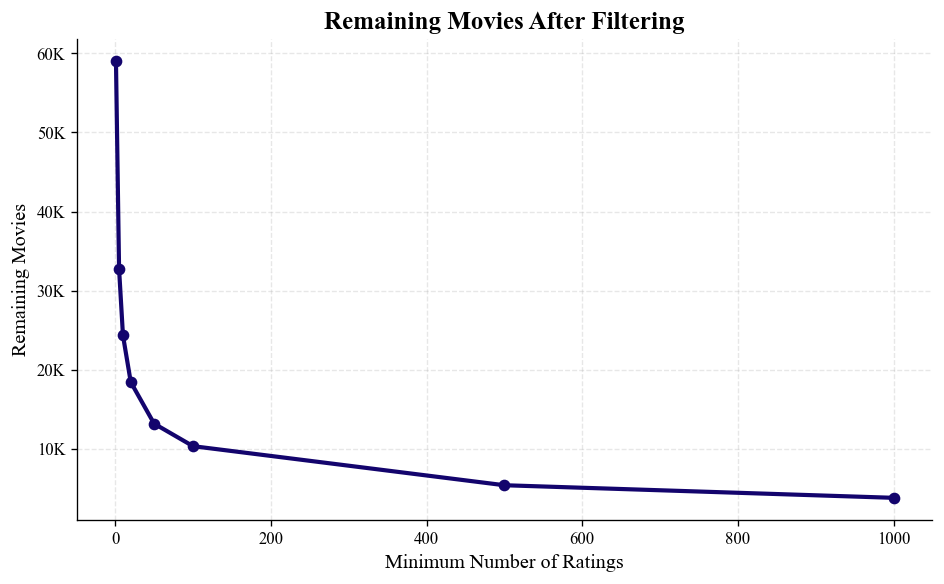

In [49]:
# ==========================================
# Remaining Movies Across Thresholds
# ==========================================

movie_threshold_plot = movie_threshold_summary.to_pandas()

plt.figure(figsize= (8, 5))

plt.plot(
    movie_threshold_plot["Minimum Ratings"],
    movie_threshold_plot["Remaining Movies"],
    marker= "o",
    linewidth= 2.5,
    color= PRIMARY_COLOR
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x/1000:.0f}K")
)

plt.title("Remaining Movies After Filtering")
plt.xlabel("Minimum Number of Ratings")
plt.ylabel("Remaining Movies")

plt.grid(alpha= 0.3)

plt.tight_layout()

plt.show()

---

# TMDB Metadata

To support content-based recommendation, we'll use the TMDB movie metadata dataset.

Unlike MovieLens, TMDB provides rich information such as movie overviews, cast, crew, keywords and production details.

At this stage, the dataset is loaded and explored independently before merging it with MovieLens.

### Dataset Overview

Before merging the datasets, let's inspect their structure and understand the information each file contains.

In [50]:
# ==========================================
# TMDB Dataset Overview
# ==========================================

for name, df in {
    "TMDB Movies": tmdb_movies,
    "TMDB Credits": tmdb_credits
}.items():

    print("=" * 80)
    print(name)
    print("=" * 80)
    

    print(
        pl.DataFrame({
            "Rows": [df.height],
            "Columns": [df.width]
        })
    )

    print(df.head())

TMDB Movies
shape: (1, 2)
┌──────┬─────────┐
│ Rows ┆ Columns │
│ ---  ┆ ---     │
│ i64  ┆ i64     │
╞══════╪═════════╡
│ 4803 ┆ 20      │
└──────┴─────────┘
shape: (5, 20)
┌─────────┬─────────┬─────────┬────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ budget  ┆ genres  ┆ homepag ┆ id     ┆ keyword ┆ origina ┆ origina ┆ overvie ┆ popular ┆ product ┆ product ┆ release ┆ revenue ┆ runtime ┆ spoken_ ┆ status  ┆ tagline ┆ title   ┆ vote_av ┆ vote_co │
│ ---     ┆ ---     ┆ e       ┆ ---    ┆ s       ┆ l_langu ┆ l_title ┆ w       ┆ ity     ┆ ion_com ┆ ion_cou ┆ _date   ┆ ---     ┆ ---     ┆ languag ┆ ---     ┆ ---     ┆ ---     ┆ erage   ┆ unt     │
│ i64     ┆ str     ┆ ---     ┆ i64    ┆ ---     ┆ age     ┆ ---     ┆ ---     ┆ ---     ┆ panies  ┆ ntries  ┆ ---     ┆ i64     ┆ f64     ┆ es      ┆ str     ┆ str     ┆ str     ┆ ---     ┆ ---     │
│         ┆         ┆ 

### Dataset Overview

Let's take a quick look at the size of each dataset before exploring their contents.

In [51]:
# ==========================================
# TMDB Dataset Summary
# ==========================================

tmdb_summary = pl.DataFrame({
    "Dataset": [
        "TMDB Movies",
        "TMDB Credits"
    ],
    "Rows": [
        tmdb_movies.height,
        tmdb_credits.height
    ],
    "Columns": [
        tmdb_movies.width,
        tmdb_credits.width
    ]
})

print(tmdb_summary)

shape: (2, 3)
┌──────────────┬──────┬─────────┐
│ Dataset      ┆ Rows ┆ Columns │
│ ---          ┆ ---  ┆ ---     │
│ str          ┆ i64  ┆ i64     │
╞══════════════╪══════╪═════════╡
│ TMDB Movies  ┆ 4803 ┆ 20      │
│ TMDB Credits ┆ 4803 ┆ 4       │
└──────────────┴──────┴─────────┘


### Preview

A quick preview helps verify that the datasets have been loaded correctly and gives an overview of their structure.

In [52]:
# ==========================================
# Preview TMDB Movies
# ==========================================

print(tmdb_movies.head())

shape: (5, 20)
┌─────────┬─────────┬─────────┬────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ budget  ┆ genres  ┆ homepag ┆ id     ┆ keyword ┆ origina ┆ origina ┆ overvie ┆ popular ┆ product ┆ product ┆ release ┆ revenue ┆ runtime ┆ spoken_ ┆ status  ┆ tagline ┆ title   ┆ vote_av ┆ vote_co │
│ ---     ┆ ---     ┆ e       ┆ ---    ┆ s       ┆ l_langu ┆ l_title ┆ w       ┆ ity     ┆ ion_com ┆ ion_cou ┆ _date   ┆ ---     ┆ ---     ┆ languag ┆ ---     ┆ ---     ┆ ---     ┆ erage   ┆ unt     │
│ i64     ┆ str     ┆ ---     ┆ i64    ┆ ---     ┆ age     ┆ ---     ┆ ---     ┆ ---     ┆ panies  ┆ ntries  ┆ ---     ┆ i64     ┆ f64     ┆ es      ┆ str     ┆ str     ┆ str     ┆ ---     ┆ ---     │
│         ┆         ┆ str     ┆        ┆ str     ┆ ---     ┆ str     ┆ str     ┆ f64     ┆ ---     ┆ ---     ┆ str     ┆         ┆         ┆ ---     ┆         ┆         ┆         ┆ 

In [53]:
# ==========================================
# Preview TMDB Credits
# ==========================================

print(tmdb_credits.head())

shape: (5, 4)
┌──────────┬───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┐
│ movie_id ┆ title                             ┆ cast                              ┆ crew                              │
│ ---      ┆ ---                               ┆ ---                               ┆ ---                               │
│ i64      ┆ str                               ┆ str                               ┆ str                               │
╞══════════╪═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╡
│ 19995    ┆ Avatar                            ┆ [{"cast_id": 242, "character": "… ┆ [{"credit_id": "52fe48009251416c… │
│ 285      ┆ Pirates of the Caribbean: At Wor… ┆ [{"cast_id": 4, "character": "Ca… ┆ [{"credit_id": "52fe4232c3a36847… │
│ 206647   ┆ Spectre                           ┆ [{"cast_id": 1, "character": "Ja… ┆ [{"credit_id": "54805967c3a36829… │
│ 49026    ┆ The D

### Column Information

Understanding the available columns helps identify which features may be useful for content-based recommendation later in the project.

In [54]:
# ==========================================
# TMDB Movies Schema
# ==========================================

tmdb_movies.schema

OrderedDict([('budget', Int64),
             ('genres', String),
             ('homepage', String),
             ('id', Int64),
             ('keywords', String),
             ('original_language', String),
             ('original_title', String),
             ('overview', String),
             ('popularity', Float64),
             ('production_companies', String),
             ('production_countries', String),
             ('release_date', String),
             ('revenue', Int64),
             ('runtime', Float64),
             ('spoken_languages', String),
             ('status', String),
             ('tagline', String),
             ('title', String),
             ('vote_average', Float64),
             ('vote_count', Int64)])

In [55]:
# ==========================================
# TMDB Credits Schema
# ==========================================

tmdb_credits.schema

OrderedDict([('movie_id', Int64),
             ('title', String),
             ('cast', String),
             ('crew', String)])

### Missing Values

Before using TMDB metadata, we'll check whether any important columns contain missing values.

In [56]:
# ==========================================
# Missing Values in TMDB Movies
# ==========================================

print(
    tmdb_movies.null_count().transpose(
    include_header= True,
    header_name= "Column"
)
)

shape: (20, 2)
┌──────────────────────┬──────────┐
│ Column               ┆ column_0 │
│ ---                  ┆ ---      │
│ str                  ┆ u32      │
╞══════════════════════╪══════════╡
│ budget               ┆ 0        │
│ genres               ┆ 0        │
│ homepage             ┆ 3091     │
│ id                   ┆ 0        │
│ keywords             ┆ 0        │
│ original_language    ┆ 0        │
│ original_title       ┆ 0        │
│ overview             ┆ 3        │
│ popularity           ┆ 0        │
│ production_companies ┆ 0        │
│ production_countries ┆ 0        │
│ release_date         ┆ 1        │
│ revenue              ┆ 0        │
│ runtime              ┆ 2        │
│ spoken_languages     ┆ 0        │
│ status               ┆ 0        │
│ tagline              ┆ 844      │
│ title                ┆ 0        │
│ vote_average         ┆ 0        │
│ vote_count           ┆ 0        │
└──────────────────────┴──────────┘


In [57]:
# ==========================================
# Missing Values in TMDB Credits
# ==========================================

print(
    tmdb_credits.null_count().transpose(
    include_header= True,
    header_name= "Column"
)
)

shape: (4, 2)
┌──────────┬──────────┐
│ Column   ┆ column_0 │
│ ---      ┆ ---      │
│ str      ┆ u32      │
╞══════════╪══════════╡
│ movie_id ┆ 0        │
│ title    ┆ 0        │
│ cast     ┆ 0        │
│ crew     ┆ 0        │
└──────────┴──────────┘


---

# Understanding TMDB Metadata

Some columns in the TMDB dataset contain structured JSON data rather than plain text.

Instead of using these values directly, we'll extract only the information that is useful for building content-based recommendation models.

This keeps the dataset compact and avoids carrying unnecessary features throughout the project.

In [58]:
# ==========================================
# Preview JSON Columns
# ==========================================

json_preview = tmdb_movies.select([
    "genres",
    "keywords"
]).head(3)

print(json_preview)

shape: (3, 2)
┌───────────────────────────────────┬───────────────────────────────────┐
│ genres                            ┆ keywords                          │
│ ---                               ┆ ---                               │
│ str                               ┆ str                               │
╞═══════════════════════════════════╪═══════════════════════════════════╡
│ [{"id": 28, "name": "Action"}, {… ┆ [{"id": 1463, "name": "culture c… │
│ [{"id": 12, "name": "Adventure"}… ┆ [{"id": 270, "name": "ocean"}, {… │
│ [{"id": 28, "name": "Action"}, {… ┆ [{"id": 470, "name": "spy"}, {"i… │
└───────────────────────────────────┴───────────────────────────────────┘


In [59]:
# ==========================================
# Preview Credits Columns
# ==========================================

print(
    tmdb_credits.select([
    "cast",
    "crew"
]).head(2)
)

shape: (2, 2)
┌───────────────────────────────────┬───────────────────────────────────┐
│ cast                              ┆ crew                              │
│ ---                               ┆ ---                               │
│ str                               ┆ str                               │
╞═══════════════════════════════════╪═══════════════════════════════════╡
│ [{"cast_id": 242, "character": "… ┆ [{"credit_id": "52fe48009251416c… │
│ [{"cast_id": 4, "character": "Ca… ┆ [{"credit_id": "52fe4232c3a36847… │
└───────────────────────────────────┴───────────────────────────────────┘


---

# Helper Function for JSON Parsing

Several TMDB columns share the same JSON structure.

Instead of writing separate parsing logic for each column, we'll create a reusable helper function to keep the code cleaner and easier to maintain.

In [60]:
# ==========================================
# JSON Parser
# ==========================================

def extract_names(json_text):
    """
    Extract the 'name' field from a TMDB JSON string.

    Parameters
    ----------
    json_text : str

    Returns
    -------
    list[str]
    """

    if json_text is None:
        return []

    try:
        data = json.loads(json_text)
        return [item["name"] for item in data]

    except Exception:
        return []

In [61]:
print(
    tmdb_movies.with_columns(
    pl.col("genres").map_elements(extract_names),
    pl.col("keywords").map_elements(extract_names)
)
)

shape: (4_803, 20)
┌─────────┬─────────┬─────────┬────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ budget  ┆ genres  ┆ homepag ┆ id     ┆ keyword ┆ origina ┆ origina ┆ overvie ┆ popular ┆ product ┆ product ┆ release ┆ revenue ┆ runtime ┆ spoken_ ┆ status  ┆ tagline ┆ title   ┆ vote_av ┆ vote_co │
│ ---     ┆ ---     ┆ e       ┆ ---    ┆ s       ┆ l_langu ┆ l_title ┆ w       ┆ ity     ┆ ion_com ┆ ion_cou ┆ _date   ┆ ---     ┆ ---     ┆ languag ┆ ---     ┆ ---     ┆ ---     ┆ erage   ┆ unt     │
│ i64     ┆ list[st ┆ ---     ┆ i64    ┆ ---     ┆ age     ┆ ---     ┆ ---     ┆ ---     ┆ panies  ┆ ntries  ┆ ---     ┆ i64     ┆ f64     ┆ es      ┆ str     ┆ str     ┆ str     ┆ ---     ┆ ---     │
│         ┆ r]      ┆ str     ┆        ┆ list[st ┆ ---     ┆ str     ┆ str     ┆ f64     ┆ ---     ┆ ---     ┆ str     ┆         ┆         ┆ ---     ┆         ┆         ┆       

### Inspecting JSON Structure

Before parsing an entire column, it's a good practice to inspect a few raw values.

This helps verify the structure of the JSON data and ensures that our parsing function matches the actual format of the dataset.

In [62]:
# ==========================================
# Inspect Raw Genres
# ==========================================

print(tmdb_movies.select("genres").head(5))

shape: (5, 1)
┌───────────────────────────────────┐
│ genres                            │
│ ---                               │
│ str                               │
╞═══════════════════════════════════╡
│ [{"id": 28, "name": "Action"}, {… │
│ [{"id": 12, "name": "Adventure"}… │
│ [{"id": 28, "name": "Action"}, {… │
│ [{"id": 28, "name": "Action"}, {… │
│ [{"id": 28, "name": "Action"}, {… │
└───────────────────────────────────┘


In [63]:
print(tmdb_movies.head())

shape: (5, 20)
┌─────────┬─────────┬─────────┬────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┬─────────┐
│ budget  ┆ genres  ┆ homepag ┆ id     ┆ keyword ┆ origina ┆ origina ┆ overvie ┆ popular ┆ product ┆ product ┆ release ┆ revenue ┆ runtime ┆ spoken_ ┆ status  ┆ tagline ┆ title   ┆ vote_av ┆ vote_co │
│ ---     ┆ ---     ┆ e       ┆ ---    ┆ s       ┆ l_langu ┆ l_title ┆ w       ┆ ity     ┆ ion_com ┆ ion_cou ┆ _date   ┆ ---     ┆ ---     ┆ languag ┆ ---     ┆ ---     ┆ ---     ┆ erage   ┆ unt     │
│ i64     ┆ str     ┆ ---     ┆ i64    ┆ ---     ┆ age     ┆ ---     ┆ ---     ┆ ---     ┆ panies  ┆ ntries  ┆ ---     ┆ i64     ┆ f64     ┆ es      ┆ str     ┆ str     ┆ str     ┆ ---     ┆ ---     │
│         ┆         ┆ str     ┆        ┆ str     ┆ ---     ┆ str     ┆ str     ┆ f64     ┆ ---     ┆ ---     ┆ str     ┆         ┆         ┆ ---     ┆         ┆         ┆         ┆ 

In [64]:
tmdb_movies.schema["genres"]

String

### Testing the Parser

Before applying the parser to the full dataset, we'll test it on a single record to verify that the extracted values match our expectations.

In [65]:
# ==========================================
# Test JSON Parser
# ==========================================

sample_genres = (
    tmdb_movies
    .select("genres")
    .item(0, 0)
)

extract_names(sample_genres)

['Action', 'Adventure', 'Fantasy', 'Science Fiction']

---

# Parsing Genre Information

Now that the parser has been verified on a sample record, we can safely apply it to the entire dataset.

Instead of replacing the original column, a new column will be created. Keeping the raw data unchanged makes validation easier and allows us to compare the parsed values with the original JSON whenever needed.

In [66]:
# ==========================================
# Parse Genres
# ==========================================

tmdb_movies = tmdb_movies.with_columns(
    pl.col("genres")
    .map_elements(extract_names)
    .alias("genres_list")
)

print(
    tmdb_movies.select(
    "title",
    "genres",
    "genres_list"
).head()
)

shape: (5, 3)
┌───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┐
│ title                             ┆ genres                            ┆ genres_list                       │
│ ---                               ┆ ---                               ┆ ---                               │
│ str                               ┆ str                               ┆ list[str]                         │
╞═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╡
│ Avatar                            ┆ [{"id": 28, "name": "Action"}, {… ┆ ["Action", "Adventure", … "Scien… │
│ Pirates of the Caribbean: At Wor… ┆ [{"id": 12, "name": "Adventure"}… ┆ ["Adventure", "Fantasy", "Action… │
│ Spectre                           ┆ [{"id": 28, "name": "Action"}, {… ┆ ["Action", "Adventure", "Crime"]  │
│ The Dark Knight Rises             ┆ [{"id": 28, "name": "Action"}, {… ┆ ["Action", "Crime", … "Thriller"

---

# Parsing Keywords

Movie keywords provide additional semantic information that goes beyond genres.

Unlike genres, keywords describe specific topics, themes or concepts associated with a movie. They will later become an important feature for the content-based recommendation model.

Since the structure of this column is identical to the genres column, the same parsing function can be reused.

In [67]:
# ==========================================
# Parse Keywords
# ==========================================

tmdb_movies = tmdb_movies.with_columns(
    pl.col("keywords")
    .map_elements(extract_names)
    .alias("keywords_list")
)


print(
    tmdb_movies.select(
    "title",
    "keywords",
    "keywords_list"
).head()
)

shape: (5, 3)
┌───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┐
│ title                             ┆ keywords                          ┆ keywords_list                     │
│ ---                               ┆ ---                               ┆ ---                               │
│ str                               ┆ str                               ┆ list[str]                         │
╞═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╡
│ Avatar                            ┆ [{"id": 1463, "name": "culture c… ┆ ["culture clash", "future", … "3… │
│ Pirates of the Caribbean: At Wor… ┆ [{"id": 270, "name": "ocean"}, {… ┆ ["ocean", "drug abuse", … "after… │
│ Spectre                           ┆ [{"id": 470, "name": "spy"}, {"i… ┆ ["spy", "based on novel", … "uni… │
│ The Dark Knight Rises             ┆ [{"id": 849, "name": "dc comics"… ┆ ["dc comics", "crime fighter", …

### Validation

Before moving to the credits dataset, we'll verify that both parsed columns were created successfully.

In [68]:
# ==========================================
# Validate Parsed Columns
# ==========================================

print(
    tmdb_movies.select([
    "title",
    "genres_list",
    "keywords_list"
]).head()
)

shape: (5, 3)
┌───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┐
│ title                             ┆ genres_list                       ┆ keywords_list                     │
│ ---                               ┆ ---                               ┆ ---                               │
│ str                               ┆ list[str]                         ┆ list[str]                         │
╞═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╡
│ Avatar                            ┆ ["Action", "Adventure", … "Scien… ┆ ["culture clash", "future", … "3… │
│ Pirates of the Caribbean: At Wor… ┆ ["Adventure", "Fantasy", "Action… ┆ ["ocean", "drug abuse", … "after… │
│ Spectre                           ┆ ["Action", "Adventure", "Crime"]  ┆ ["spy", "based on novel", … "uni… │
│ The Dark Knight Rises             ┆ ["Action", "Crime", … "Thriller"… ┆ ["dc comics", "crime fighter", …

---

# Preparing Credits Information

The credits dataset contains detailed information about the cast and crew of each movie.

For this project, only the most informative fields will be extracted:

- Top cast members
- Director

Keeping only the required information helps simplify the dataset while preserving valuable features for content-based recommendation.

In [69]:
# ==========================================
# Extract Top Cast
# ==========================================

def extract_top_cast(json_text, top_n=3):
    """
    Extract the names of the first N cast members.

    Parameters
    ----------
    json_text : str
        JSON string containing cast information.

    top_n : int
        Number of cast members to keep.

    Returns
    -------
    str
        Top cast members separated by " | ".
    """

    if json_text is None:
        return ""

    try:
        data = json.loads(json_text)

        return " | ".join(
            actor["name"]
            for actor in data[:top_n]
            if "name" in actor
        )

    except Exception:
        return ""

### Extracting Director

Unlike the cast, the crew list contains people with many different responsibilities.

We'll keep only the person whose job is listed as **Director**.

In [70]:
# ==========================================
# Extract Director
# ==========================================

def extract_director(json_text):
    """
    Extract the director name from the crew JSON.

    Parameters
    ----------
    json_text : str

    Returns
    -------
    str | None
    """

    if json_text is None:
        return None

    try:
        data = json.loads(json_text)

        for member in data:

            if member["job"] == "Director":
                return member["name"]

        return None

    except Exception:
        return None

### Validate Helper Functions

Before applying the functions to the full dataset, we'll verify that they return the expected values on a sample record.

In [71]:
# ==========================================
# Test Credits Parsers
# ==========================================

sample_cast = (
    tmdb_credits
    .select("cast")
    .item(0, 0)
)

sample_crew = (
    tmdb_credits
    .select("crew")
    .item(0, 0)
)

print(extract_top_cast(sample_cast))

print(extract_director(sample_crew))

Sam Worthington | Zoe Saldana | Sigourney Weaver
James Cameron


---

# Parsing Cast and Director Information

After validating the helper functions, we can apply them to the entire credits dataset.

The original JSON columns will remain unchanged while the extracted information will be stored in new columns. This makes the transformation easy to validate and keeps the raw data available if needed.

In [72]:
# ==========================================
# Parse Cast and Director
# ==========================================

tmdb_credits = tmdb_credits.with_columns(

    pl.col("cast")
    .map_elements(
        extract_top_cast,
        return_dtype=pl.Utf8
    )
    .alias("cast_text"),

    pl.col("crew")
    .map_elements(
        extract_director,
        return_dtype=pl.Utf8
    )
    .alias("director")
)

In [73]:
# ==========================================
# Merge TMDB Movies with Credits
# ==========================================

tmdb = tmdb_movies.join(
    tmdb_credits.select(
        [
            "movie_id",
            "cast_text",
            "director"
        ]
    ),
    left_on="id",
    right_on="movie_id",
    how="left"
)

In [74]:
print(tmdb.shape)
print(tmdb.columns)

(4803, 24)
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'genres_list', 'keywords_list', 'cast_text', 'director']


### Validate Parsed Results

Before moving forward, we'll compare the extracted values with the original JSON fields to ensure the parsing logic worked as expected.

In [75]:
tmdb_credits.columns

['movie_id', 'title', 'cast', 'crew', 'cast_text', 'director']

In [76]:
# ==========================================
# Validate Parsed Credits
# ==========================================

print(
    tmdb_credits.select(
    [
        "title",
        "cast_text",
        "director"
    ]
).head()
)

shape: (5, 3)
┌───────────────────────────────────┬───────────────────────────────────┬───────────────────┐
│ title                             ┆ cast_text                         ┆ director          │
│ ---                               ┆ ---                               ┆ ---               │
│ str                               ┆ str                               ┆ str               │
╞═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════╡
│ Avatar                            ┆ Sam Worthington | Zoe Saldana | … ┆ James Cameron     │
│ Pirates of the Caribbean: At Wor… ┆ Johnny Depp | Orlando Bloom | Ke… ┆ Gore Verbinski    │
│ Spectre                           ┆ Daniel Craig | Christoph Waltz |… ┆ Sam Mendes        │
│ The Dark Knight Rises             ┆ Christian Bale | Michael Caine |… ┆ Christopher Nolan │
│ John Carter                       ┆ Taylor Kitsch | Lynn Collins | S… ┆ Andrew Stanton    │
└───────────────────────────────────┴─────────

---

# Merging TMDB Datasets

The movie metadata and credits are stored in separate files.

To simplify the remaining workflow, they will be combined into a single dataset containing both descriptive information and credits.

The merge is performed using the movie identifier, which provides a reliable one-to-one relationship between the two datasets.

In [77]:
# ==========================================
# Check Join Keys
# ==========================================

print("TMDB Movies :", tmdb_movies.height)
print("TMDB Credits:", tmdb_credits.height)

print()

print("Unique Movie IDs :", tmdb_movies["id"].n_unique())
print("Unique Credit IDs:", tmdb_credits["movie_id"].n_unique())

TMDB Movies : 4803
TMDB Credits: 4803

Unique Movie IDs : 4803
Unique Credit IDs: 4803


### Merge Strategy

The two TMDB datasets have a one-to-one relationship.

A left join is sufficient because every movie in the metadata dataset should remain in the final table, even if some credit information is missing.

In [78]:
# ==========================================
# Merge TMDB Datasets
# ==========================================

tmdb = (
    tmdb_movies
    .join(
        tmdb_credits.select(
            [
                "movie_id",
                "cast_text",
                "director"
            ]
        ),
        left_on= "id",
        right_on= "movie_id",
        how= "left"
    )
)

### Merge Validation

After merging, we'll verify that the number of rows remains unchanged and inspect the newly added columns.

In [79]:
# ==========================================
# Validate Merge
# ==========================================

print(f"Rows before merge : {tmdb_movies.height}")
print(f"Rows after merge  : {tmdb.height}")

Rows before merge : 4803
Rows after merge  : 4803


In [80]:
# ==========================================
# Preview Merged Dataset
# ==========================================

print(
    tmdb.select(
    [
        "title",
        "genres_list",
        "keywords_list",
        "cast_text",
        "director"
    ]
).head()
)

shape: (5, 5)
┌───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┬───────────────────┐
│ title                             ┆ genres_list                       ┆ keywords_list                     ┆ cast_text                         ┆ director          │
│ ---                               ┆ ---                               ┆ ---                               ┆ ---                               ┆ ---               │
│ str                               ┆ list[str]                         ┆ list[str]                         ┆ str                               ┆ str               │
╞═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════╡
│ Avatar                            ┆ ["Action", "Adventure", … "Scien… ┆ ["culture clash", "future", … "3… ┆ Sam Worthington | Zoe Saldana | … ┆ James Came

---

# Finalizing TMDB Features

Before combining TMDB with MovieLens, the extracted features are validated and standardized.

This step keeps the dataset consistent and prepares it for feature engineering in the next phase.

In [81]:
# ==========================================
# Missing Values After Parsing
# ==========================================

print(
    tmdb.select(
    [
        pl.col("genres_list").is_null().sum().alias("genres_list"),
        pl.col("keywords_list").is_null().sum().alias("keywords_list"),
        pl.col("cast_text").is_null().sum().alias("cast_text"),
        pl.col("director").is_null().sum().alias("director")
    ]
)
)

shape: (1, 4)
┌─────────────┬───────────────┬───────────┬──────────┐
│ genres_list ┆ keywords_list ┆ cast_text ┆ director │
│ ---         ┆ ---           ┆ ---       ┆ ---      │
│ u32         ┆ u32           ┆ u32       ┆ u32      │
╞═════════════╪═══════════════╪═══════════╪══════════╡
│ 0           ┆ 0             ┆ 0         ┆ 30       │
└─────────────┴───────────────┴───────────┴──────────┘


### Inspect Parsed Features

A quick inspection helps confirm that the extracted features look consistent before moving to the next stage.

In [82]:
# ==========================================
# Preview Parsed Features
# ==========================================

print(
    tmdb.select(
    [
        "title",
        "genres_list",
        "keywords_list",
        "cast_text",
        "director"
    ]
).sample(5, seed=42)
)

shape: (5, 5)
┌──────────────────────────┬───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┬─────────────────────┐
│ title                    ┆ genres_list                       ┆ keywords_list                     ┆ cast_text                         ┆ director            │
│ ---                      ┆ ---                               ┆ ---                               ┆ ---                               ┆ ---                 │
│ str                      ┆ list[str]                         ┆ list[str]                         ┆ str                               ┆ str                 │
╞══════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╪═════════════════════╡
│ The Horseman on the Roof ┆ ["War", "Adventure", … "Romance"… ┆ ["italian", "new love", … "exile… ┆ Juliette Binoche | Olivier Marti… ┆ Jean-Paul Rappeneau │
│ The Greatest             ┆ ["D

### Validate TMDB Identifier

The TMDB movie identifier will be used later when combining TMDB metadata with MovieLens links.

Verifying its uniqueness now helps prevent unexpected merge issues.

In [83]:
# ==========================================
# Validate TMDB ID
# ==========================================

print(f"Rows       : {tmdb.height}")
print(f"Unique IDs : {tmdb['id'].n_unique()}")

Rows       : 4803
Unique IDs : 4803


---

# Connecting MovieLens with TMDB

MovieLens and TMDB use different identifiers for the same movie.

Fortunately, the `links` dataset provides a mapping between these two systems.

By using this mapping, we can enrich MovieLens movies with additional metadata such as genres, keywords, cast members and directors from TMDB.

In [84]:
# ==========================================
# Links Dataset Overview
# ==========================================

print(links.head())

shape: (5, 3)
┌─────────┬────────┬────────┐
│ movieId ┆ imdbId ┆ tmdbId │
│ ---     ┆ ---    ┆ ---    │
│ i64     ┆ i64    ┆ i64    │
╞═════════╪════════╪════════╡
│ 1       ┆ 114709 ┆ 862    │
│ 2       ┆ 113497 ┆ 8844   │
│ 3       ┆ 113228 ┆ 15602  │
│ 4       ┆ 114885 ┆ 31357  │
│ 5       ┆ 113041 ┆ 11862  │
└─────────┴────────┴────────┘


In [85]:
# ==========================================
# Links Schema
# ==========================================

links.schema

OrderedDict([('movieId', Int64), ('imdbId', Int64), ('tmdbId', Int64)])

### Preparing the Join Key

The TMDB identifier stored in the links dataset will be used to connect MovieLens movies with TMDB metadata.

Before merging, we'll verify that the identifier has the expected data type and check for missing values.

In [86]:
# ==========================================
# Check TMDB Identifier
# ==========================================

print(
    links.select(
    [
        pl.col("tmdbId").is_null().sum().alias("Missing TMDB IDs"),
        pl.col("tmdbId").n_unique().alias("Unique TMDB IDs")
    ]
)
)

shape: (1, 2)
┌──────────────────┬─────────────────┐
│ Missing TMDB IDs ┆ Unique TMDB IDs │
│ ---              ┆ ---             │
│ u32              ┆ u32             │
╞══════════════════╪═════════════════╡
│ 107              ┆ 62282           │
└──────────────────┴─────────────────┘


In [87]:
# ==========================================
# Data Types
# ==========================================

print(links.schema["tmdbId"])
print(tmdb.schema["id"])

Int64
Int64


---

# Enriching MovieLens Movies

The MovieLens movies dataset contains the movie identifier and title, while the TMDB dataset provides rich metadata such as genres, keywords, cast members and directors.

Using the links dataset as a bridge, we'll enrich the MovieLens movie catalog with TMDB metadata.

This combined dataset will become the foundation for feature engineering and recommendation models.

In [88]:
# ==========================================
# Merge Movies with Links
# ==========================================

movies_enriched = (
    movies
    .join(
        links.select(
            [
                "movieId",
                "tmdbId"
            ]
        ),
        on="movieId",
        how="left"
    )
)

### Validate the First Merge

Before continuing, we'll verify that the merge preserved all MovieLens movies and inspect the new TMDB identifier.

In [89]:
# ==========================================
# Validate Movies + Links Merge
# ==========================================

print(f"Movies before merge : {movies.height}")
print(f"Movies after merge  : {movies_enriched.height}")

Movies before merge : 62423
Movies after merge  : 62423


In [90]:
# ==========================================
# Missing TMDB IDs
# ==========================================

print(
    movies_enriched.select(
    pl.col("tmdbId")
    .is_null()
    .sum()
    .alias("Missing TMDB IDs")
)
)

shape: (1, 1)
┌──────────────────┐
│ Missing TMDB IDs │
│ ---              │
│ u32              │
╞══════════════════╡
│ 107              │
└──────────────────┘


In [91]:
# ==========================================
# Preview
# ==========================================

print(
    movies_enriched.select(
    [
        "movieId",
        "title",
        "tmdbId"
    ]
).head()
)

shape: (5, 3)
┌─────────┬───────────────────────────────────┬────────┐
│ movieId ┆ title                             ┆ tmdbId │
│ ---     ┆ ---                               ┆ ---    │
│ i64     ┆ str                               ┆ i64    │
╞═════════╪═══════════════════════════════════╪════════╡
│ 1       ┆ Toy Story (1995)                  ┆ 862    │
│ 2       ┆ Jumanji (1995)                    ┆ 8844   │
│ 3       ┆ Grumpier Old Men (1995)           ┆ 15602  │
│ 4       ┆ Waiting to Exhale (1995)          ┆ 31357  │
│ 5       ┆ Father of the Bride Part II (199… ┆ 11862  │
└─────────┴───────────────────────────────────┴────────┘


In [92]:
print(movies_enriched.shape)
print(tmdb.shape)
print(movies_enriched.columns)

(62423, 4)
(4803, 24)
['movieId', 'title', 'genres', 'tmdbId']


In [93]:
print(movies_enriched)

shape: (62_423, 4)
┌─────────┬───────────────────────────────────┬───────────────────────────────────┬────────┐
│ movieId ┆ title                             ┆ genres                            ┆ tmdbId │
│ ---     ┆ ---                               ┆ ---                               ┆ ---    │
│ i64     ┆ str                               ┆ str                               ┆ i64    │
╞═════════╪═══════════════════════════════════╪═══════════════════════════════════╪════════╡
│ 1       ┆ Toy Story (1995)                  ┆ Adventure|Animation|Children|Com… ┆ 862    │
│ 2       ┆ Jumanji (1995)                    ┆ Adventure|Children|Fantasy        ┆ 8844   │
│ 3       ┆ Grumpier Old Men (1995)           ┆ Comedy|Romance                    ┆ 15602  │
│ 4       ┆ Waiting to Exhale (1995)          ┆ Comedy|Drama|Romance              ┆ 31357  │
│ 5       ┆ Father of the Bride Part II (199… ┆ Comedy                            ┆ 11862  │
│ 6       ┆ Heat (1995)                       ┆ Act

In [94]:
movies_enriched.schema

OrderedDict([('movieId', Int64),
             ('title', String),
             ('genres', String),
             ('tmdbId', Int64)])

In [95]:
tmdb.select(
    [
        "id",
        "overview",
        "runtime",
        "vote_average",
        "vote_count",
        "popularity",
        "genres_list",
        "keywords_list",
        "cast_text",
        "director"
    ]
).schema

OrderedDict([('id', Int64),
             ('overview', String),
             ('runtime', Float64),
             ('vote_average', Float64),
             ('vote_count', Int64),
             ('popularity', Float64),
             ('genres_list', List(String)),
             ('keywords_list', List(String)),
             ('cast_text', String),
             ('director', String)])

---

# Building the Unified Movie Dataset

With the MovieLens catalog connected to TMDB identifiers, we can now enrich each movie with additional metadata.

Only the columns required for recommendation will be included in the final dataset to keep it clean and memory efficient.

In [96]:
print(
    tmdb.select(
    [
        "genres_list",
        "keywords_list",
        "cast_text"
    ]
).head()
)

shape: (5, 3)
┌───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┐
│ genres_list                       ┆ keywords_list                     ┆ cast_text                         │
│ ---                               ┆ ---                               ┆ ---                               │
│ list[str]                         ┆ list[str]                         ┆ str                               │
╞═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╡
│ ["Action", "Adventure", … "Scien… ┆ ["culture clash", "future", … "3… ┆ Sam Worthington | Zoe Saldana | … │
│ ["Adventure", "Fantasy", "Action… ┆ ["ocean", "drug abuse", … "after… ┆ Johnny Depp | Orlando Bloom | Ke… │
│ ["Action", "Adventure", "Crime"]  ┆ ["spy", "based on novel", … "uni… ┆ Daniel Craig | Christoph Waltz |… │
│ ["Action", "Crime", … "Thriller"… ┆ ["dc comics", "crime fighter", …… ┆ Christian Bale | Michael Caine |

In [97]:
tmdb_small = tmdb.select(
    [
        "id",
        "overview",
        "runtime",
        "vote_average",
        "vote_count",
        "popularity",
        "director"
    ]
)

movie_metadata = movies_enriched.join(
    tmdb_small,
    left_on="tmdbId",
    right_on="id",
    how="left"
)

In [98]:
movie_metadata.shape

(62423, 10)

In [99]:
print(movie_metadata.head())

shape: (5, 10)
┌─────────┬───────────────────────────────────┬───────────────────────────────────┬────────┬───────────────────────────────────┬─────────┬──────────────┬────────────┬────────────┬───────────────┐
│ movieId ┆ title                             ┆ genres                            ┆ tmdbId ┆ overview                          ┆ runtime ┆ vote_average ┆ vote_count ┆ popularity ┆ director      │
│ ---     ┆ ---                               ┆ ---                               ┆ ---    ┆ ---                               ┆ ---     ┆ ---          ┆ ---        ┆ ---        ┆ ---           │
│ i64     ┆ str                               ┆ str                               ┆ i64    ┆ str                               ┆ f64     ┆ f64          ┆ i64        ┆ f64        ┆ str           │
╞═════════╪═══════════════════════════════════╪═══════════════════════════════════╪════════╪═══════════════════════════════════╪═════════╪══════════════╪════════════╪════════════╪═══════════════╡
│ 1  

In [100]:
print(
    movie_metadata.select(
    pl.col("overview").is_not_null().sum().alias("Matched Movies"),
    pl.len().alias("Total Movies")
)
)

shape: (1, 2)
┌────────────────┬──────────────┐
│ Matched Movies ┆ Total Movies │
│ ---            ┆ ---          │
│ u32            ┆ u32          │
╞════════════════╪══════════════╡
│ 4601           ┆ 62423        │
└────────────────┴──────────────┘


In [101]:
print(tmdb.shape)
print()
print(tmdb.select(["genres_list"]).head())

(4803, 24)

shape: (5, 1)
┌───────────────────────────────────┐
│ genres_list                       │
│ ---                               │
│ list[str]                         │
╞═══════════════════════════════════╡
│ ["Action", "Adventure", … "Scien… │
│ ["Adventure", "Fantasy", "Action… │
│ ["Action", "Adventure", "Crime"]  │
│ ["Action", "Crime", … "Thriller"… │
│ ["Action", "Adventure", "Science… │
└───────────────────────────────────┘


In [102]:
print(
    tmdb.select(["keywords_list"]).head()
)

shape: (5, 1)
┌───────────────────────────────────┐
│ keywords_list                     │
│ ---                               │
│ list[str]                         │
╞═══════════════════════════════════╡
│ ["culture clash", "future", … "3… │
│ ["ocean", "drug abuse", … "after… │
│ ["spy", "based on novel", … "uni… │
│ ["dc comics", "crime fighter", …… │
│ ["based on novel", "mars", … "3d… │
└───────────────────────────────────┘


In [103]:
print(
    tmdb.select(["cast_text"]).head()
)

shape: (5, 1)
┌───────────────────────────────────┐
│ cast_text                         │
│ ---                               │
│ str                               │
╞═══════════════════════════════════╡
│ Sam Worthington | Zoe Saldana | … │
│ Johnny Depp | Orlando Bloom | Ke… │
│ Daniel Craig | Christoph Waltz |… │
│ Christian Bale | Michael Caine |… │
│ Taylor Kitsch | Lynn Collins | S… │
└───────────────────────────────────┘


In [104]:
tmdb_features = tmdb.select(
    [
        "id",
        "genres_list",
        "keywords_list",
        "cast_text",
        "director",
        "overview"
    ]
)

In [105]:
# ==========================================
# Merge MovieLens with TMDB Features
# ==========================================

movie_features = movies_enriched.join(
    tmdb_features,
    left_on="tmdbId",
    right_on="id",
    how="left"
)

In [106]:
print(movie_features.shape)

(62423, 9)


In [107]:
# ==========================================
# Build Movie Metadata
# ==========================================

movie_metadata = movies_enriched.join(
    tmdb.select(
        [
            "id",
            "overview",
            "runtime",
            "vote_average",
            "vote_count",
            "popularity",
            "director"
        ]
    ),
    left_on="tmdbId",
    right_on="id",
    how="left"
)

print("movie_metadata shape:", movie_metadata.shape)

movie_metadata shape: (62423, 10)


### Validate the Unified Dataset

After the merge, we'll verify that the number of rows has not changed and inspect the newly added metadata.

In [108]:
# ==========================================
# Validate Final Metadata Merge
# ==========================================

print(f"Rows before merge : {movies_enriched.height}")
print(f"Rows after merge  : {movie_metadata.height}")

Rows before merge : 62423
Rows after merge  : 62423


In [109]:
# ==========================================
# Missing TMDB Metadata
# ==========================================

print(
    movie_metadata.select(
    [
        pl.col("overview")
        .is_null()
        .sum()
        .alias("Missing Overview"),

        pl.col("director")
        .is_null()
        .sum()
        .alias("Missing Director")
    ]
)
)

shape: (1, 2)
┌──────────────────┬──────────────────┐
│ Missing Overview ┆ Missing Director │
│ ---              ┆ ---              │
│ u32              ┆ u32              │
╞══════════════════╪══════════════════╡
│ 57822            ┆ 57830            │
└──────────────────┴──────────────────┘


In [110]:
print(
    movie_features.select(
    [
        pl.col("genres_list")
        .is_null()
        .sum()
        .alias("Missing Genres"),

        pl.col("keywords_list")
        .is_null()
        .sum()
        .alias("Missing Keywords"),

        pl.col("cast_text")
        .is_null()
        .sum()
        .alias("Missing Cast"),

        pl.col("director")
        .is_null()
        .sum()
        .alias("Missing Director")
    ]
)
)

shape: (1, 4)
┌────────────────┬──────────────────┬──────────────┬──────────────────┐
│ Missing Genres ┆ Missing Keywords ┆ Missing Cast ┆ Missing Director │
│ ---            ┆ ---              ┆ ---          ┆ ---              │
│ u32            ┆ u32              ┆ u32          ┆ u32              │
╞════════════════╪══════════════════╪══════════════╪══════════════════╡
│ 57821          ┆ 57821            ┆ 57821        ┆ 57830            │
└────────────────┴──────────────────┴──────────────┴──────────────────┘


In [111]:
# ==========================================
# Preview Movie Metadata
# ==========================================

print(
    movie_metadata.select(
    [
        "movieId",
        "title",
        "tmdbId",
        "director",
        "vote_average"
    ]
).head()
)

shape: (5, 5)
┌─────────┬───────────────────────────────────┬────────┬───────────────┬──────────────┐
│ movieId ┆ title                             ┆ tmdbId ┆ director      ┆ vote_average │
│ ---     ┆ ---                               ┆ ---    ┆ ---           ┆ ---          │
│ i64     ┆ str                               ┆ i64    ┆ str           ┆ f64          │
╞═════════╪═══════════════════════════════════╪════════╪═══════════════╪══════════════╡
│ 1       ┆ Toy Story (1995)                  ┆ 862    ┆ John Lasseter ┆ 7.7          │
│ 2       ┆ Jumanji (1995)                    ┆ 8844   ┆ null          ┆ null         │
│ 3       ┆ Grumpier Old Men (1995)           ┆ 15602  ┆ null          ┆ null         │
│ 4       ┆ Waiting to Exhale (1995)          ┆ 31357  ┆ null          ┆ null         │
│ 5       ┆ Father of the Bride Part II (199… ┆ 11862  ┆ null          ┆ null         │
└─────────┴───────────────────────────────────┴────────┴───────────────┴──────────────┘


In [112]:
# ==========================================
# Preview Content Features
# ==========================================

print(
    movie_features.select(
    [
        "movieId",
        "title",
        "tmdbId",
        "genres_list",
        "keywords_list",
        "cast_text",
        "director"
    ]
).head()
)

shape: (5, 7)
┌─────────┬───────────────────────────────────┬────────┬───────────────────────────────────┬───────────────────────────────────┬───────────────────────────────────┬───────────────┐
│ movieId ┆ title                             ┆ tmdbId ┆ genres_list                       ┆ keywords_list                     ┆ cast_text                         ┆ director      │
│ ---     ┆ ---                               ┆ ---    ┆ ---                               ┆ ---                               ┆ ---                               ┆ ---           │
│ i64     ┆ str                               ┆ i64    ┆ list[str]                         ┆ list[str]                         ┆ str                               ┆ str           │
╞═════════╪═══════════════════════════════════╪════════╪═══════════════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╪═══════════════╡
│ 1       ┆ Toy Story (1995)                  ┆ 862    ┆ ["Animation", "Comedy", 

### Coverage Analysis

Not every MovieLens movie has a matching record in the TMDB dataset.

Measuring the coverage helps us understand how much metadata is available for the next stages of the project.

In [113]:
# ==========================================
# TMDB Coverage
# ==========================================

matched_movies = (
    movie_metadata
    .filter(pl.col("tmdbId").is_not_null())
    .height
)

coverage = round(
    matched_movies / movie_metadata.height * 100,
    2
)

print(f"Matched Movies : {matched_movies:,}")
print(f"Coverage       : {coverage}%")

Matched Movies : 62,316
Coverage       : 99.83%


---

# Exploring the Unified Dataset

The movie metadata has now been combined into a single dataset.

Before starting feature engineering, we'll inspect the structure of the final dataset and verify that the most important columns are available.

In [114]:
# ==========================================
# Unified Dataset Overview
# ==========================================

print(movie_metadata.head())

shape: (5, 10)
┌─────────┬───────────────────────────────────┬───────────────────────────────────┬────────┬───────────────────────────────────┬─────────┬──────────────┬────────────┬────────────┬───────────────┐
│ movieId ┆ title                             ┆ genres                            ┆ tmdbId ┆ overview                          ┆ runtime ┆ vote_average ┆ vote_count ┆ popularity ┆ director      │
│ ---     ┆ ---                               ┆ ---                               ┆ ---    ┆ ---                               ┆ ---     ┆ ---          ┆ ---        ┆ ---        ┆ ---           │
│ i64     ┆ str                               ┆ str                               ┆ i64    ┆ str                               ┆ f64     ┆ f64          ┆ i64        ┆ f64        ┆ str           │
╞═════════╪═══════════════════════════════════╪═══════════════════════════════════╪════════╪═══════════════════════════════════╪═════════╪══════════════╪════════════╪════════════╪═══════════════╡
│ 1  

In [115]:
# ==========================================
# Dataset Shape
# ==========================================

print(f"Rows    : {movie_metadata.height:,}")
print(f"Columns : {movie_metadata.width}")

Rows    : 62,423
Columns : 10


### Inspect Available Features

Let's review the available columns before selecting the features that will be used in the recommendation models.

In [116]:
# ==========================================
# Column Names
# ==========================================

movie_metadata.columns

['movieId',
 'title',
 'genres',
 'tmdbId',
 'overview',
 'runtime',
 'vote_average',
 'vote_count',
 'popularity',
 'director']

### Selecting Content Features

Only the features that contribute to movie similarity will be selected for the content-based recommendation model.

In [117]:
# ==========================================
# Content-Based Features
# ==========================================

content_features = movie_features.select(
    [
        "movieId",
        "title",
        "overview",
        "genres_list",
        "keywords_list",
        "cast_text",
        "director"
    ]
)

print(content_features.head())

shape: (5, 7)
┌─────────┬─────────────────────────────┬───────────────────────────────────┬─────────────────────────┬───────────────────────────────────┬───────────────────────────────────┬───────────────┐
│ movieId ┆ title                       ┆ overview                          ┆ genres_list             ┆ keywords_list                     ┆ cast_text                         ┆ director      │
│ ---     ┆ ---                         ┆ ---                               ┆ ---                     ┆ ---                               ┆ ---                               ┆ ---           │
│ i64     ┆ str                         ┆ str                               ┆ list[str]               ┆ list[str]                         ┆ str                               ┆ str           │
╞═════════╪═════════════════════════════╪═══════════════════════════════════╪═════════════════════════╪═══════════════════════════════════╪═══════════════════════════════════╪═══════════════╡
│ 1       ┆ Toy Story (199

### Check Missing Values in Content Features

Before creating text features, we'll verify whether the selected columns contain missing values.

In [118]:
# ==========================================
# Missing Values
# ==========================================

print(
    content_features.select(
    pl.all().null_count()
)
)

shape: (1, 7)
┌─────────┬───────┬──────────┬─────────────┬───────────────┬───────────┬──────────┐
│ movieId ┆ title ┆ overview ┆ genres_list ┆ keywords_list ┆ cast_text ┆ director │
│ ---     ┆ ---   ┆ ---      ┆ ---         ┆ ---           ┆ ---       ┆ ---      │
│ u32     ┆ u32   ┆ u32      ┆ u32         ┆ u32           ┆ u32       ┆ u32      │
╞═════════╪═══════╪══════════╪═════════════╪═══════════════╪═══════════╪══════════╡
│ 0       ┆ 0     ┆ 57822    ┆ 57821       ┆ 57821         ┆ 57821     ┆ 57830    │
└─────────┴───────┴──────────┴─────────────┴───────────────┴───────────┴──────────┘


---

# Preparing Text Features

Content-based recommendation models compare movies based on their descriptive information.

Instead of treating each feature separately, we'll combine the most informative content fields into a single text representation.

This unified text will later be transformed into numerical vectors for similarity calculations.

### Handling Missing Text

Some movies do not have complete metadata.

Before combining the content fields, missing values will be replaced with empty strings to keep the text representation consistent.

In [119]:
# ==========================================
# Replace Missing Text Values
# ==========================================

content_features = content_features.with_columns(

    pl.col("overview")
      .fill_null(""),

    pl.col("director")
      .fill_null(""),

    pl.col("genres_list")
      .fill_null([]),

    pl.col("keywords_list")
      .fill_null([]),

    pl.col("cast_text")
      .fill_null([])

)

### Verify Missing Values

After replacing missing values, we'll confirm that the selected content features no longer contain null values.

In [120]:
# ==========================================
# Validate Missing Values
# ==========================================

print(
    content_features.select(

    pl.all()
      .null_count()

)
)

shape: (1, 7)
┌─────────┬───────┬──────────┬─────────────┬───────────────┬───────────┬──────────┐
│ movieId ┆ title ┆ overview ┆ genres_list ┆ keywords_list ┆ cast_text ┆ director │
│ ---     ┆ ---   ┆ ---      ┆ ---         ┆ ---           ┆ ---       ┆ ---      │
│ u32     ┆ u32   ┆ u32      ┆ u32         ┆ u32           ┆ u32       ┆ u32      │
╞═════════╪═══════╪══════════╪═════════════╪═══════════════╪═══════════╪══════════╡
│ 0       ┆ 0     ┆ 0        ┆ 0           ┆ 0             ┆ 0         ┆ 0        │
└─────────┴───────┴──────────┴─────────────┴───────────────┴───────────┴──────────┘


---

# Creating a Unified Text Representation

The recommendation model expects textual input rather than multiple separate columns.

In this step, the selected content features are combined into a single text field that summarizes each movie.

This unified representation will be used as the input for vectorization in the next stage.

In [121]:
# ==========================================
# Build Content Text
# ==========================================

def build_content_text(row: dict) -> str:
    """
    Combine movie metadata into a single text representation.
    Handles nested lists safely.
    """

    text_parts = []

    def flatten_to_text(value):
        if value is None:
            return []

        if isinstance(value, list):
            result = []

            for item in value:
                result.extend(flatten_to_text(item))

            return result

        if isinstance(value, str):
            return [value]

        return [str(value)]

    # List-based features
    for column in ["genres_list", "keywords_list"]:

        values = flatten_to_text(row[column])

        if values:
            text_parts.extend(values)

    # Text-based features
    for column in ["cast_text", "director", "overview"]:

        value = row[column]

        if value is not None and value != "":
            text_parts.append(str(value))

    return " ".join(text_parts).strip()

### Generate Content Text

Now we'll apply the function to every movie and create a new column containing the combined text representation.

In [122]:
# ==========================================
# Create Content Text
# ==========================================

content_features = content_features.with_columns(
    pl.struct(content_features.columns)
    .map_elements(
        build_content_text,
        return_dtype=pl.Utf8
    )
    .alias("content_text")
)

### Inspect the Generated Text

Before vectorization, it's useful to inspect a few examples to make sure the generated text looks clean and complete.

In [123]:
# ==========================================
# Preview Content Text
# ==========================================

print(
    content_features.select(
    [
        "title",
        "content_text"
    ]
).head(3)
)

shape: (3, 2)
┌─────────────────────────┬───────────────────────────────────┐
│ title                   ┆ content_text                      │
│ ---                     ┆ ---                               │
│ str                     ┆ str                               │
╞═════════════════════════╪═══════════════════════════════════╡
│ Toy Story (1995)        ┆ Animation Comedy Family jealousy… │
│ Jumanji (1995)          ┆ []                                │
│ Grumpier Old Men (1995) ┆ []                                │
└─────────────────────────┴───────────────────────────────────┘


---

# Converting Text into Numerical Features

Machine learning models cannot work directly with raw text.

The generated movie descriptions will now be transformed into numerical vectors using TF-IDF (Term Frequency–Inverse Document Frequency).

This representation captures the importance of words while reducing the influence of very common terms.

### Initialize the TF-IDF Vectorizer

We'll configure the vectorizer before transforming the movie descriptions into numerical vectors.

In [124]:
# ==========================================
# TF-IDF
# ==========================================

tfidf = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    max_features=10000
)

tfidf_matrix = tfidf.fit_transform(
    content_features["content_text"]
)

print("TF-IDF shape:", tfidf_matrix.shape)

TF-IDF shape: (62423, 10000)


### Transform Movie Descriptions

The vectorizer is now fitted on the combined movie descriptions and converts each movie into a TF-IDF feature vector.

In [125]:
# ==========================================
# Create TF-IDF Matrix
# ==========================================

tfidf_matrix = tfidf.fit_transform(
    content_features["content_text"]
)

### Inspect the TF-IDF Matrix

Finally, we'll verify the size of the generated matrix before computing movie similarities.

In [126]:
# ==========================================
# TF-IDF Matrix Shape
# ==========================================

print(f"Movies   : {tfidf_matrix.shape[0]:,}")
print(f"Features : {tfidf_matrix.shape[1]:,}")

Movies   : 62,423
Features : 10,000


---

# Building the Recommendation Engine

Instead of computing similarities between every pair of movies, recommendations will be generated on demand.

This approach reduces memory usage and scales better as the movie catalog grows.

In [127]:
# ==========================================
# Movie Index Mapping
# ==========================================

movie_index = (
    content_features
    .select(
        [
            "movieId",
            "title"
        ]
    )
    .with_row_index("index")
)

### Creating the Recommendation Function

The recommendation function receives a movie title, computes its similarity with all other movies and returns the most similar titles.

In [128]:
# ==========================================
# Content-Based Recommendation
# ==========================================

def recommend_movies(movie_title, top_n=10):

    matched_movie = movie_index.filter(
        pl.col("title") == movie_title
    )

    if matched_movie.height == 0:
        raise ValueError(f"Movie not found: {movie_title}")

    movie_idx = matched_movie["index"][0]
    movie_id = matched_movie["movieId"][0]

    # Calculate similarity for one movie only
    similarity_scores = (
        tfidf_matrix[movie_idx]
        @ tfidf_matrix.T
    ).toarray().ravel()

    # Exclude the movie itself
    similarity_scores[movie_idx] = -1

    # Find only top N candidates
    candidate_indices = np.argpartition(
        similarity_scores,
        -top_n
    )[-top_n:]

    candidate_indices = candidate_indices[
        np.argsort(
            similarity_scores[candidate_indices]
        )[::-1]
    ]

    return content_features.select(
        [
            "movieId",
            "title"
        ]
    ).with_columns(
        pl.Series(
            "similarity",
            similarity_scores
        )
    ).filter(
        pl.col("movieId").is_in(
            content_features[
                "movieId"
            ][candidate_indices]
        )
    ).sort(
        "similarity",
        descending=True
    )

### Testing the Recommendation Engine

We'll run a simple example to verify that the recommendation pipeline works as expected.

In [129]:
# ==========================================
# Example Recommendation
# ==========================================

print(
    recommend_movies(
    "Avatar (2009)",
    top_n=10
)
)

shape: (10, 3)
┌─────────┬────────────────────────────────┬────────────┐
│ movieId ┆ title                          ┆ similarity │
│ ---     ┆ ---                            ┆ ---        │
│ i64     ┆ str                            ┆ f64        │
╞═════════╪════════════════════════════════╪════════════╡
│ 1200    ┆ Aliens (1986)                  ┆ 0.384343   │
│ 3638    ┆ Moonraker (1979)               ┆ 0.317662   │
│ 1320    ┆ Alien³ (a.k.a. Alien 3) (1992) ┆ 0.317223   │
│ 1214    ┆ Alien (1979)                   ┆ 0.293152   │
│ 3354    ┆ Mission to Mars (2000)         ┆ 0.290612   │
│ 5410    ┆ Silent Running (1972)          ┆ 0.288544   │
│ 3033    ┆ Spaceballs (1987)              ┆ 0.270038   │
│ 93563   ┆ Lockout (2012)                 ┆ 0.267516   │
│ 5882    ┆ Treasure Planet (2002)         ┆ 0.261995   │
│ 2377    ┆ Lifeforce (1985)               ┆ 0.261725   │
└─────────┴────────────────────────────────┴────────────┘


---

# Validating Content-Based Recommendations

Before extending the recommendation system, it's important to verify that the generated recommendations are reasonable.

This qualitative evaluation helps identify potential issues in the feature engineering pipeline before moving on to more advanced models.

In [130]:
# ==========================================
# Recommendation Examples
# ==========================================

test_movies = [
    "Avatar (2009)",
    "Toy Story (1995)",
    "The Dark Knight (2008)"
]

for movie in test_movies:

    print("=" * 80)
    print(movie)
    print("=" * 80)

    try:

        print(
            recommend_movies(
                movie,
                top_n=5
            )
        )

    except ValueError as e:

        print(e)

    print()

Avatar (2009)
shape: (5, 3)
┌─────────┬────────────────────────────────┬────────────┐
│ movieId ┆ title                          ┆ similarity │
│ ---     ┆ ---                            ┆ ---        │
│ i64     ┆ str                            ┆ f64        │
╞═════════╪════════════════════════════════╪════════════╡
│ 1200    ┆ Aliens (1986)                  ┆ 0.384343   │
│ 3638    ┆ Moonraker (1979)               ┆ 0.317662   │
│ 1320    ┆ Alien³ (a.k.a. Alien 3) (1992) ┆ 0.317223   │
│ 1214    ┆ Alien (1979)                   ┆ 0.293152   │
│ 3354    ┆ Mission to Mars (2000)         ┆ 0.290612   │
└─────────┴────────────────────────────────┴────────────┘

Toy Story (1995)
shape: (5, 3)
┌─────────┬───────────────────────────────────┬────────────┐
│ movieId ┆ title                             ┆ similarity │
│ ---     ┆ ---                               ┆ ---        │
│ i64     ┆ str                               ┆ f64        │
╞═════════╪═══════════════════════════════════╪═══════════

### Interpreting the Results

Content-based recommendations are expected to return movies with similar themes, genres, cast members or story elements.

Perfect recommendations are not expected at this stage, but the overall similarity should be meaningful.

### Similarity Score Distribution

A quick summary of similarity scores provides a better understanding of how the recommendation model differentiates between movies.

In [131]:
# ==========================================
# Similarity Score Example
# ==========================================

sample_result = recommend_movies(
    "Avatar (2009)",
    top_n=10
)

print(sample_result)

shape: (10, 3)
┌─────────┬────────────────────────────────┬────────────┐
│ movieId ┆ title                          ┆ similarity │
│ ---     ┆ ---                            ┆ ---        │
│ i64     ┆ str                            ┆ f64        │
╞═════════╪════════════════════════════════╪════════════╡
│ 1200    ┆ Aliens (1986)                  ┆ 0.384343   │
│ 3638    ┆ Moonraker (1979)               ┆ 0.317662   │
│ 1320    ┆ Alien³ (a.k.a. Alien 3) (1992) ┆ 0.317223   │
│ 1214    ┆ Alien (1979)                   ┆ 0.293152   │
│ 3354    ┆ Mission to Mars (2000)         ┆ 0.290612   │
│ 5410    ┆ Silent Running (1972)          ┆ 0.288544   │
│ 3033    ┆ Spaceballs (1987)              ┆ 0.270038   │
│ 93563   ┆ Lockout (2012)                 ┆ 0.267516   │
│ 5882    ┆ Treasure Planet (2002)         ┆ 0.261995   │
│ 2377    ┆ Lifeforce (1985)               ┆ 0.261725   │
└─────────┴────────────────────────────────┴────────────┘


---

# Introducing Collaborative Filtering

Unlike content-based recommendation, collaborative filtering relies on user behavior rather than movie attributes.

The main idea is simple:

Users with similar rating patterns are likely to enjoy similar movies.

This approach allows the recommendation system to discover relationships that are not explicitly described by movie metadata.

### Collaborative Filtering Approaches

There are two common collaborative filtering strategies.

- User-Based Collaborative Filtering
- Item-Based Collaborative Filtering

In this project, we'll focus on item-based methods because they are more scalable and are commonly used in recommendation systems.

### Preparing the Rating Data

Collaborative filtering requires only user interactions.

We'll create a lightweight dataset containing the user ID, movie ID and rating.

In [132]:
# ==========================================
# Collaborative Filtering Dataset
# ==========================================

cf_data = ratings.select(
    [
        "userId",
        "movieId",
        "rating"
    ]
)

print(cf_data.head())

shape: (5, 3)
┌────────┬─────────┬────────┐
│ userId ┆ movieId ┆ rating │
│ ---    ┆ ---     ┆ ---    │
│ i64    ┆ i64     ┆ f64    │
╞════════╪═════════╪════════╡
│ 1      ┆ 296     ┆ 5.0    │
│ 1      ┆ 306     ┆ 3.5    │
│ 1      ┆ 307     ┆ 5.0    │
│ 1      ┆ 665     ┆ 5.0    │
│ 1      ┆ 899     ┆ 3.5    │
└────────┴─────────┴────────┘


### Basic Statistics

Before building the collaborative filtering models, we'll review a few statistics about the interaction data.

In [133]:
# ==========================================
# Interaction Statistics
# ==========================================

print(f"Ratings : {cf_data.height:,}")

print(f"Users    : {cf_data['userId'].n_unique():,}")

print(f"Movies   : {cf_data['movieId'].n_unique():,}")

Ratings : 25,000,095
Users    : 162,541
Movies   : 59,047


---

# Filtering Sparse Interactions

Real-world recommendation datasets are highly sparse.

Some movies receive only a few ratings, while some users interact with only a handful of movies.

Keeping these sparse interactions often introduces noise and reduces the quality of collaborative filtering models.

Before training the model, we'll remove extremely inactive users and rarely rated movies.

In [134]:
# ==========================================
# Ratings per User
# ==========================================

user_activity = (
    cf_data
    .group_by("userId")
    .len()
    .rename({"len": "Number of Ratings"})
)

print(user_activity.head())

shape: (5, 2)
┌────────┬───────────────────┐
│ userId ┆ Number of Ratings │
│ ---    ┆ ---               │
│ i64    ┆ u32               │
╞════════╪═══════════════════╡
│ 139174 ┆ 51                │
│ 158917 ┆ 164               │
│ 19523  ┆ 34                │
│ 81305  ┆ 116               │
│ 24780  ┆ 127               │
└────────┴───────────────────┘


In [135]:
# ==========================================
# Ratings per Movie
# ==========================================

movie_activity_cf = (
    cf_data
    .group_by("movieId")
    .len()
    .rename({"len": "Number of Ratings"})
)

print(movie_activity_cf.head())

shape: (5, 2)
┌─────────┬───────────────────┐
│ movieId ┆ Number of Ratings │
│ ---     ┆ ---               │
│ i64     ┆ u32               │
╞═════════╪═══════════════════╡
│ 181925  ┆ 27                │
│ 7816    ┆ 3                 │
│ 126158  ┆ 5                 │
│ 34111   ┆ 67                │
│ 152772  ┆ 4                 │
└─────────┴───────────────────┘


### Choosing Filtering Thresholds

Instead of keeping every interaction, we'll define simple thresholds for users and movies.

These values are not fixed rules and can be adjusted depending on the dataset and business requirements.

In [136]:
# ==========================================
# User Rating Distribution
# ==========================================

quantiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

user_rating_distribution = pl.DataFrame({
    "Quantile": quantiles,
    "Number of Ratings": [
        user_activity["Number of Ratings"].quantile(q)
        for q in quantiles
    ]
})

print(user_rating_distribution)

shape: (6, 2)
┌──────────┬───────────────────┐
│ Quantile ┆ Number of Ratings │
│ ---      ┆ ---               │
│ f64      ┆ f64               │
╞══════════╪═══════════════════╡
│ 0.25     ┆ 36.0              │
│ 0.5      ┆ 71.0              │
│ 0.75     ┆ 162.0             │
│ 0.9      ┆ 353.0             │
│ 0.95     ┆ 554.0             │
│ 0.99     ┆ 1228.0            │
└──────────┴───────────────────┘


In [137]:
# ==========================================
# Movie Rating Distribution
# ==========================================

quantiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

movie_rating_distribution = pl.DataFrame({
    "Quantile": quantiles,
    "Number of Ratings": [
        movie_activity_cf["Number of Ratings"].quantile(q)
        for q in quantiles
    ]
})

print(movie_rating_distribution)


shape: (6, 2)
┌──────────┬───────────────────┐
│ Quantile ┆ Number of Ratings │
│ ---      ┆ ---               │
│ f64      ┆ f64               │
╞══════════╪═══════════════════╡
│ 0.25     ┆ 2.0               │
│ 0.5      ┆ 6.0               │
│ 0.75     ┆ 36.0              │
│ 0.9      ┆ 413.0             │
│ 0.95     ┆ 1504.0            │
│ 0.99     ┆ 9943.0            │
└──────────┴───────────────────┘


### Filtering Thresholds

Based on the observed rating distributions, we'll start with a minimum of 20 ratings per user and 10 ratings per movie.

These thresholds are intentionally moderate: they remove extremely sparse interactions while keeping a large portion of the available data.

Before applying the final filter, we'll measure how much of the dataset is retained.

### Filtering Sparse Users and Movies

The filtering step is performed lazily to avoid materializing intermediate results unnecessarily.

This is particularly useful here because the ratings dataset contains more than 25 million interactions.

In [138]:
# ==========================================
# Collaborative Filtering Thresholds
# ==========================================

MIN_USER_RATINGS = 20
MIN_MOVIE_RATINGS = 10

In [139]:
# ==========================================
# Filter Sparse Users and Movies
# ==========================================

cf_filtered = (
    cf_data
    .lazy()

    .join(
        cf_data
        .lazy()
        .group_by("userId")
        .len()
        .filter(
            pl.col("len") >= MIN_USER_RATINGS
        )
        .select("userId"),
        on="userId",
        how="semi"
    )

    .join(
        cf_data
        .lazy()
        .group_by("movieId")
        .len()
        .filter(
            pl.col("len") >= MIN_MOVIE_RATINGS
        )
        .select("movieId"),
        on="movieId",
        how="semi"
    )

    .collect(streaming=True)
)

### Measuring the Filtering Impact

Filtering is only useful if we understand what we gained and what we removed.

We'll compare the original and filtered interaction data to make sure the reduction is reasonable.

In [140]:
# ==========================================
# Filtering Impact
# ==========================================

original_ratings = cf_data.height
filtered_ratings = cf_filtered.height

original_users = cf_data["userId"].n_unique()
filtered_users = cf_filtered["userId"].n_unique()

original_movies = cf_data["movieId"].n_unique()
filtered_movies = cf_filtered["movieId"].n_unique()

print(f"Ratings: {original_ratings:,} → {filtered_ratings:,}")
print(f"Users  : {original_users:,} → {filtered_users:,}")
print(f"Movies : {original_movies:,} → {filtered_movies:,}")

Ratings: 25,000,095 → 24,890,583
Users  : 162,541 → 162,541
Movies : 59,047 → 24,330


In [141]:
# ==========================================
# Retention Rates
# ==========================================

print(
    f"Ratings retained: "
    f"{filtered_ratings / original_ratings * 100:.2f}%"
)

print(
    f"Users retained: "
    f"{filtered_users / original_users * 100:.2f}%"
)

print(
    f"Movies retained: "
    f"{filtered_movies / original_movies * 100:.2f}%"
)

Ratings retained: 99.56%
Users retained: 100.00%
Movies retained: 41.20%


---

# Collaborative Filtering

After filtering sparse users and movies, the dataset is ready for collaborative filtering.

The next step is to represent user-item interactions in a sparse matrix.

Because the dataset contains millions of ratings, a dense user-item matrix would require a large amount of memory. We therefore use a sparse representation and store only the observed ratings.

In [142]:
# ==========================================
# Encode User and Movie IDs
# ==========================================

user_ids = cf_filtered["userId"].unique().sort()
movie_ids = cf_filtered["movieId"].unique().sort()

user_to_index = {
    user_id: index
    for index, user_id in enumerate(user_ids)
}

movie_to_index = {
    movie_id: index
    for index, movie_id in enumerate(movie_ids)
}

In [143]:
# ==========================================
# Map IDs to Matrix Indices
# ==========================================

cf_matrix_data = cf_filtered.with_columns(
    pl.col("userId")
      .replace(user_to_index)
      .alias("user_index"),

    pl.col("movieId")
      .replace(movie_to_index)
      .alias("movie_index")
)

In [144]:
# ==========================================
# Build Sparse User-Item Matrix
# ==========================================

user_item_matrix = csr_matrix(
    (
        cf_matrix_data["rating"].to_numpy(),
        (
            cf_matrix_data["user_index"].to_numpy(),
            cf_matrix_data["movie_index"].to_numpy()
        )
    ),
    shape=(len(user_ids), len(movie_ids))
)

In [145]:
# ==========================================
# Sparse Matrix Summary
# ==========================================

print("Matrix shape:", user_item_matrix.shape)
print("Stored ratings:", user_item_matrix.nnz)

Matrix shape: (162541, 24330)
Stored ratings: 24890583


---

### Train / Test Split

To evaluate the collaborative filtering model, we need to separate known interactions from interactions that the model has not seen during training.

Instead of randomly splitting the entire dataset, we'll keep a small number of the latest ratings from each user for testing.

This gives us a more realistic evaluation setup: the model learns from a user's earlier activity and is evaluated on their later interactions.

In [146]:
# ==========================================
# Prepare Temporal Rating Data
# ==========================================

cf_split_data = ratings.select(
    [
        "userId",
        "movieId",
        "rating",
        "timestamp"
    ]
)

In [147]:
# ==========================================
# Apply Collaborative Filtering Filter
# ==========================================

cf_split_data = (
    cf_split_data
    .join(
        cf_filtered.select(
            ["userId", "movieId"]
        ),
        on=["userId", "movieId"],
        how="semi"
    )
)

In [148]:
# ==========================================
# Sort User Interactions by Time
# ==========================================

cf_split_data = cf_split_data.sort(
    ["userId", "timestamp"]
)

In [149]:
# ==========================================
# Temporal Train-Test Split
# ==========================================

test_data = (
    cf_split_data
    .group_by("userId", maintain_order=True)
    .tail(1)
)

train_data = (
    cf_split_data
    .join(
        test_data.select(["userId", "movieId"]),
        on=["userId", "movieId"],
        how="anti"
    )
)

In [150]:
# ==========================================
# Temporal Train-Test Split
# ==========================================

test_data = (
    cf_split_data
    .group_by("userId", maintain_order=True)
    .tail(1)
)

train_data = (
    cf_split_data
    .join(
        test_data.select(["userId", "movieId"]),
        on=["userId", "movieId"],
        how="anti"
    )
)

In [151]:
# ==========================================
# Train-Test Split Summary
# ==========================================

print(f"Train ratings: {train_data.height:,}")
print(f"Test ratings : {test_data.height:,}")
print()
print(f"Train users: {train_data['userId'].n_unique():,}")
print(f"Test users : {test_data['userId'].n_unique():,}")

Train ratings: 24,728,042
Test ratings : 162,541

Train users: 162,541
Test users : 162,541


---

### Popularity Baseline

Before evaluating a collaborative filtering model, we need a simple baseline for comparison.

The baseline recommends the most frequently rated movies in the training data.

It does not use user preferences, so it provides a useful reference point for measuring whether the personalized recommendation model adds real value.

In [152]:
# ==========================================
# Popular Movie Baseline
# ==========================================

popular_movies = (
    train_data
    .group_by("movieId")
    .agg(
        pl.len().alias("Rating Count")
    )
    .sort(
        "Rating Count",
        descending=True
    )
)

In [153]:
# ==========================================
# Top Popular Movies
# ==========================================

print(popular_movies.head(20))

shape: (20, 2)
┌─────────┬──────────────┐
│ movieId ┆ Rating Count │
│ ---     ┆ ---          │
│ i64     ┆ u32          │
╞═════════╪══════════════╡
│ 318     ┆ 80977        │
│ 356     ┆ 80954        │
│ 296     ┆ 79213        │
│ 593     ┆ 73590        │
│ 2571    ┆ 72239        │
│ 260     ┆ 68423        │
│ 480     ┆ 63664        │
│ 527     ┆ 59894        │
│ 110     ┆ 58897        │
│ 2959    ┆ 58325        │
│ 1196    ┆ 57082        │
│ 1       ┆ 56971        │
│ 589     ┆ 56846        │
│ 4993    ┆ 55425        │
│ 50      ┆ 54933        │
│ 1210    ┆ 54564        │
│ 1198    ┆ 54395        │
│ 2858    ┆ 53248        │
│ 858     ┆ 52125        │
│ 5952    ┆ 50849        │
└─────────┴──────────────┘


### Popularity Baseline Evaluation

The popularity baseline recommends the most frequently rated movies from the training data.

We now evaluate how often the user's latest interaction appears among the top-K popular movies.

This gives us a simple reference point before introducing personalized collaborative filtering.

In [154]:
# ==========================================
# Popularity Baseline Evaluation
# ==========================================

k_values = [5, 10, 20, 50]

In [155]:
# ==========================================
# Evaluate Popularity Baseline
# ==========================================

baseline_results = []

for k in k_values:

    top_k_movies = set(
        popular_movies
        .head(k)
        .get_column("movieId")
        .to_list()
    )

    hits = (
        test_data
        .filter(
            pl.col("movieId").is_in(top_k_movies)
        )
        .height
    )

    recall = hits / test_data.height

    baseline_results.append({
        "K": k,
        "Hits": hits,
        "Recall@K": round(recall, 4)
    })

baseline_results = pl.DataFrame(baseline_results)

print(baseline_results)

shape: (4, 3)
┌─────┬───────┬──────────┐
│ K   ┆ Hits  ┆ Recall@K │
│ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64   ┆ f64      │
╞═════╪═══════╪══════════╡
│ 5   ┆ 2473  ┆ 0.0152   │
│ 10  ┆ 4499  ┆ 0.0277   │
│ 20  ┆ 8129  ┆ 0.05     │
│ 50  ┆ 16142 ┆ 0.0993   │
└─────┴───────┴──────────┘


## Item-Based Collaborative Filtering

The recommendation model is based on item-to-item similarity.

Movies are considered similar when users tend to rate them in a similar way.

For a given user's rating history, we can use these item similarities to generate personalized movie recommendations.

In [156]:
# ==========================================
# Calculate User Mean Ratings
# ==========================================

user_mean_ratings = (
    train_data
    .group_by("userId")
    .agg(
        pl.col("rating")
        .mean()
        .alias("user_mean")
    )
)

print(user_mean_ratings)

shape: (162_541, 2)
┌────────┬───────────┐
│ userId ┆ user_mean │
│ ---    ┆ ---       │
│ i64    ┆ f64       │
╞════════╪═══════════╡
│ 1      ┆ 3.797101  │
│ 2      ┆ 3.622951  │
│ 3      ┆ 3.696183  │
│ 4      ┆ 3.375     │
│ 5      ┆ 3.76      │
│ 6      ┆ 4.16      │
│ 7      ┆ 3.625     │
│ 8      ┆ 3.616883  │
│ 9      ┆ 3.870056  │
│ 10     ┆ 3.423077  │
│ 11     ┆ 3.152174  │
│ 12     ┆ 3.294558  │
│ 13     ┆ 3.559611  │
│ 14     ┆ 4.583333  │
│ 15     ┆ 4.217391  │
│ …      ┆ …         │
│ 162527 ┆ 3.738095  │
│ 162528 ┆ 3.768421  │
│ 162529 ┆ 3.934383  │
│ 162530 ┆ 4.44086   │
│ 162531 ┆ 4.083333  │
│ 162532 ┆ 4.27619   │
│ 162533 ┆ 3.601093  │
│ 162534 ┆ 3.298755  │
│ 162535 ┆ 3.6875    │
│ 162536 ┆ 3.846154  │
│ 162537 ┆ 4.03      │
│ 162538 ┆ 3.411765  │
│ 162539 ┆ 4.521739  │
│ 162540 ┆ 3.83908   │
│ 162541 ┆ 3.367403  │
└────────┴───────────┘


In [157]:
# ==========================================
# Center User Ratings
# ==========================================

train_centered = (
    train_data
    .join(
        user_mean_ratings,
        on="userId",
        how="left"
    )
    .with_columns(
        (
            pl.col("rating") - pl.col("user_mean")
        )
        .alias("rating_centered")
    )
)

In [158]:
# ==========================================
# Check Centered Ratings
# ==========================================

print(
    train_centered.select(
    [
        "userId",
        "movieId",
        "rating",
        "user_mean",
        "rating_centered"
    ]
).head(10)
)

shape: (10, 5)
┌────────┬─────────┬────────┬───────────┬─────────────────┐
│ userId ┆ movieId ┆ rating ┆ user_mean ┆ rating_centered │
│ ---    ┆ ---     ┆ ---    ┆ ---       ┆ ---             │
│ i64    ┆ i64     ┆ f64    ┆ f64       ┆ f64             │
╞════════╪═════════╪════════╪═══════════╪═════════════════╡
│ 1      ┆ 5952    ┆ 4.0    ┆ 3.797101  ┆ 0.202899        │
│ 1      ┆ 2012    ┆ 2.5    ┆ 3.797101  ┆ -1.297101       │
│ 1      ┆ 2011    ┆ 2.5    ┆ 3.797101  ┆ -1.297101       │
│ 1      ┆ 1653    ┆ 4.0    ┆ 3.797101  ┆ 0.202899        │
│ 1      ┆ 1250    ┆ 4.0    ┆ 3.797101  ┆ 0.202899        │
│ 1      ┆ 6539    ┆ 3.5    ┆ 3.797101  ┆ -0.297101       │
│ 1      ┆ 6377    ┆ 4.0    ┆ 3.797101  ┆ 0.202899        │
│ 1      ┆ 3448    ┆ 4.0    ┆ 3.797101  ┆ 0.202899        │
│ 1      ┆ 1088    ┆ 4.0    ┆ 3.797101  ┆ 0.202899        │
│ 1      ┆ 899     ┆ 3.5    ┆ 3.797101  ┆ -0.297101       │
└────────┴─────────┴────────┴───────────┴─────────────────┘


---

## Train-Only Sparse Matrix for ALS

The recommendation model must be trained only on historical training interactions.

The original sparse user-item matrix was created before the temporal train-test split, so it also contains the test interactions.

Instead of rebuilding the matrix with a large DataFrame join, we reuse the existing sparse matrix and remove the test interactions directly from its sparse representation.

This avoids another memory-intensive operation on the full ratings dataset.

In [159]:
# ==========================================
# Build User and Movie Index Mappings
# ==========================================

user_to_index = {
    user_id: idx
    for idx, user_id in enumerate(user_ids)
}

movie_to_index = {
    movie_id: idx
    for idx, movie_id in enumerate(movie_ids)
}

In [160]:
# ==========================================
# Map Test Interactions to Matrix Indices
# ==========================================

test_user_indices = (
    test_data
    .get_column("userId")
    .map_elements(
        lambda x: user_to_index[x],
        return_dtype=pl.Int64
    )
    .to_numpy()
)

test_movie_indices = (
    test_data
    .get_column("movieId")
    .map_elements(
        lambda x: movie_to_index[x],
        return_dtype=pl.Int64
    )
    .to_numpy()
)

In [161]:
# ==========================================
# Create Train-Only Sparse Matrix
# ==========================================

train_user_item_matrix = user_item_matrix.copy()

In [162]:
# ==========================================
# Remove Test Interactions
# ==========================================

for user_idx, movie_idx in zip(
    test_user_indices,
    test_movie_indices
):
    row_start = train_user_item_matrix.indptr[user_idx]
    row_end = train_user_item_matrix.indptr[user_idx + 1]

    row_columns = train_user_item_matrix.indices[row_start:row_end]

    position = np.searchsorted(
        row_columns,
        movie_idx
    )

    if (
        position < len(row_columns)
        and row_columns[position] == movie_idx
    ):
        train_user_item_matrix.data[
            row_start + position
        ] = 0.0

train_user_item_matrix.eliminate_zeros()

In [163]:
# ==========================================
# Validate Train-Only Sparse Matrix
# ==========================================

print("Matrix shape :", train_user_item_matrix.shape)
print("Train ratings:", train_user_item_matrix.nnz)
print("Test ratings :", len(test_data))

Matrix shape : (162541, 24330)
Train ratings: 24728042
Test ratings : 162541


In [164]:
# ==========================================
# Validate Test Interactions Were Removed
# ==========================================

remaining_test_ratings = 0

for user_idx, movie_idx in zip(
    test_user_indices,
    test_movie_indices
):
    row_start = train_user_item_matrix.indptr[user_idx]
    row_end = train_user_item_matrix.indptr[user_idx + 1]

    row_columns = train_user_item_matrix.indices[row_start:row_end]

    position = np.searchsorted(
        row_columns,
        movie_idx
    )

    if (
        position < len(row_columns)
        and row_columns[position] == movie_idx
    ):
        remaining_test_ratings += 1

print("Remaining test interactions:", remaining_test_ratings)

Remaining test interactions: 0


## Train the ALS Collaborative Filtering Model

Alternating Least Squares (ALS) is used to learn latent representations for users and movies from the sparse user-item interaction matrix.

The model learns a compact representation of user preferences and movie characteristics.

The number of factors controls the dimensionality of the latent representation, while regularization helps control model complexity.

In [165]:
# ==========================================
# Train ALS Collaborative Filtering Model
# ==========================================

import implicit

als_model = implicit.als.AlternatingLeastSquares(
    factors=50,
    regularization=0.1,
    iterations=15,
    random_state=42
)

In [166]:
# ==========================================
# Build ALS Confidence Matrix
# ==========================================

als_matrix = train_user_item_matrix.copy()

als_matrix.data = (
    1.0
    + als_matrix.data
)

## Prepare the ALS Training Matrix

The dataset contains explicit movie ratings, while the ALS implementation in `implicit` is designed around confidence-weighted interactions.

We therefore use the observed ratings as confidence values: higher ratings provide stronger positive evidence that a user is interested in a movie.

Only training interactions are used so that the temporal test set remains completely unseen during model training.

In [167]:
# ==========================================
# Prepare ALS Training Matrix
# ==========================================

als_train_matrix = train_user_item_matrix.astype(
    np.float32,
    copy=True
)

print("ALS matrix shape :", als_train_matrix.shape)
print("Stored interactions:", als_train_matrix.nnz)

ALS matrix shape : (162541, 24330)
Stored interactions: 24728042


## Train the ALS Recommendation Model

Alternating Least Squares (ALS) learns latent representations for users and movies from the sparse training matrix.

The model uses a compact latent space instead of comparing every movie with every other movie.

This makes it suitable for the large sparse interaction matrix used in this project.

In [168]:
# ==========================================
# Train ALS Collaborative Filtering Model
# ==========================================

als_model = implicit.als.AlternatingLeastSquares(
    factors=32,
    regularization=0.1,
    iterations=10,
    alpha=1.0,
    random_state=42
)

als_model.fit(
    als_train_matrix,
    show_progress=True
)

  0%|          | 0/10 [00:02<?, ?it/s]

In [169]:
# ==========================================
# Inspect Learned Latent Factors
# ==========================================

print("User factors :", als_model.user_factors.shape)
print("Movie factors:", als_model.item_factors.shape)

User factors : (162541, 32)
Movie factors: (24330, 32)


## Personalized Movie Recommendations

The trained ALS model returns movie indices rather than the original movie IDs.

The movie index mapping is converted to a lightweight Python list so that the model output can be safely mapped back to the original movie IDs.

In [170]:
# ==========================================
# Prepare Movie ID Lookup
# ==========================================

movie_id_lookup = movie_ids.to_list()

In [171]:
# ==========================================
# Personalized Movie Recommendation
# ==========================================

def recommend_for_user(user_id, n=10):

    user_index = user_to_index[user_id]

    movie_indices, scores = als_model.recommend(
        userid=user_index,
        user_items=als_train_matrix[user_index],
        N=n,
        filter_already_liked_items=True
    )

    recommendations = pl.DataFrame({
        "movieId": [
            movie_id_lookup[int(idx)]
            for idx in movie_indices
        ],
        "score": scores
    })

    return recommendations

In [172]:
# ==========================================
# Test Personalized Recommendations
# ==========================================

print(
    recommend_for_user(
    user_id=1,
    n=10
)
)

shape: (10, 2)
┌─────────┬──────────┐
│ movieId ┆ score    │
│ ---     ┆ ---      │
│ i64     ┆ f32      │
╞═════════╪══════════╡
│ 7153    ┆ 0.517846 │
│ 4993    ┆ 0.514816 │
│ 7361    ┆ 0.502804 │
│ 4226    ┆ 0.462795 │
│ 5618    ┆ 0.461632 │
│ 4235    ┆ 0.456182 │
│ 4848    ┆ 0.445402 │
│ 2324    ┆ 0.438463 │
│ 5995    ┆ 0.428512 │
│ 6874    ┆ 0.41471  │
└─────────┴──────────┘


## Prepare Test Ground Truth Indices

The test set contains the movies held out for each user during the temporal split.

For evaluation, the original movie IDs are converted to the same movie indices used by the ALS model. This allows recommendations to be evaluated directly in the latent-factor model's index space without repeatedly converting between movie IDs and indices.

In [173]:
# ==========================================
# Build Test Ground Truth Movie Indices
# ==========================================

test_ground_truth_indices = {
    user_id: movie_to_index[movie_id]
    for user_id, movie_id in zip(
        test_data["userId"].to_list(),
        test_data["movieId"].to_list()
    )
}

print("Test users:", len(test_ground_truth_indices))

Test users: 162541


In [174]:
# ==========================================
# Prepare Evaluation Users
# ==========================================

evaluation_user_ids = list(
    test_ground_truth_indices.keys()
)

evaluation_users = np.array(
    [
        user_to_index[user_id]
        for user_id in evaluation_user_ids
    ],
    dtype=np.int32
)

print("Evaluation users:", len(evaluation_users))

Evaluation users: 162541


---

## Batch Recall@K Evaluation

The ALS model is evaluated in batches to control memory usage.

Recommendations are returned as movie indices, so the evaluation compares these indices directly with the held-out test movie indices.

This avoids unnecessary conversion between movie IDs and matrix indices during evaluation.

In [175]:
# ==========================================
# Batch Recall@K Evaluation
# ==========================================

def evaluate_als_recall(
    model,
    user_ids,
    ground_truth,
    user_items,
    user_to_index,
    k=10,
    batch_size=1000
):
    hits = 0
    evaluated_users = 0

    for start in range(0, len(user_ids), batch_size):

        batch_user_ids = user_ids[
            start:start + batch_size
        ]

        batch_indices = np.array(
            [
                user_to_index[user_id]
                for user_id in batch_user_ids
            ],
            dtype=np.int32
        )

        recommendations, _ = model.recommend(
            userid=batch_indices,
            user_items=user_items[batch_indices],
            N=k,
            filter_already_liked_items=True
        )

        for row_idx, user_id in enumerate(batch_user_ids):

            recommended_movie_indices = recommendations[row_idx]

            target_movie_index = ground_truth[user_id]

            if target_movie_index in recommended_movie_indices:
                hits += 1

        evaluated_users += len(batch_user_ids)

    recall = hits / evaluated_users

    return hits, recall

In [176]:
# ==========================================
# Evaluate ALS at Different K Values
# ==========================================

als_results = []

for k in [5, 10, 20, 50]:

    hits, recall = evaluate_als_recall(
        model=als_model,
        user_ids=evaluation_user_ids,
        ground_truth=test_ground_truth_indices,
        user_items=als_train_matrix,
        user_to_index=user_to_index,
        k=k,
        batch_size=1000
    )

    als_results.append({
        "K": k,
        "Hits": hits,
        "Recall@K": round(recall, 4)
    })

als_results = pl.DataFrame(als_results)

print(als_results)

shape: (4, 3)
┌─────┬───────┬──────────┐
│ K   ┆ Hits  ┆ Recall@K │
│ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64   ┆ f64      │
╞═════╪═══════╪══════════╡
│ 5   ┆ 8801  ┆ 0.0541   │
│ 10  ┆ 14797 ┆ 0.091    │
│ 20  ┆ 24092 ┆ 0.1482   │
│ 50  ┆ 43706 ┆ 0.2689   │
└─────┴───────┴──────────┘


---

## Model Comparison

The ALS model is compared against the popularity baseline using the same Recall@K metric.

This comparison shows whether personalized collaborative filtering provides a meaningful improvement over simply recommending the most frequently rated movies.

In [177]:
# ==========================================
# Compare ALS with Popularity Baseline
# ==========================================

baseline_comparison = baseline_results.select(
    ["K", "Recall@K"]
).rename(
    {"Recall@K": "Baseline Recall@K"}
)

als_comparison = als_results.select(
    ["K", "Recall@K"]
).rename(
    {"Recall@K": "ALS Recall@K"}
)

model_comparison = (
    baseline_comparison
    .join(
        als_comparison,
        on="K",
        how="inner"
    )
    .with_columns(
        (
            pl.col("ALS Recall@K")
            - pl.col("Baseline Recall@K")
        )
        .round(4)
        .alias("Improvement")
    )
)

print(model_comparison)

shape: (4, 4)
┌─────┬───────────────────┬──────────────┬─────────────┐
│ K   ┆ Baseline Recall@K ┆ ALS Recall@K ┆ Improvement │
│ --- ┆ ---               ┆ ---          ┆ ---         │
│ i64 ┆ f64               ┆ f64          ┆ f64         │
╞═════╪═══════════════════╪══════════════╪═════════════╡
│ 5   ┆ 0.0152            ┆ 0.0541       ┆ 0.0389      │
│ 10  ┆ 0.0277            ┆ 0.091        ┆ 0.0633      │
│ 20  ┆ 0.05              ┆ 0.1482       ┆ 0.0982      │
│ 50  ┆ 0.0993            ┆ 0.2689       ┆ 0.1696      │
└─────┴───────────────────┴──────────────┴─────────────┘


In [178]:
# ==========================================
# Calculate Relative Improvement
# ==========================================

model_comparison = (
    model_comparison
    .with_columns(
        (
            (
                pl.col("ALS Recall@K")
                - pl.col("Baseline Recall@K")
            )
            / pl.col("Baseline Recall@K")
            * 100
        )
        .round(2)
        .alias("Improvement (%)")
    )
)

print(model_comparison)

shape: (4, 5)
┌─────┬───────────────────┬──────────────┬─────────────┬─────────────────┐
│ K   ┆ Baseline Recall@K ┆ ALS Recall@K ┆ Improvement ┆ Improvement (%) │
│ --- ┆ ---               ┆ ---          ┆ ---         ┆ ---             │
│ i64 ┆ f64               ┆ f64          ┆ f64         ┆ f64             │
╞═════╪═══════════════════╪══════════════╪═════════════╪═════════════════╡
│ 5   ┆ 0.0152            ┆ 0.0541       ┆ 0.0389      ┆ 255.92          │
│ 10  ┆ 0.0277            ┆ 0.091        ┆ 0.0633      ┆ 228.52          │
│ 20  ┆ 0.05              ┆ 0.1482       ┆ 0.0982      ┆ 196.4           │
│ 50  ┆ 0.0993            ┆ 0.2689       ┆ 0.1696      ┆ 170.8           │
└─────┴───────────────────┴──────────────┴─────────────┴─────────────────┘


---

## Recall@K Comparison

This plot compares the recommendation quality of the popularity baseline and ALS across different recommendation list sizes.

A higher Recall@K indicates that more of the held-out test movies were successfully recovered by the recommendation model.

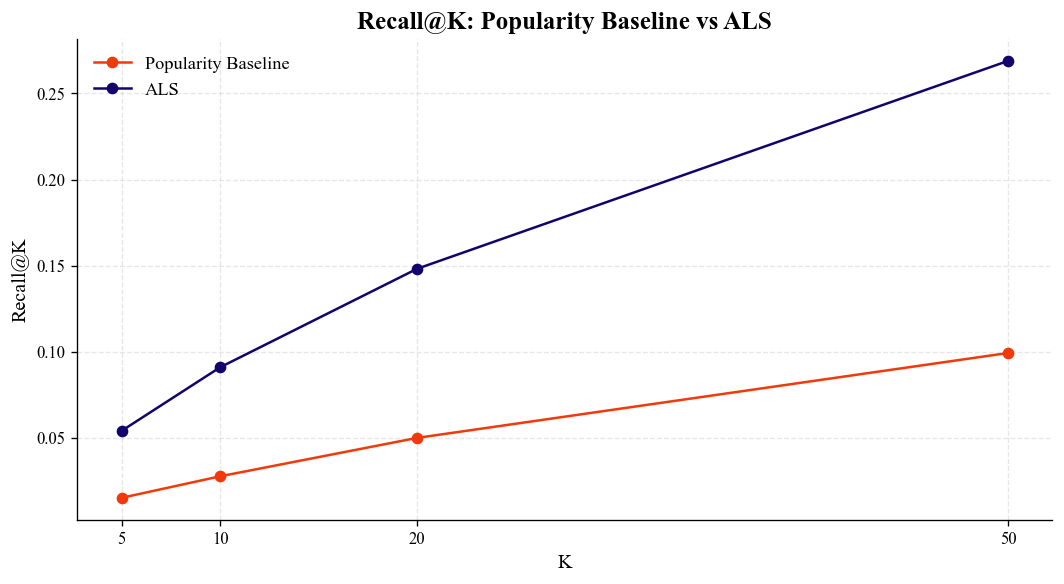

In [179]:
# ==========================================
# Recall@K Model Comparison
# ==========================================

import matplotlib.pyplot as plt

k_values = model_comparison["K"].to_list()
baseline_values = model_comparison["Baseline Recall@K"].to_list()
als_values = model_comparison["ALS Recall@K"].to_list()

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    baseline_values,
    marker="o",
    label="Popularity Baseline",
    color= SECONDARY_COLOR
)

plt.plot(
    k_values,
    als_values,
    marker="o",
    label="ALS",
    color= PRIMARY_COLOR
)

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Recall@K: Popularity Baseline vs ALS")
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Temporal Validation Split

The original test set is kept untouched for the final evaluation.

To tune the ALS hyperparameters without introducing test-set leakage, a second temporal split is created inside the training data.

For each user, the latest interaction from the training period is used as validation data, while the remaining interactions are used for model training.

This preserves the temporal nature of the recommendation problem.

In [180]:
# ==========================================
# Temporal Validation Split
# ==========================================

validation_data = (
    train_data
    .group_by("userId", maintain_order=True)
    .tail(1)
)

print(
    f"Validation ratings: {validation_data.height:,}"
)

Validation ratings: 162,541


In [181]:
# ==========================================
# Build Validation Ground Truth
# ==========================================

validation_ground_truth = dict(
    zip(
        validation_data["userId"].to_list(),
        validation_data["movieId"].to_list()
    )
)

validation_user_ids = list(
    validation_ground_truth.keys()
)

print(
    f"Validation users: {len(validation_user_ids):,}"
)

Validation users: 162,541


## Build the Validation Training Matrix

The validation interactions are removed directly from the existing training sparse matrix.

This avoids rebuilding a large sparse matrix through another full DataFrame join and keeps memory usage under control.

In [182]:
# ==========================================
# Build Validation Training Matrix
# ==========================================

validation_train_matrix = train_user_item_matrix.copy()

validation_user_indices = np.array(
    [
        user_to_index[user_id]
        for user_id in validation_data["userId"].to_list()
    ],
    dtype=np.int32
)

validation_movie_indices = np.array(
    [
        movie_to_index[movie_id]
        for movie_id in validation_data["movieId"].to_list()
    ],
    dtype=np.int32
)

print(
    "Validation training matrix:",
    validation_train_matrix.shape
)

Validation training matrix: (162541, 24330)


In [183]:
# ==========================================
# Remove Validation Interactions
# ==========================================

for user_idx, movie_idx in zip(
    validation_user_indices,
    validation_movie_indices
):

    row_start = validation_train_matrix.indptr[user_idx]
    row_end = validation_train_matrix.indptr[user_idx + 1]

    row_columns = validation_train_matrix.indices[
        row_start:row_end
    ]

    positions = np.flatnonzero(
        row_columns == movie_idx
    )

    if positions.size > 0:

        validation_train_matrix.data[
            row_start + positions[0]
        ] = 0.0

validation_train_matrix.eliminate_zeros()

print(
    f"Validation training interactions: "
    f"{validation_train_matrix.nnz:,}"
)

Validation training interactions: 24,565,501


In [184]:
# ==========================================
# Validate Validation Split
# ==========================================

remaining_validation_interactions = 0

for user_idx, movie_idx in zip(
    validation_user_indices,
    validation_movie_indices
):

    row_start = validation_train_matrix.indptr[user_idx]
    row_end = validation_train_matrix.indptr[user_idx + 1]

    row_columns = validation_train_matrix.indices[
        row_start:row_end
    ]

    if np.any(row_columns == movie_idx):
        remaining_validation_interactions += 1

print(
    "Remaining validation interactions:",
    remaining_validation_interactions
)

Remaining validation interactions: 0


In [185]:
# ==========================================
# Validate Validation Split
# ==========================================

remaining_validation_ratings = 0

for user_idx, movie_idx in zip(
    validation_user_indices,
    validation_movie_indices
):
    row_start = validation_train_matrix.indptr[user_idx]
    row_end = validation_train_matrix.indptr[user_idx + 1]

    row_columns = validation_train_matrix.indices[
        row_start:row_end
    ]

    position = np.searchsorted(
        row_columns,
        movie_idx
    )

    if (
        position < len(row_columns)
        and row_columns[position] == movie_idx
    ):
        remaining_validation_ratings += 1

print(
    "Remaining validation interactions:",
    remaining_validation_ratings
)

Remaining validation interactions: 0


---

## Prepare Validation Ground Truth

Each user contributes one held-out movie to the validation set.

The validation ground truth is used only for selecting the ALS hyperparameters.
The original test set remains untouched until the final evaluation.

In [186]:
# ==========================================
# Build Validation Ground Truth
# ==========================================

validation_ground_truth = dict(
    zip(
        validation_data["userId"].to_list(),
        [
            movie_to_index[movie_id]
            for movie_id in validation_data["movieId"].to_list()
        ]
    )
)

validation_user_ids = list(
    validation_ground_truth.keys()
)

print(
    "Validation users:",
    len(validation_user_ids)
)

Validation users: 162541


## Validate Validation Ground Truth Indices

This check confirms that validation ground-truth movies use the same internal indices as the ALS user-item matrix.

In [187]:
# ==========================================
# Validate Validation Ground Truth Indices
# ==========================================

validation_max_idx = max(
    validation_ground_truth.values()
)

print(
    "Validation max movie_idx :",
    validation_max_idx
)

print(
    "Number of movie columns  :",
    len(movie_ids)
)

print(
    "Validation indices valid :",
    validation_max_idx < len(movie_ids)
)

Validation max movie_idx : 24329
Number of movie columns  : 24330
Validation indices valid : True


---

## ALS Hyperparameter Screening

A small controlled hyperparameter search is used to identify a promising ALS configuration without repeatedly training a large number of expensive models.

The validation set is used for model selection, while the original test set remains untouched.

The screening stage uses fewer iterations to reduce computational cost.

In [188]:
# ==========================================
# ALS Hyperparameter Screening
# ==========================================

als_configs = [
    {
        "factors": 32,
        "regularization": 0.1,
        "alpha": 1.0
    },
    {
        "factors": 32,
        "regularization": 0.5,
        "alpha": 1.0
    },
    {
        "factors": 64,
        "regularization": 0.1,
        "alpha": 1.0
    }
]

tuning_results = []

for config in als_configs:

    model = implicit.als.AlternatingLeastSquares(
        factors=config["factors"],
        regularization=config["regularization"],
        iterations=5,
        alpha=config["alpha"],
        random_state=42
    )

    model.fit(
        validation_train_matrix.astype(
            np.float32,
            copy=False
        ),
        show_progress=True
    )

    hits, recall = evaluate_als_recall(
        model=model,
        user_ids=validation_user_ids,
        ground_truth=validation_ground_truth,
        user_items=validation_train_matrix,
        user_to_index=user_to_index,
        k=20,
        batch_size=1000
    )

    tuning_results.append({
        "Factors": config["factors"],
        "Regularization": config["regularization"],
        "Alpha": config["alpha"],
        "Validation Hits": hits,
        "Validation Recall@20": recall
    })

tuning_results = pl.DataFrame(
    tuning_results
)

print(tuning_results)

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

shape: (3, 5)
┌─────────┬────────────────┬───────┬─────────────────┬──────────────────────┐
│ Factors ┆ Regularization ┆ Alpha ┆ Validation Hits ┆ Validation Recall@20 │
│ ---     ┆ ---            ┆ ---   ┆ ---             ┆ ---                  │
│ i64     ┆ f64            ┆ f64   ┆ i64             ┆ f64                  │
╞═════════╪════════════════╪═══════╪═════════════════╪══════════════════════╡
│ 32      ┆ 0.1            ┆ 1.0   ┆ 25240           ┆ 0.155284             │
│ 32      ┆ 0.5            ┆ 1.0   ┆ 25213           ┆ 0.155118             │
│ 64      ┆ 0.1            ┆ 1.0   ┆ 27273           ┆ 0.167792             │
└─────────┴────────────────┴───────┴─────────────────┴──────────────────────┘


## Select the Best ALS Configuration

The validation results are used to select the best ALS configuration.

Recall@20 is used as the selection metric because the recommendation system is evaluated on a Top-K recommendation task, and K=20 provides a useful balance between recommendation quality and list size.

The original test set is not used during this selection process.

In [189]:
# ==========================================
# Select Best ALS Configuration
# ==========================================

best_config = (
    tuning_results
    .sort(
        "Validation Recall@20",
        descending=True
    )
    .head(1)
)

print(best_config)

shape: (1, 5)
┌─────────┬────────────────┬───────┬─────────────────┬──────────────────────┐
│ Factors ┆ Regularization ┆ Alpha ┆ Validation Hits ┆ Validation Recall@20 │
│ ---     ┆ ---            ┆ ---   ┆ ---             ┆ ---                  │
│ i64     ┆ f64            ┆ f64   ┆ i64             ┆ f64                  │
╞═════════╪════════════════╪═══════╪═════════════════╪══════════════════════╡
│ 64      ┆ 0.1            ┆ 1.0   ┆ 27273           ┆ 0.167792             │
└─────────┴────────────────┴───────┴─────────────────┴──────────────────────┘


In [190]:
# ==========================================
# Extract Best ALS Parameters
# ==========================================

best_factors = int(
    best_config["Factors"][0]
)

best_regularization = float(
    best_config["Regularization"][0]
)

best_alpha = float(
    best_config["Alpha"][0]
)

print("Best factors        :", best_factors)
print("Best regularization :", best_regularization)
print("Best alpha          :", best_alpha)

Best factors        : 64
Best regularization : 0.1
Best alpha          : 1.0


## Train the Final ALS Model

The best hyperparameter configuration selected on the validation set is now used to train the final ALS model.

The model is trained on the complete training dataset, while the original temporal test set remains completely unseen.

This final model is used only for the final evaluation and recommendation generation.

In [191]:
# ==========================================
# Train Final ALS Model
# ==========================================

final_als_model = implicit.als.AlternatingLeastSquares(
    factors=best_factors,
    regularization=best_regularization,
    iterations=10,
    alpha=best_alpha,
    random_state=42
)

final_als_model.fit(
    als_train_matrix.astype(
        np.float32,
        copy=False
    ),
    show_progress=True
)

  0%|          | 0/10 [00:00<?, ?it/s]

## Validate the Final Model Structure

Before running the final evaluation, we verify that the final model has learned the expected number of user and movie latent factors.

In [192]:
# ==========================================
# Validate Final Model Factors
# ==========================================

print(
    "User factors :",
    final_als_model.user_factors.shape
)

print(
    "Movie factors:",
    final_als_model.item_factors.shape
)

User factors : (162541, 64)
Movie factors: (24330, 64)


---

## Final Test Evaluation

The final ALS model is evaluated on the original temporal test set.

The test set contains the last known interaction for each user and has remained completely unseen during model training and hyperparameter selection.

Recall@K is reported for K=5, 10, 20, and 50 to measure how effectively the model retrieves the held-out movie within the top-K recommendations.

In [193]:
# ==========================================
# Final ALS Test Evaluation
# ==========================================

final_als_results = []

for k in [5, 10, 20, 50]:

    hits, recall = evaluate_als_recall(
        model=final_als_model,
        user_ids=evaluation_user_ids,
        ground_truth=test_ground_truth_indices,
        user_items=als_train_matrix,
        user_to_index=user_to_index,
        k=k,
        batch_size=1000
    )

    final_als_results.append({
        "K": k,
        "Hits": hits,
        "Recall@K": round(recall, 4)
    })

final_als_results = pl.DataFrame(
    final_als_results
)

print(final_als_results)

shape: (4, 3)
┌─────┬───────┬──────────┐
│ K   ┆ Hits  ┆ Recall@K │
│ --- ┆ ---   ┆ ---      │
│ i64 ┆ i64   ┆ f64      │
╞═════╪═══════╪══════════╡
│ 5   ┆ 9307  ┆ 0.0573   │
│ 10  ┆ 15896 ┆ 0.0978   │
│ 20  ┆ 26331 ┆ 0.162    │
│ 50  ┆ 47054 ┆ 0.2895   │
└─────┴───────┴──────────┘


## Final Model Comparison

The final ALS model is compared with the popularity baseline using the untouched temporal test set.

Both models are evaluated on exactly the same users, held-out movies, and Recall@K metric.

This comparison measures the practical benefit of personalized collaborative filtering over a simple popularity-based recommendation strategy.

In [194]:
# ==========================================
# Final Model Comparison
# ==========================================

final_comparison = (
    baseline_results
    .select(["K", "Recall@K"])
    .rename({
        "Recall@K": "Baseline Recall@K"
    })
    .join(
        final_als_results
        .select(["K", "Recall@K"])
        .rename({
            "Recall@K": "ALS Recall@K"
        }),
        on="K",
        how="inner"
    )
    .with_columns(
        (
            pl.col("ALS Recall@K")
            - pl.col("Baseline Recall@K")
        )
        .round(4)
        .alias("Improvement")
    )
    .with_columns(
        (
            (
                pl.col("ALS Recall@K")
                - pl.col("Baseline Recall@K")
            )
            / pl.col("Baseline Recall@K")
            * 100
        )
        .round(2)
        .alias("Improvement (%)")
    )
)

print(final_comparison)

shape: (4, 5)
┌─────┬───────────────────┬──────────────┬─────────────┬─────────────────┐
│ K   ┆ Baseline Recall@K ┆ ALS Recall@K ┆ Improvement ┆ Improvement (%) │
│ --- ┆ ---               ┆ ---          ┆ ---         ┆ ---             │
│ i64 ┆ f64               ┆ f64          ┆ f64         ┆ f64             │
╞═════╪═══════════════════╪══════════════╪═════════════╪═════════════════╡
│ 5   ┆ 0.0152            ┆ 0.0573       ┆ 0.0421      ┆ 276.97          │
│ 10  ┆ 0.0277            ┆ 0.0978       ┆ 0.0701      ┆ 253.07          │
│ 20  ┆ 0.05              ┆ 0.162        ┆ 0.112       ┆ 224.0           │
│ 50  ┆ 0.0993            ┆ 0.2895       ┆ 0.1902      ┆ 191.54          │
└─────┴───────────────────┴──────────────┴─────────────┴─────────────────┘


---

## Final Recall@K Comparison

This visualization presents the final recommendation performance of the popularity baseline and the tuned ALS model.

The comparison uses the untouched temporal test set and highlights the improvement achieved through personalized collaborative filtering.

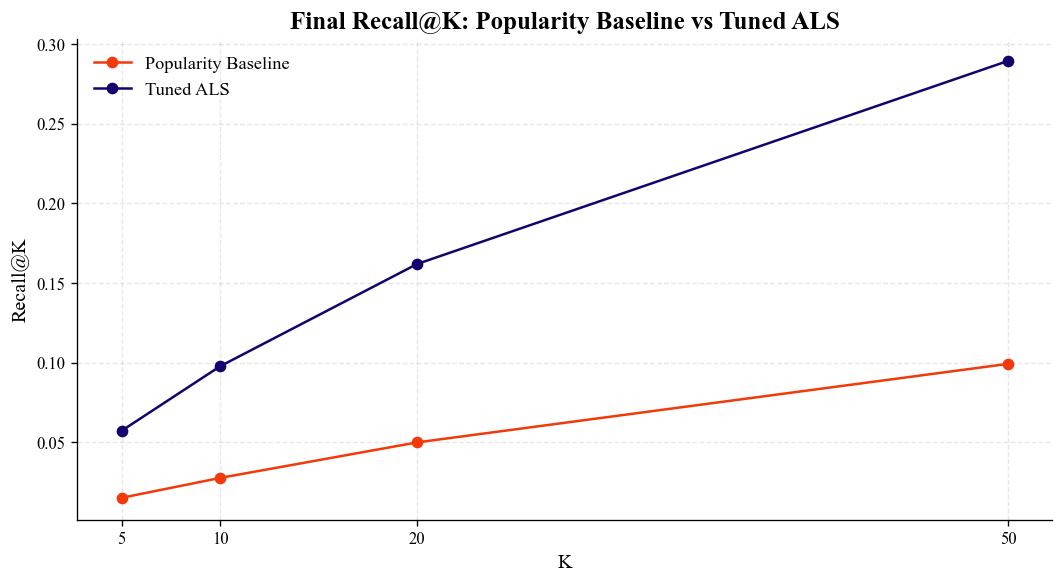

In [195]:
# ==========================================
# Final Recall@K Comparison
# ==========================================

k_values = final_comparison["K"].to_list()

baseline_values = (
    final_comparison["Baseline Recall@K"]
    .to_list()
)

als_values = (
    final_comparison["ALS Recall@K"]
    .to_list()
)

plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    baseline_values,
    marker="o",
    label="Popularity Baseline",
    color= SECONDARY_COLOR
)

plt.plot(
    k_values,
    als_values,
    marker="o",
    label="Tuned ALS",
    color= PRIMARY_COLOR
)

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Final Recall@K: Popularity Baseline vs Tuned ALS")
plt.xticks(k_values)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Build the Recommendation Function

The trained ALS model is now wrapped in a reusable recommendation function.

The function accepts a user ID and the desired number of recommendations, generates personalized recommendations, removes movies already seen by the user, and returns the corresponding movie IDs and recommendation scores.

In [196]:
# ==========================================
# Personalized Movie Recommendation Function
# ==========================================

def recommend_movies(
    user_id,
    n=10
):
    if user_id not in user_to_index:
        raise ValueError(
            f"Unknown userId: {user_id}"
        )

    user_index = user_to_index[user_id]

    recommended_indices, scores = (
        final_als_model.recommend(
            userid=user_index,
            user_items=als_train_matrix[user_index],
            N=n,
            filter_already_liked_items=True
        )
    )

    movie_id_list = movie_ids.to_list()

    recommendations = pl.DataFrame({
        "movieId": [
            movie_id_list[int(idx)]
            for idx in recommended_indices
        ],
        "score": scores
    })

    return recommendations

## Add Movie Titles to Recommendations

Movie IDs are useful internally, but users need readable movie titles.

The recommendation output is therefore joined with the existing movie metadata to return movie titles alongside the model scores.

In [197]:
# ==========================================
# Personalized Recommendations with Titles
# ==========================================

movie_title_lookup = (
    movies_enriched
    .select(["movieId", "title"])
    .unique("movieId")
)

def recommend_movies_with_titles(
    user_id,
    n=10
):
    recommendations = recommend_movies(
        user_id=user_id,
        n=n
    )

    return (
        recommendations
        .join(
            movie_title_lookup,
            on="movieId",
            how="left"
        )
        .select([
            "movieId",
            "title",
            "score"
        ])
    )

---

## Generate Personalized Movie Recommendations

This example demonstrates the final recommendation pipeline for an existing user.

The output contains the movie ID, movie title, and the model's recommendation score.

In [198]:
# ==========================================
# Generate Personalized Recommendations
# ==========================================

print(
    recommend_movies_with_titles(
    user_id=1,
    n=10
)
)

shape: (10, 3)
┌─────────┬───────────────────────────────────┬──────────┐
│ movieId ┆ title                             ┆ score    │
│ ---     ┆ ---                               ┆ ---      │
│ i64     ┆ str                               ┆ f32      │
╞═════════╪═══════════════════════════════════╪══════════╡
│ 308     ┆ Three Colors: White (Trzy kolory… ┆ 0.642412 │
│ 4306    ┆ Shrek (2001)                      ┆ 0.630265 │
│ 4235    ┆ Amores Perros (Love's a Bitch) (… ┆ 0.621067 │
│ 4993    ┆ Lord of the Rings: The Fellowshi… ┆ 0.605224 │
│ 7153    ┆ Lord of the Rings: The Return of… ┆ 0.596935 │
│ 4886    ┆ Monsters, Inc. (2001)             ┆ 0.57754  │
│ 3083    ┆ All About My Mother (Todo sobre … ┆ 0.541863 │
│ 7361    ┆ Eternal Sunshine of the Spotless… ┆ 0.540453 │
│ 6874    ┆ Kill Bill: Vol. 1 (2003)          ┆ 0.528753 │
│ 2324    ┆ Life Is Beautiful (La Vita è bel… ┆ 0.521724 │
└─────────┴───────────────────────────────────┴──────────┘


---

## Precision@K Evaluation

Precision@K measures the proportion of recommended items in the Top-K list that match the held-out ground-truth interaction.

This complements Recall@K by evaluating recommendation quality from the perspective of the recommended items.

In [199]:
# ==========================================
# Evaluate ALS Precision@K
# ==========================================

def evaluate_als_precision(
    model,
    user_ids,
    ground_truth,
    user_items,
    user_to_index,
    k=20,
    batch_size=1000
):
    hits = 0
    total_recommendations = 0

    for start in range(0, len(user_ids), batch_size):

        batch_user_ids = user_ids[
            start:start + batch_size
        ]

        batch_indices = np.array(
            [
                user_to_index[user_id]
                for user_id in batch_user_ids
            ],
            dtype=np.int32
        )

        recommendations, _ = model.recommend(
            userid=batch_indices,
            user_items=user_items[batch_indices],
            N=k,
            filter_already_liked_items=True
        )

        for row_idx, user_id in enumerate(batch_user_ids):

            recommended_movie_indices = recommendations[row_idx]
            target_movie_index = ground_truth[user_id]

            if target_movie_index in recommended_movie_indices:
                hits += 1

        total_recommendations += (
            len(batch_user_ids) * k
        )

    precision = hits / total_recommendations

    return hits, precision

## Final ALS Precision Evaluation

The final ALS model is evaluated on the held-out test set using the same temporal evaluation protocol as Recall@K.

In [200]:
# ==========================================
# Final ALS Precision Evaluation
# ==========================================

final_als_precision_results = []

for k in [5, 10, 20, 50]:

    hits, precision = evaluate_als_precision(
        model=final_als_model,
        user_ids=evaluation_user_ids,
        ground_truth=test_ground_truth_indices,
        user_items=als_train_matrix,
        user_to_index=user_to_index,
        k=k,
        batch_size=1000
    )

    final_als_precision_results.append({
        "K": k,
        "Hits": hits,
        "Precision@K": round(precision, 6)
    })

final_als_precision_results = pl.DataFrame(
    final_als_precision_results
)

print(final_als_precision_results)

shape: (4, 3)
┌─────┬───────┬─────────────┐
│ K   ┆ Hits  ┆ Precision@K │
│ --- ┆ ---   ┆ ---         │
│ i64 ┆ i64   ┆ f64         │
╞═════╪═══════╪═════════════╡
│ 5   ┆ 9307  ┆ 0.011452    │
│ 10  ┆ 15896 ┆ 0.00978     │
│ 20  ┆ 26331 ┆ 0.0081      │
│ 50  ┆ 47054 ┆ 0.00579     │
└─────┴───────┴─────────────┘


---

## Precision@K Interpretation

Precision@K measures the proportion of recommended items in the Top-K list that match the held-out ground-truth interaction.

$$
Precision@K =
\frac{\text{Number of relevant recommended items}}
{\text{Total number of recommended items}}
$$

In this evaluation setup, each user has only **one ground-truth movie**: the final interaction held out from the training data. Therefore, for each user, the number of relevant recommended items can only be 0 or 1.

With one ground-truth item per user:

$$
Precision@K =
\frac{\text{Hits@K}}
{\text{Number of Users} \times K}
$$

while:

$$
Recall@K =
\frac{\text{Hits@K}}
{\text{Number of Users}}
$$

Therefore:

$$
Precision@K = \frac{Recall@K}{K}
$$

As a result, Precision@K naturally decreases as K increases, while Recall@K increases because a larger recommendation list provides more opportunities to retrieve the held-out movie.

For this reason, **Recall@K is used as the primary evaluation metric** for this project. Precision@K is retained as a supplementary metric rather than the main model-selection criterion.

## Catalog Coverage

Catalog Coverage measures the proportion of unique movies that appear in the recommendation lists relative to the total number of movies available in the recommendation catalog.

$$
Coverage@K =
\frac{\text{Number of unique recommended movies}}
{\text{Total number of movies in the catalog}}
$$

A higher coverage indicates that the recommender exposes a broader portion of the catalog, while a very low coverage may indicate that recommendations are concentrated around a small set of popular or highly similar movies.

For this project, coverage is evaluated on the test users using the final ALS model and the same Top-K recommendation lists used for Recall@K.

Because generating recommendations for all users is already computationally expensive, the evaluation is performed in batches to avoid creating a large dense intermediate structure in memory.

In [201]:
# ==========================================
# Catalog Coverage@K Evaluation
# ==========================================

def evaluate_catalog_coverage(
    model,
    user_ids,
    user_items,
    user_to_index,
    total_movies,
    k=20,
    batch_size=1000
):
    recommended_movies = set()

    for start in range(0, len(user_ids), batch_size):

        batch_user_ids = user_ids[
            start:start + batch_size
        ]

        batch_indices = np.array(
            [
                user_to_index[user_id]
                for user_id in batch_user_ids
            ],
            dtype=np.int32
        )

        recommendations, _ = model.recommend(
            userid=batch_indices,
            user_items=user_items[batch_indices],
            N=k,
            filter_already_liked_items=True
        )

        recommended_movies.update(
            recommendations.ravel().tolist()
        )

    unique_recommended_movies = len(recommended_movies)

    coverage = (
        unique_recommended_movies / total_movies
    )

    return unique_recommended_movies, coverage

---

## Final ALS Catalog Coverage

Catalog coverage is measured at multiple recommendation list sizes to examine how the breadth of the recommended catalog changes as K increases.

In [202]:
# ==========================================
# Final ALS Catalog Coverage Evaluation
# ==========================================

coverage_results = []

for k in [5, 10, 20, 50]:

    unique_movies, coverage = evaluate_catalog_coverage(
        model=final_als_model,
        user_ids=evaluation_user_ids,
        user_items=als_train_matrix,
        user_to_index=user_to_index,
        total_movies=len(movie_ids),
        k=k,
        batch_size=1000
    )

    coverage_results.append({
        "K": k,
        "Unique Recommended Movies": unique_movies,
        "Catalog Coverage": round(coverage, 4)
    })

coverage_results = pl.DataFrame(
    coverage_results
)

print(coverage_results)

shape: (4, 3)
┌─────┬───────────────────────────┬──────────────────┐
│ K   ┆ Unique Recommended Movies ┆ Catalog Coverage │
│ --- ┆ ---                       ┆ ---              │
│ i64 ┆ i64                       ┆ f64              │
╞═════╪═══════════════════════════╪══════════════════╡
│ 5   ┆ 2482                      ┆ 0.102            │
│ 10  ┆ 2915                      ┆ 0.1198           │
│ 20  ┆ 3449                      ┆ 0.1418           │
│ 50  ┆ 4328                      ┆ 0.1779           │
└─────┴───────────────────────────┴──────────────────┘


## Intra-List Diversity

Intra-List Diversity (ILD) measures how different the recommended movies are from each other within a user's recommendation list.

For two movies, similarity is calculated using their latent factor representations learned by ALS.

$$
ILD@K =
1 -
\frac{
\sum_{i<j} sim(i,j)
}{
\binom{K}{2}
}
$$

A higher ILD indicates a more diverse recommendation list, while a lower value indicates that the recommended movies are more similar to each other.

Because calculating pairwise similarity for all users would be unnecessarily expensive, diversity is estimated on a fixed random sample of test users. Recommendations are generated in batches to keep memory usage low.

In [203]:
# ==========================================
# Intra-List Diversity@K
# ==========================================

def evaluate_als_diversity(
    model,
    user_ids,
    user_items,
    user_to_index,
    movie_factors,
    k=20,
    sample_size=5000,
    batch_size=500,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    sample_size = min(
        sample_size,
        len(user_ids)
    )

    sampled_user_ids = rng.choice(
        user_ids,
        size=sample_size,
        replace=False
    )

    total_diversity = 0.0
    evaluated_users = 0

    for start in range(
        0,
        sample_size,
        batch_size
    ):

        batch_user_ids = sampled_user_ids[
            start:start + batch_size
        ]

        batch_indices = np.array(
            [
                user_to_index[user_id]
                for user_id in batch_user_ids
            ],
            dtype=np.int32
        )

        recommendations, _ = model.recommend(
            userid=batch_indices,
            user_items=user_items[batch_indices],
            N=k,
            filter_already_liked_items=True
        )

        batch_factors = movie_factors[
            recommendations
        ].astype(
            np.float32,
            copy=False
        )

        norms = np.linalg.norm(
            batch_factors,
            axis=2,
            keepdims=True
        )

        normalized_factors = (
            batch_factors / np.maximum(norms, 1e-12)
        )

        similarity_matrix = (
            normalized_factors
            @ np.transpose(
                normalized_factors,
                (0, 2, 1)
            )
        )

        upper_triangle_sum = (
            np.triu(
                similarity_matrix,
                k=1
            ).sum(axis=(1, 2))
        )

        pair_count = k * (k - 1) / 2

        batch_diversity = (
            1.0 -
            upper_triangle_sum / pair_count
        )

        total_diversity += batch_diversity.sum()
        evaluated_users += len(batch_user_ids)

        del (
            batch_factors,
            normalized_factors,
            similarity_matrix,
            upper_triangle_sum,
            batch_diversity
        )

    return total_diversity / evaluated_users

## Final ALS Diversity Evaluation

Intra-List Diversity is estimated on a fixed sample of test users for computational efficiency.

The same user sample and evaluation protocol are used across different recommendation list sizes.

In [204]:
# ==========================================
# Final ALS Diversity Evaluation
# ==========================================

diversity_results = []

for k in [5, 10, 20, 50]:

    diversity = evaluate_als_diversity(
        model=final_als_model,
        user_ids=evaluation_user_ids,
        user_items=als_train_matrix,
        user_to_index=user_to_index,
        movie_factors=final_als_model.item_factors,
        k=k,
        sample_size=5000,
        batch_size=500,
        random_state=42
    )

    diversity_results.append({
        "K": k,
        "Intra-List Diversity": round(
            diversity,
            4
        )
    })

diversity_results = pl.DataFrame(
    diversity_results
)

print(diversity_results)

shape: (4, 2)
┌─────┬──────────────────────┐
│ K   ┆ Intra-List Diversity │
│ --- ┆ ---                  │
│ i64 ┆ f64                  │
╞═════╪══════════════════════╡
│ 5   ┆ 0.5744               │
│ 10  ┆ 0.6125               │
│ 20  ┆ 0.6544               │
│ 50  ┆ 0.7126               │
└─────┴──────────────────────┘


## Recommendation Diversity Analysis

Intra-List Diversity (ILD) was evaluated alongside Recall@K and Catalog Coverage to provide a broader view of recommendation quality.

The results show that diversity increases as the recommendation list becomes larger:

- **K=5:** 0.5744
- **K=10:** 0.6125
- **K=20:** 0.6544
- **K=50:** 0.7126

At **K=20**, the final ALS model achieved an Intra-List Diversity of **0.6544**. This indicates that the recommended movies are not excessively concentrated around highly similar latent representations.

However, ILD should not be interpreted as a percentage of "real-world diversity." It is a relative metric based on cosine similarity between the latent movie representations learned by ALS. Therefore, a higher ILD indicates lower average similarity between recommended items within a list.

Combined with the other evaluation metrics at K=20:

$$
Recall@20 = 0.1620
$$

$$
Coverage@20 = 0.1418
$$

$$
ILD@20 = 0.6544
$$

These results suggest that the final ALS model provides a reasonable balance between recommendation accuracy, catalog exposure, and intra-list diversity.

Recall@20 remains the primary ranking-quality metric, while Catalog Coverage and Intra-List Diversity are used as complementary measures to assess the broader behavior of the recommender system.

---

## Qualitative Recommendation Analysis

Quantitative metrics provide an overall evaluation of the recommender system, but they do not show what the recommendations actually look like for individual users.

In this section, personalized recommendations are inspected for selected users to verify that the final ALS model produces meaningful and user-specific movie rankings.

The analysis focuses on the recommended movie titles and their ranking scores rather than treating individual examples as a substitute for the quantitative evaluation.

In [205]:
# ==========================================
# Generate Personalized Recommendations
# ==========================================

def get_user_recommendations(
    model,
    user_id,
    user_items,
    user_to_index,
    movie_ids,
    movies,
    n=10
):
    user_idx = user_to_index[user_id]

    recommendations, scores = model.recommend(
        userid=np.array([user_idx], dtype=np.int32),
        user_items=user_items[user_idx],
        N=n,
        filter_already_liked_items=True
    )

    recommended_indices = recommendations[0]

    result = pl.DataFrame({
        "movie_idx": recommended_indices,
        "score": scores[0]
    })

    result = (
        result
        .with_columns(
            pl.col("movie_idx")
            .map_elements(
                lambda idx: movie_ids[idx],
                return_dtype=pl.Int64
            )
            .alias("movieId")
        )
        .drop("movie_idx")
    )

    result = (
        result
        .join(
            movies.select(["movieId", "title"]),
            on="movieId",
            how="left"
        )
        .select([
            "movieId",
            "title",
            "score"
        ])
    )

    return result

In [206]:
# ==========================================
# Qualitative Recommendation Examples
# ==========================================

for user_id in [1, 2, 3, 4, 5]:

    print("=" * 80)
    print(f"User {user_id} Recommendations")
    print("=" * 80)

    recommendations = get_user_recommendations(
        model=final_als_model,
        user_id=user_id,
        user_items=als_train_matrix,
        user_to_index=user_to_index,
        movie_ids=movie_ids,
        movies=movies_enriched,
        n=10
    )

    print(recommendations)

User 1 Recommendations
shape: (10, 3)
┌─────────┬───────────────────────────────────┬──────────┐
│ movieId ┆ title                             ┆ score    │
│ ---     ┆ ---                               ┆ ---      │
│ i64     ┆ str                               ┆ f32      │
╞═════════╪═══════════════════════════════════╪══════════╡
│ 308     ┆ Three Colors: White (Trzy kolory… ┆ 0.642412 │
│ 4306    ┆ Shrek (2001)                      ┆ 0.630265 │
│ 4235    ┆ Amores Perros (Love's a Bitch) (… ┆ 0.621067 │
│ 4993    ┆ Lord of the Rings: The Fellowshi… ┆ 0.605224 │
│ 7153    ┆ Lord of the Rings: The Return of… ┆ 0.596935 │
│ 4886    ┆ Monsters, Inc. (2001)             ┆ 0.57754  │
│ 3083    ┆ All About My Mother (Todo sobre … ┆ 0.541863 │
│ 7361    ┆ Eternal Sunshine of the Spotless… ┆ 0.540453 │
│ 6874    ┆ Kill Bill: Vol. 1 (2003)          ┆ 0.528753 │
│ 2324    ┆ Life Is Beautiful (La Vita è bel… ┆ 0.521724 │
└─────────┴───────────────────────────────────┴──────────┘
User 2 Recommendat

---

## Qualitative Recommendation Analysis

The final ALS model was inspected using personalized Top-10 recommendations for several users.

The recommendation lists show clear differences across users. For example, some users receive recommendations concentrated around drama and critically acclaimed films, while others receive action, adventure, superhero, or science-fiction movies.

This variation provides a qualitative sanity check that the model is producing personalized recommendations rather than returning the same globally popular movies to every user.

However, these examples are not used as a substitute for quantitative evaluation. They are complementary to Recall@K, Catalog Coverage, and Intra-List Diversity and are intended to provide an interpretable view of the model's recommendation behavior.

Recommendation scores are model-specific ranking scores and should primarily be interpreted within each user's recommendation list rather than compared directly across different users.

---

## User History vs. Personalized Recommendations

To complement the quantitative evaluation, selected users are examined by comparing their previous rating history with their personalized recommendations.

This analysis helps determine whether the recommendations are consistent with each user's observed preferences rather than being driven only by globally popular movies.

The analysis is qualitative and is intended as a sanity check of personalization behavior. It is not used as a replacement for the quantitative evaluation metrics.

In [207]:
# ==========================================
# User Rating History
# ==========================================

def get_user_history(
    user_id,
    ratings_data,
    movies,
    n=10
):
    history = (
        ratings_data
        .filter(
            pl.col("userId") == user_id
        )
        .sort(
            "rating",
            descending=True
        )
        .head(n)
        .join(
            movies.select([
                "movieId",
                "title"
            ]),
            on="movieId",
            how="left"
        )
        .select([
            "movieId",
            "title",
            "rating"
        ])
    )

    return history

## User Preference Comparison

The following examples compare highly rated movies from a user's historical interactions with the movies recommended by the final ALS model.

In [208]:
# ==========================================
# User History vs. Recommendations
# ==========================================

for user_id in [1, 2, 3, 4, 5]:

    print(f"\n{'=' * 80}")
    print(f"User {user_id} - Top Rated History")
    print(f"{'=' * 80}")

    history = get_user_history(
        user_id=user_id,
        ratings_data=train_data,
        movies=movies_enriched,
        n=10
    )

    print(history)

    print(f"\n{'=' * 80}")
    print(f"User {user_id} - Personalized Recommendations")
    print(f"{'=' * 80}")

    recommendations = get_user_recommendations(
        model=final_als_model,
        user_id=user_id,
        user_items=als_train_matrix,
        user_to_index=user_to_index,
        movie_ids=movie_ids,
        movies=movies_enriched,
        n=10
    )

    print(recommendations)


User 1 - Top Rated History
shape: (10, 3)
┌─────────┬───────────────────────────────────┬────────┐
│ movieId ┆ title                             ┆ rating │
│ ---     ┆ ---                               ┆ ---    │
│ i64     ┆ str                               ┆ f64    │
╞═════════╪═══════════════════════════════════╪════════╡
│ 6711    ┆ Lost in Translation (2003)        ┆ 5.0    │
│ 3949    ┆ Requiem for a Dream (2000)        ┆ 5.0    │
│ 307     ┆ Three Colors: Blue (Trois couleu… ┆ 5.0    │
│ 1237    ┆ Seventh Seal, The (Sjunde insegl… ┆ 5.0    │
│ 8154    ┆ Dolce Vita, La (1960)             ┆ 5.0    │
│ 4144    ┆ In the Mood For Love (Fa yeung n… ┆ 5.0    │
│ 6016    ┆ City of God (Cidade de Deus) (20… ┆ 5.0    │
│ 2692    ┆ Run Lola Run (Lola rennt) (1998)  ┆ 5.0    │
│ 4325    ┆ Night, The (Notte, La) (1960)     ┆ 5.0    │
│ 2632    ┆ Saragossa Manuscript, The (Rekop… ┆ 5.0    │
└─────────┴───────────────────────────────────┴────────┘

User 1 - Personalized Recommendations
shape:

The qualitative inspection of selected users showed that the ALS model produces noticeably different recommendation profiles across users.

For User 1, whose highly rated history is strongly associated with international, classic, and art-oriented cinema, the recommendations included titles such as Three Colors: White, Amores Perros, Eternal Sunshine of the Spotless Mind, and Life Is Beautiful.

For User 2, whose history contains a stronger mixture of action, drama, adventure, and fantasy titles, the recommendations included Glory, The Green Mile, Last of the Mohicans, Dances with Wolves, and The Patriot.

These examples provide a qualitative sanity check that the model is learning user-specific preference patterns rather than returning an identical list of popular movies to every user.

---

## Final Model Evaluation Summary

The final ALS model was evaluated from multiple perspectives to avoid relying on a single performance metric.

The evaluation includes ranking quality through Recall@K, comparison against the baseline recommender, catalog coverage, intra-list diversity, and qualitative inspection of personalized recommendations.

Together, these metrics provide a broader assessment of both recommendation accuracy and recommendation behavior.

In [209]:
# ==========================================
# Final Evaluation Summary
# ==========================================

evaluation_summary = (
    final_als_results
    .join(
        baseline_results,
        on="K",
        how="left",
        suffix="_Baseline"
    )
    .select([
        "K",
        pl.col("Recall@K").alias("ALS Recall@K"),
        pl.col("Recall@K_Baseline").alias("Baseline Recall@K")
    ])
)

print(evaluation_summary)

shape: (4, 3)
┌─────┬──────────────┬───────────────────┐
│ K   ┆ ALS Recall@K ┆ Baseline Recall@K │
│ --- ┆ ---          ┆ ---               │
│ i64 ┆ f64          ┆ f64               │
╞═════╪══════════════╪═══════════════════╡
│ 5   ┆ 0.0573       ┆ 0.0152            │
│ 10  ┆ 0.0978       ┆ 0.0277            │
│ 20  ┆ 0.162        ┆ 0.05              │
│ 50  ┆ 0.2895       ┆ 0.0993            │
└─────┴──────────────┴───────────────────┘


In [210]:
# ==========================================
# Final Recommendation Quality Summary
# ==========================================

final_quality_summary = pl.DataFrame({
    "K": [5, 10, 20, 50],
    "Baseline Recall@K": [0.0152, 0.0277, 0.0500, 0.0993],
    "ALS Recall@K": [0.0573, 0.0978, 0.1620, 0.2895],
    "Catalog Coverage": [0.1020, 0.1198, 0.1418, 0.1779],
    "Intra-List Diversity": [0.5744, 0.6125, 0.6544, 0.7126]
})

print(final_quality_summary)

shape: (4, 5)
┌─────┬───────────────────┬──────────────┬──────────────────┬──────────────────────┐
│ K   ┆ Baseline Recall@K ┆ ALS Recall@K ┆ Catalog Coverage ┆ Intra-List Diversity │
│ --- ┆ ---               ┆ ---          ┆ ---              ┆ ---                  │
│ i64 ┆ f64               ┆ f64          ┆ f64              ┆ f64                  │
╞═════╪═══════════════════╪══════════════╪══════════════════╪══════════════════════╡
│ 5   ┆ 0.0152            ┆ 0.0573       ┆ 0.102            ┆ 0.5744               │
│ 10  ┆ 0.0277            ┆ 0.0978       ┆ 0.1198           ┆ 0.6125               │
│ 20  ┆ 0.05              ┆ 0.162        ┆ 0.1418           ┆ 0.6544               │
│ 50  ┆ 0.0993            ┆ 0.2895       ┆ 0.1779           ┆ 0.7126               │
└─────┴───────────────────┴──────────────┴──────────────────┴──────────────────────┘


---

## Recall@K Comparison

Recall@K measures the proportion of held-out relevant interactions that were successfully retrieved within the top-K recommendations.

The final ALS model is compared with the popularity-based baseline across different recommendation-list sizes.

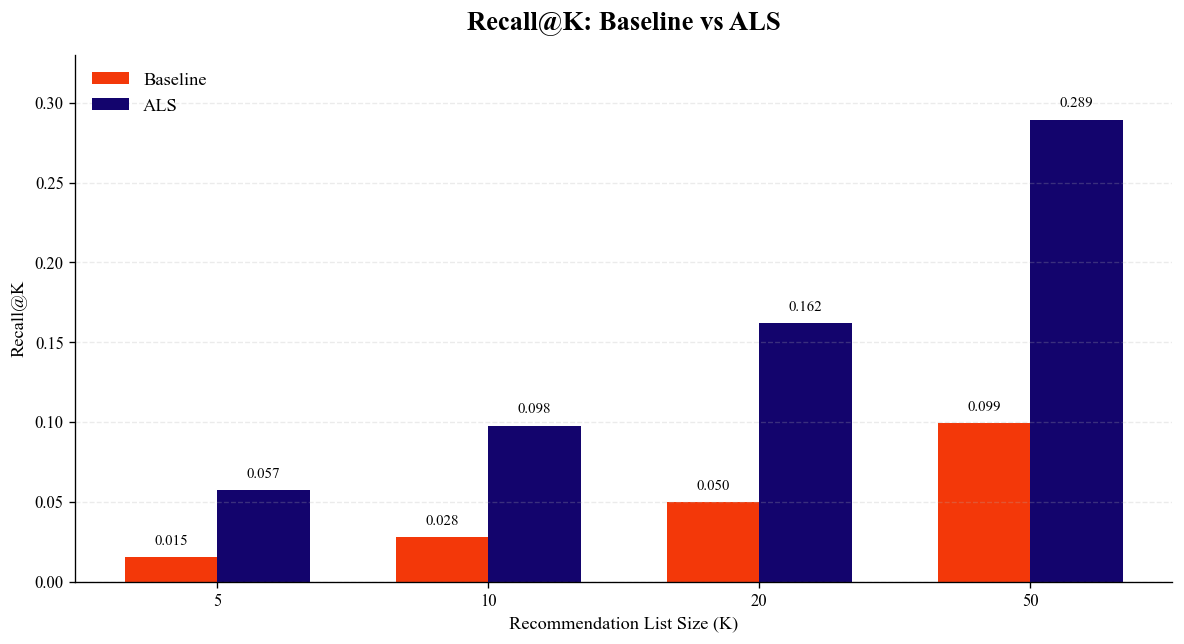

In [211]:
# ==========================================
# Final Evaluation Visualization - Recall@K
# ==========================================

k_values = [5, 10, 20, 50]

baseline_recall = [0.0152, 0.0277, 0.0500, 0.0993]
als_recall = [0.0573, 0.0978, 0.1620, 0.2895]

x = np.arange(len(k_values))
width = 0.34

fig, ax = plt.subplots(figsize=(10, 5.5))

bars_baseline = ax.bar(
    x - width / 2,
    baseline_recall,
    width,
    label="Baseline",
    color= SECONDARY_COLOR
)

bars_als = ax.bar(
    x + width / 2,
    als_recall,
    width,
    label="ALS",
    color= PRIMARY_COLOR
)

ax.set_title(
    "Recall@K: Baseline vs ALS",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recommendation List Size (K)", fontsize=11)
ax.set_ylabel("Recall@K", fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(k_values)

ax.set_ylim(0, 0.33)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper left"
)

for bars in [bars_baseline, bars_als]:
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.006,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

---

## Catalog Coverage

Catalog Coverage measures the proportion of unique movies that appear in the recommendation lists across the evaluated users.

Higher coverage indicates that the recommender exposes a broader portion of the available movie catalog rather than concentrating recommendations on a small set of movies.

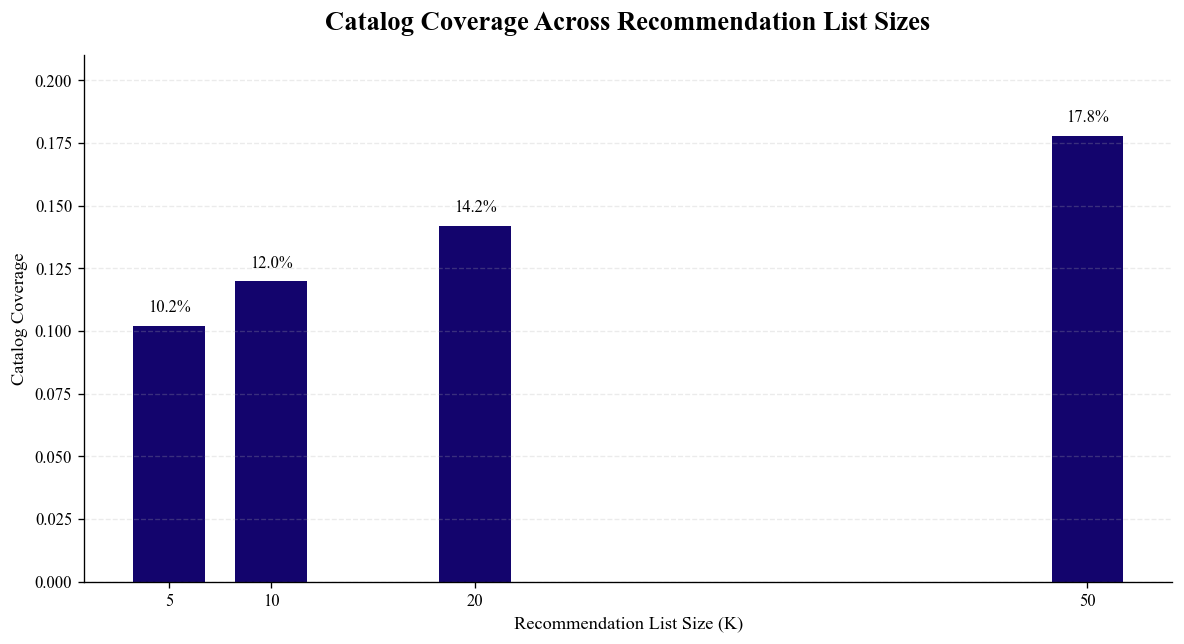

In [212]:
# ==========================================
# Final Evaluation Visualization - Coverage
# ==========================================

k_values = [5, 10, 20, 50]

catalog_coverage = [0.1020, 0.1198, 0.1418, 0.1779]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    k_values,
    catalog_coverage,
    width=3.5,
    color= PRIMARY_COLOR
)

ax.set_title(
    "Catalog Coverage Across Recommendation List Sizes",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recommendation List Size (K)", fontsize=11)
ax.set_ylabel("Catalog Coverage", fontsize=11)

ax.set_xticks(k_values)

ax.set_ylim(0, 0.21)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(bars, catalog_coverage):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.004,
        f"{value:.1%}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

---

## Intra-List Diversity

Intra-List Diversity measures how different the recommended movies are from one another within the same recommendation list.

Higher values indicate more diverse recommendation lists and reduce the risk of producing highly repetitive recommendations.

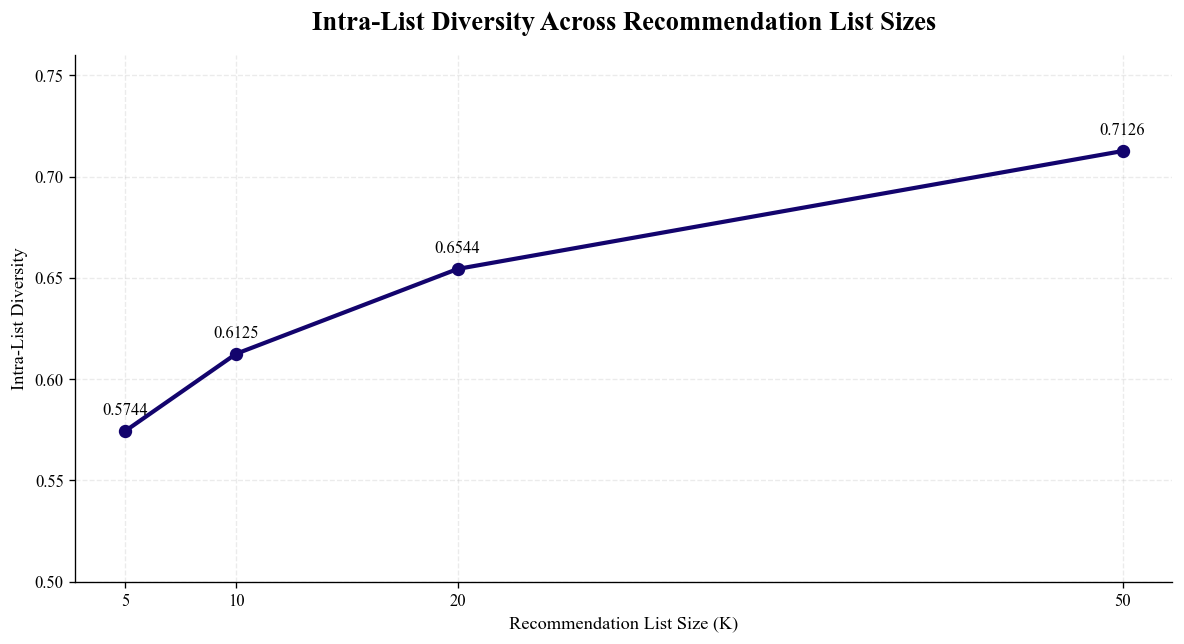

In [213]:
# ==========================================
# Final Evaluation Visualization - Diversity
# ==========================================

k_values = [5, 10, 20, 50]

diversity_values = [0.5744, 0.6125, 0.6544, 0.7126]

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    k_values,
    diversity_values,
    marker="o",
    linewidth=2.5,
    markersize=7,
    color= PRIMARY_COLOR
)

ax.set_title(
    "Intra-List Diversity Across Recommendation List Sizes",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Recommendation List Size (K)", fontsize=11)
ax.set_ylabel("Intra-List Diversity", fontsize=11)

ax.set_xticks(k_values)

ax.set_ylim(0.50, 0.76)

ax.grid(
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for k, value in zip(k_values, diversity_values):
    ax.annotate(
        f"{value:.4f}",
        xy=(k, value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

---

### Recommended Operating Point

For the final evaluation, **K=20** is used as the primary operating point.

At K=20, the final ALS model achieves a Recall@20 of **0.1620**, compared with **0.0500** for the baseline recommender.

The model also achieves a Catalog Coverage of **0.1418** and an Intra-List Diversity of **0.6544**.

K=20 provides a practical balance between ranking quality, catalog exposure, and recommendation-list diversity without requiring users to process an excessively large recommendation list.

In [214]:
# ==========================================
# API Dependency Check
# ==========================================

api_dependencies = [
    "final_als_model",
    "als_train_matrix",
    "user_to_index",
    "movie_to_index",
    "movie_ids",
    "movie_metadata"
]

for name in api_dependencies:
    print(
        f"{name:<20}:",
        "Available" if name in globals() else "Missing"
    )

final_als_model     : Available
als_train_matrix    : Available
user_to_index       : Available
movie_to_index      : Available
movie_ids           : Available
movie_metadata      : Available


---

## Export Final Model Artifacts

The final ALS model and the mappings required for inference are exported separately from the training notebook.

The API will use these artifacts for inference without retraining the recommendation model.
Sparse user-item data is preserved in CSR format to keep memory usage low.

In [215]:
# ------------------------------------------
# Create Artifact Directories
# ------------------------------------------

ARTIFACTS_DIR = Path("artifacts")

MODEL_DIR = ARTIFACTS_DIR / "model"
MAPPINGS_DIR = ARTIFACTS_DIR / "mappings"
DATA_DIR = ARTIFACTS_DIR / "data"
METADATA_DIR = ARTIFACTS_DIR / "metadata"

for directory in [
    MODEL_DIR,
    MAPPINGS_DIR,
    DATA_DIR,
    METADATA_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

In [216]:
# ------------------------------------------
# Save Final ALS Model
# ------------------------------------------

final_als_model.save(
    str(MODEL_DIR / "als_model.npz")
)

In [217]:
# ------------------------------------------
# Save User Mapping
# ------------------------------------------

user_to_index_json = {
    str(int(user_id)): int(user_index)
    for user_id, user_index in user_to_index.items()
}

with open(
    MAPPINGS_DIR / "user_to_index.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        user_to_index_json,
        file
    )

In [218]:
# ------------------------------------------
# Save Movie Mapping
# ------------------------------------------

movie_to_index_json = {
    str(int(movie_id)): int(movie_index)
    for movie_id, movie_index in movie_to_index.items()
}

with open(
    MAPPINGS_DIR / "movie_to_index.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        movie_to_index_json,
        file
    )

In [219]:
# ------------------------------------------
# Save Movie IDs
# ------------------------------------------

with open(
    MAPPINGS_DIR / "movie_ids.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        [int(movie_id) for movie_id in movie_ids],
        file
    )

In [220]:
# ------------------------------------------
# Save Sparse User-Item Matrix
# ------------------------------------------

save_npz(
    DATA_DIR / "user_items.npz",
    als_train_matrix
)

In [221]:
# ------------------------------------------
# Save Movie Metadata
# ------------------------------------------

movie_metadata.select(
    ["movieId", "title"]
).write_parquet(
    METADATA_DIR / "movies.parquet"
)

In [222]:
# ------------------------------------------
# Export Summary
# ------------------------------------------

print("Artifacts exported successfully.")
print(f"Model       : {MODEL_DIR / 'als_model.npz'}")
print(f"User mapping: {MAPPINGS_DIR / 'user_to_index.json'}")
print(f"Movie map   : {MAPPINGS_DIR / 'movie_to_index.json'}")
print(f"Movie IDs   : {MAPPINGS_DIR / 'movie_ids.json'}")
print(f"User items  : {DATA_DIR / 'user_items.npz'}")
print(f"Metadata    : {METADATA_DIR / 'movies.parquet'}")

Artifacts exported successfully.
Model       : artifacts\model\als_model.npz
User mapping: artifacts\mappings\user_to_index.json
Movie map   : artifacts\mappings\movie_to_index.json
Movie IDs   : artifacts\mappings\movie_ids.json
User items  : artifacts\data\user_items.npz
Metadata    : artifacts\metadata\movies.parquet


---

# End-to-End Recommendation Pipeline

The recommendation system follows an end-to-end collaborative filtering workflow, starting from raw user-item interaction data and ending with personalized movie recommendations.

### Pipeline Overview

1. **Data Loading & Preparation**
   - Load the required MovieLens datasets.
   - Select the columns required for recommendation modeling.
   - Perform initial data validation.

2. **Data Cleaning & EDA**
   - Check data types, missing values, duplicates, and interaction statistics.
   - Analyze user and movie activity distributions.
   - Examine rating and interaction patterns.

3. **Temporal Data Splitting**
   - Create chronological train, validation, and test sets.
   - The latest interaction of each user is held out for evaluation.
   - This prevents future interactions from being used during model training.

4. **User–Item Representation**
   - Map raw `userId` and `movieId` values to compact internal indices.
   - Construct sparse user-item interaction matrices to reduce memory usage.

5. **Baseline Recommendation**
   - Establish a simple popularity-based baseline.
   - Evaluate the baseline using Recall@K.

6. **ALS Collaborative Filtering**
   - Train an Alternating Least Squares model on the training interactions.
   - Screen a small set of hyperparameter configurations.
   - Select the best configuration based on validation Recall@20.

7. **Final Model Evaluation**
   - Retrain the final ALS model using the selected configuration.
   - Evaluate ranking performance on the held-out test interactions.
   - Compare ALS against the baseline.

8. **Recommendation Quality Analysis**
   - Measure Precision@K.
   - Measure Catalog Coverage.
   - Measure Intra-List Diversity.
   - Inspect personalized recommendations for selected users.
   - Compare user rating history with generated recommendations.

9. **Final Recommendation Output**
   - Generate ranked movie recommendations for individual users.
   - Convert internal matrix indices back to the original movie IDs and movie titles.

---

# Limitations

Although the final ALS model shows a substantial improvement over the baseline, the current recommendation system has several limitations.

### 1. Cold-Start Problem

ALS is based on historical user-item interactions. Therefore, it has limited information for completely new users or movies with little or no interaction history.

### 2. Collaborative Filtering Only

The current system relies primarily on collaborative filtering and does not directly use movie content such as genres, keywords, cast, or plot information when generating recommendations.

As a result, the system may struggle when interaction data is sparse, even when useful content information is available.

### 3. Popularity Bias

Collaborative filtering models can favor movies with sufficient interaction history. Although Catalog Coverage was evaluated to monitor this behavior, the system may still under-recommend less frequently interacted movies.

### 4. Offline Evaluation

The model was evaluated using historical interactions and offline ranking metrics. Offline performance does not necessarily guarantee the same performance in a real-world streaming environment.

User satisfaction, watch time, clicks, skips, and long-term engagement were not available in the current dataset.

### 5. Limited Hyperparameter Search

Only a small number of ALS configurations were evaluated due to the computational cost of training on the full interaction dataset.

A larger search space could potentially identify a better configuration.

### 6. Implicit Feedback Interpretation

The current evaluation treats historical interactions as evidence of user preference. However, an interaction does not always imply that a user strongly liked a movie.

Explicit ratings provide additional information, but the recommendation objective can still differ from a real streaming platform where clicks, watch time, completion rate, and skips are often more informative.

---

# Future Improvements

Several extensions could improve the recommendation system beyond the current ALS-based implementation.

### 1. Hybrid Recommendation

Combine collaborative filtering with movie content features such as genres, keywords, cast, and other metadata.

This could improve recommendations for new or less frequently interacted movies and partially address the cold-start problem.

### 2. Advanced Candidate Ranking

Use ALS to generate candidate movies and then apply a second-stage ranking model using additional user, movie, and interaction features.

This would create a two-stage recommendation architecture:

**Candidate Generation → Ranking**

### 3. More Extensive Hyperparameter Optimization

Evaluate a broader range of:

- latent factors
- regularization values
- confidence scaling parameters
- training iterations

Validation performance could be used to select the final configuration more systematically.

### 4. Additional Evaluation Metrics

The evaluation could be extended with metrics such as:

- NDCG@K
- MAP@K
- Hit Rate@K
- Novelty
- Serendipity

These metrics would provide additional information about ranking quality and recommendation behavior.

### 5. Time-Aware Modeling

User preferences can change over time. Incorporating temporal information could help the system adapt to changing interests and recent viewing behavior.

### 6. Production Deployment

A production version could expose the recommendation model through an API and include:

- scheduled model retraining
- recommendation caching
- monitoring
- model versioning
- latency tracking
- online A/B testing

---

# Final Conclusion

The final recommendation system uses Alternating Least Squares collaborative filtering to generate personalized movie recommendations from historical user-item interactions.

The final model achieved a **Recall@20 of 0.1620**, compared with **0.0500** for the popularity-based baseline. This represents a substantial improvement in ranking performance.

At K=20, the system also achieved **14.18% catalog coverage** and an **Intra-List Diversity of 0.6544**, providing complementary evidence about recommendation behavior beyond ranking accuracy.

Qualitative inspection of selected users further showed that the model produces different recommendation profiles for different users and that these recommendations are generally consistent with their historical rating patterns.

Overall, the project demonstrates an end-to-end collaborative filtering workflow, including temporal evaluation, sparse matrix construction, ALS modeling, hyperparameter selection, offline evaluation, diversity analysis, and qualitative recommendation analysis.